LA

LA full

Successfully loaded data. Initial shape: (601221, 28)

--- Initial Cleaning ---
Dropped 14166 rows with missing values in key columns.
Dropped specified identifier columns.
Filtered 1164 rows with price outside £10k-£20M range or non-numeric price.
DataFrame shape after initial cleaning: (585891, 19)

--- Feature Engineering (Date) ---
Dropped 0 rows with invalid date format.
Extracted date features (year, month, day, weekday, quarter).
Years present in data: [np.int32(1995), np.int32(1996), np.int32(1997), np.int32(1998), np.int32(1999), np.int32(2000), np.int32(2001), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]

--- Separating 2024 Data ---
Number of

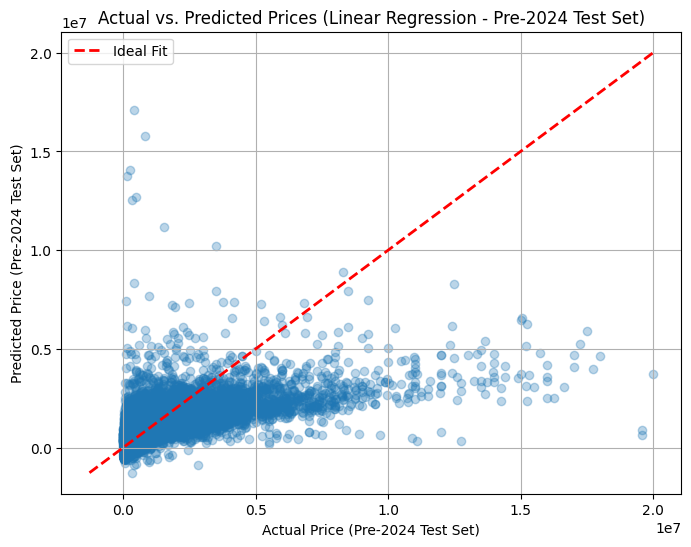


--- Preparing 2024 Data for Prediction ---
Applied label encoding to 2024 data column: postcode
Applied label encoding to 2024 data column: property type
Applied label encoding to 2024 data column: old/new
Applied label encoding to 2024 data column: duration
Applied label encoding to 2024 data column: PAON
Applied label encoding to 2024 data column: street
Applied label encoding to 2024 data column: locality
Applied label encoding to 2024 data column: town/city
Applied label encoding to 2024 data column: district
Applied label encoding to 2024 data column: county
Applied label encoding to 2024 data column: PPD category type
Applied label encoding to 2024 data column: epc_property_type
Applied label encoding to 2024 data column: epc_energy_rating
Shape of 2024 features after alignment: (14342, 21)
Filling 14342 NaN values in 2024 numerical features with 0.

--- Predicting Prices for 2024 Data ---
Added 'predicted_price' column to the 2024 DataFrame.

--- Model Evaluation (2024 Data Onl

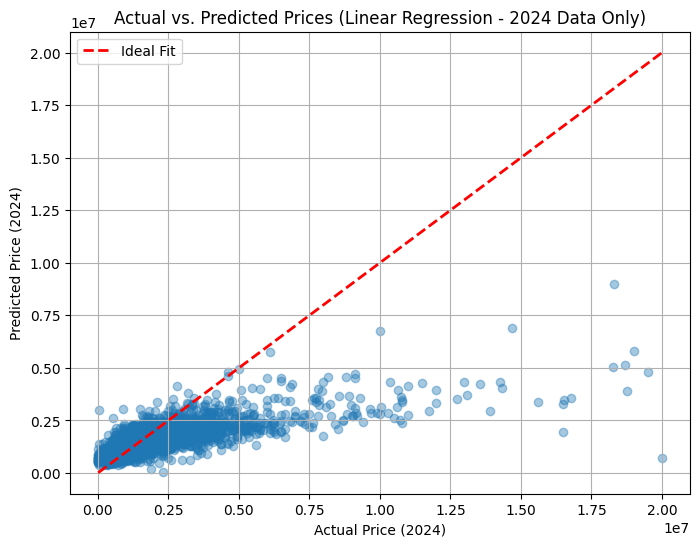


--- Sample Price Prediction (Using Pre-2024 Sample) ---

Selected Sample (Index: 401656 from pre-2024 data):
  Original Date: 2014-04-29
  Original Price: £900,000.00
  Address: SHIREHALL PARK, LONDON, BARNET, GREATER LONDON, NW4 2QU

Prediction for Original Year (2014): £1,270,794.72
Prediction for Year 2026: £1,696,799.19
Prediction for Year 2028: £1,767,799.94

Comparison:
  Actual (2014):      £900,000.00
  Predicted (2014): £1,270,794.72
  Predicted (2026):     £1,696,799.19
  Predicted (2028):     £1,767,799.94

--- Script Finished ---


In [ ]:
import numpy as np
import pandas as pd
from math import sqrt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore") 


df = pd.read_csv("london_merged_df_filtered.csv")
initial_rows = len(df)
df = df.dropna(subset=["postcode","epc_floor_area","epc_habitable_rooms"])
print(f"Dropped {initial_rows - len(df)} rows with missing values in key columns.")

initial_rows = len(df)
df = df.drop(columns=['record status - monthly file only', "Transaction unique identifier"], errors='ignore')
print("Dropped specified identifier columns.")

initial_rows = len(df)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])
df['price'] = df['price'].astype(float) 
# Filter Outliers
df = df[(df["price"] >= 10_000) & (df["price"] <= 2_0000_000)]
print(f"Filtered {initial_rows - len(df)} rows with price outside £10k-£20M range or non-numeric price.")
print(f"DataFrame shape after initial cleaning: {df.shape}")


# Feature Engineering (Date) ---
print("\n--- Feature Engineering (Date) ---")
df["date of transfer"] = pd.to_datetime(df["date of transfer"], format="%Y-%m-%d", errors="coerce")
initial_rows = len(df)
df = df.dropna(subset=["date of transfer"]) 
print(f"Dropped {initial_rows - len(df)} rows with invalid date format.")

# Extract meaningful date features
df['year']    = df['date of transfer'].dt.year
df["month"]   = df['date of transfer'].dt.month
df["day"]     = df['date of transfer'].dt.day
df["weekday"] = df['date of transfer'].dt.weekday
df["quarter"] = df['date of transfer'].dt.quarter
print("Extracted date features (year, month, day, weekday, quarter).")
print(f"Years present in data: {sorted(df['year'].unique())}")


# eparate 2024 Data ---
print("\n--- Separating 2024 Data ---")
df_2024 = df[df['year'] == 2024].copy() 
df = df[df['year'] != 2024] 

print(f"Number of rows in training data (pre-2024): {len(df)}")
print(f"Number of rows set aside for 2024 evaluation: {len(df_2024)}")

df_original_lookup = df.copy() # Contains sampled, pre-2024 data with original columns


# Prepare Data for Training
# Drop the original date column for the training dataframe
train_df = df.drop(columns=['date of transfer'])

# Identify categorical columns
categorical_cols = [col for col in train_df.columns if train_df[col].dtype == 'O']



label_encoders = {} # Dictionary to store fitted encoders

for col in categorical_cols:
   
    train_df[col].fillna('Missing', inplace=True)
    
    train_df[col] = train_df[col].astype(str)
    
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
   
    label_encoders[col] = le
    print(f"Label encoded column: {col}")

print(f"Shape after label encoding: {train_df.shape}") 

# Fill NaNs in numerical columns (if any remain after initial cleaning)
initial_nans = train_df.isna().sum().sum()
if initial_nans > 0:
    print(f"Filling {initial_nans} potential NaN values in numerical columns with 0.")
    train_df.fillna(0, inplace=True) 

# Define Features (X) and Target (y) for training
X = train_df.drop(['price'], axis=1)
y = train_df['price']

# Split into training and testing sets (using only pre-2024 data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data shape (X_train): {X_train.shape}")
print(f"Testing data shape (X_test): {X_test.shape}")


# Train the Linear Regression Model ---
print("\n--- Training Linear Regression Model ---")
lr_model = LinearRegression(n_jobs=-1)
lr_model.fit(X_train, y_train)
print("Model training complete.")


#  Evaluate Model on the Test Set (Pre-2024 Data) ---
print("\n--- Model Evaluation (Test Set - Pre-2024 Data) ---")
predictions_test = lr_model.predict(X_test)

mae_test = mean_absolute_error(y_test, predictions_test)
mse_test = mean_squared_error(y_test, predictions_test)
rmse_test = sqrt(mse_test)
r2_test = r2_score(y_test, predictions_test)

print(f'  MAE: {mae_test:.2f}')
print(f'  MSE: {mse_test:.2f}')
print(f'  RMSE: {rmse_test:.2f}')
print(f"  R-squared (R²): {r2_test:.2f}")


# Plot Actual vs. Predicted (Test Set - Pre-2024 Data) ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions_test, alpha=0.3)
plt.xlabel("Actual Price (Pre-2024 Test Set)")
plt.ylabel("Predicted Price (Pre-2024 Test Set)")
plt.title("Actual vs. Predicted Prices (Linear Regression - Pre-2024 Test Set)")
min_price = min(y_test.min(), predictions_test.min()) if len(y_test)>0 else 0
max_price = max(y_test.max(), predictions_test.max()) if len(y_test)>0 else 0
if min_price != max_price and not np.isnan(min_price) and not np.isnan(max_price): # Added NaN check
    plt.plot([min_price, max_price], [min_price, max_price], 'r--', lw=2, label='Ideal Fit')
plt.legend()
plt.grid(True)
plt.show()


# Prepare 2024 Data for Prediction ---
print("\n--- Preparing 2024 Data for Prediction ---")
if not df_2024.empty:
    
    df_2024_processed = df_2024.drop(columns=['date of transfer'])

   
    for col in categorical_cols:
        if col in df_2024_processed.columns:
           
            df_2024_processed[col].fillna('Missing', inplace=True)
            
            df_2024_processed[col] = df_2024_processed[col].astype(str)
           
            le = label_encoders[col]
            
            known_classes = set(le.classes_)

            df_2024_processed[col] = df_2024_processed[col].apply(
                lambda x: le.transform([x])[0] if x in known_classes else -1
            )
            print(f"Applied label encoding to 2024 data column: {col}")
        else:
             print(f"Warning: Categorical column '{col}' not found in 2024 data during processing.")


    # Separate features (X_2024) and actual prices (y_2024)
    y_2024_actual = df_2024_processed['price']
    X_2024 = df_2024_processed.drop('price', axis=1)


    X_2024 = X_2024.reindex(columns=X_train.columns, fill_value=0) # Fill missing numerical cols with 0
    print(f"Shape of 2024 features after alignment: {X_2024.shape}")

    # Fill any remaining NaNs in numerical columns (e.g., from reindex or original Nans)
    initial_nans_2024 = X_2024.isna().sum().sum()
    if initial_nans_2024 > 0:
       print(f"Filling {initial_nans_2024} NaN values in 2024 numerical features with 0.")
       X_2024.fillna(0, inplace=True)


    # Predict Prices for 2024 Data ---
    print("\n--- Predicting Prices for 2024 Data ---")
    predictions_2024 = lr_model.predict(X_2024)

 
    df_2024['predicted_price'] = predictions_2024
    print("Added 'predicted_price' column to the 2024 DataFrame.")

    # -Evaluate Model on 2024 Data ---
    print("\n--- Model Evaluation (2024 Data Only) ---")
    mae_2024 = mean_absolute_error(y_2024_actual, predictions_2024)
    mse_2024 = mean_squared_error(y_2024_actual, predictions_2024)
    rmse_2024 = sqrt(mse_2024)
    r2_2024 = r2_score(y_2024_actual, predictions_2024)

    print(f'  MAE (2024): {mae_2024:.2f}')
    print(f'  MSE (2024): {mse_2024:.2f}')
    print(f'  RMSE (2024): {rmse_2024:.2f}')
    print(f"  R-squared (R²) (2024): {r2_2024:.2f}")

    # Compare Actual vs Predicted Prices for 2024 ---
    print("\n--- Comparison of Actual vs Predicted Prices (Year 2024) ---")
    # Display the first few rows with actual and predicted prices
    print(df_2024[['price', 'predicted_price']].head())

    
    print("\nDescriptive Statistics for 2024 Prices:")
    print(df_2024[['price', 'predicted_price']].describe())

    # Plot Actual vs. Predicted (2024 Data) ---
    plt.figure(figsize=(8, 6))
    plt.scatter(df_2024['price'], df_2024['predicted_price'], alpha=0.4)
    plt.xlabel("Actual Price (2024)")
    plt.ylabel("Predicted Price (2024)")
    plt.title("Actual vs. Predicted Prices (Linear Regression - 2024 Data Only)")
    min_price_2024 = min(df_2024['price'].min(), df_2024['predicted_price'].min())
    max_price_2024 = max(df_2024['price'].max(), df_2024['predicted_price'].max())
    # Added NaN checks for plotting bounds
    if min_price_2024 != max_price_2024 and not np.isnan(min_price_2024) and not np.isnan(max_price_2024):
       plt.plot([min_price_2024, max_price_2024], [min_price_2024, max_price_2024], 'r--', lw=2, label='Ideal Fit')
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print("\n--- No Data Found for Year 2024 ---")
    print("Skipping prediction and evaluation for 2024.")


print("\n--- Sample Price Prediction (Using Pre-2024 Sample) ---")

if not df_original_lookup.empty:
    sample_original_df = df_original_lookup.sample(1, random_state=42) # random_state=42 ensures reproducibility

    if not sample_original_df.empty: # Check if sample is valid
        sample_index = sample_original_df.index[0]

        # Get original details from the lookup table
        original_date = sample_original_df['date of transfer'].iloc[0]
        original_year = sample_original_df['year'].iloc[0]
        original_price = sample_original_df['price'].iloc[0]
        address_fields = ['paon', 'saon', 'street', 'locality', 'town/city', 'district', 'county', 'postcode']
        original_address = ", ".join(str(sample_original_df[col].iloc[0]) for col in address_fields if col in sample_original_df.columns and pd.notna(sample_original_df[col].iloc[0]))

        print(f"\nSelected Sample (Index: {sample_index} from pre-2024 data):")
        print(f"  Original Date: {original_date.strftime('%Y-%m-%d')}")
        print(f"  Original Price: £{original_price:,.2f}")
        print(f"  Address: {original_address}")

        if sample_index in train_df.index:
            sample_processed_row = train_df.loc[[sample_index]]

            X_sample = sample_processed_row.drop('price', axis=1)
   
            X_sample = X_sample.reindex(columns=X_train.columns, fill_value=0)


           
            prediction_original_year = lr_model.predict(X_sample)[0]
            print(f"\nPrediction for Original Year ({original_year}): £{prediction_original_year:,.2f}")

       
            target_year_1 = 2026
            X_sample_future_1 = X_sample.copy()
            if 'year' in X_sample_future_1.columns:
                 X_sample_future_1['year'] = target_year_1
                 prediction_future_1 = lr_model.predict(X_sample_future_1)[0]
                 print(f"Prediction for Year {target_year_1}: £{prediction_future_1:,.2f}")
            else:
                 print(f"Warning: 'year' column not found in sample features. Cannot predict for {target_year_1}.")
                 prediction_future_1 = np.nan 

            target_year_2 = 2028
            X_sample_future_2 = X_sample.copy()
            if 'year' in X_sample_future_2.columns:
                 X_sample_future_2['year'] = target_year_2
                 prediction_future_2 = lr_model.predict(X_sample_future_2)[0]
                 print(f"Prediction for Year {target_year_2}: £{prediction_future_2:,.2f}")
            else:
                 print(f"Warning: 'year' column not found in sample features. Cannot predict for {target_year_2}.")
                 prediction_future_2 = np.nan 

            # Print Comparison
            print("\nComparison:")
            print(f"  Actual ({original_year}):      £{original_price:,.2f}")
            print(f"  Predicted ({original_year}): £{prediction_original_year:,.2f}")
            if not np.isnan(prediction_future_1): print(f"  Predicted ({target_year_1}):     £{prediction_future_1:,.2f}")
            if not np.isnan(prediction_future_2): print(f"  Predicted ({target_year_2}):     £{prediction_future_2:,.2f}")
        else:
            print(f"Sample index {sample_index} not found in the processed training data (train_df). Skipping sample prediction.")
    else:
        print("Could not select a valid sample from the original lookup DataFrame. Skipping sample prediction.")

else:
    print("Original lookup DataFrame (pre-2024) is empty. Skipping sample prediction.")

print("\n--- Script Finished ---")

LA 10y

Successfully loaded data. Initial shape: (191678, 28)

--- Initial Cleaning ---
Dropped 9538 rows with missing values in key columns.
Dropped specified identifier columns.
Filtered 765 rows with price outside £10k-£20M range or non-numeric price.
DataFrame shape after initial cleaning: (181375, 19)

--- Feature Engineering (Date) ---
Dropped 0 rows with invalid date format.
Extracted date features (year, month, day, weekday, quarter).
Years present in data: [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]

--- Separating 2024 Data ---
Number of rows in training data (pre-2024): 167033
Number of rows set aside for 2024 evaluation: 14342

--- Preparing Training Data (Pre-2024) ---
Identified categorical columns: ['postcode', 'property type', 'old/new', 'duration', 'PAON', 'street', 'locality', 'town/city', 'district', 'county', 'PPD category type', 'epc_property

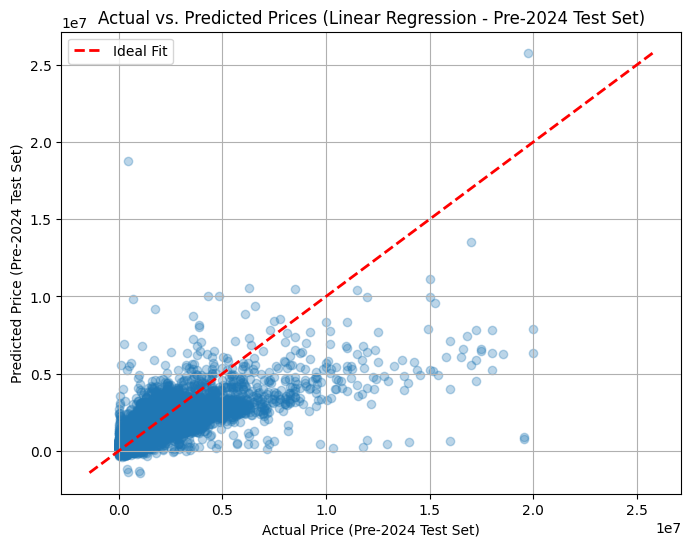


--- Preparing 2024 Data for Prediction ---
Applied label encoding to 2024 data column: postcode
Applied label encoding to 2024 data column: property type
Applied label encoding to 2024 data column: old/new
Applied label encoding to 2024 data column: duration
Applied label encoding to 2024 data column: PAON
Applied label encoding to 2024 data column: street
Applied label encoding to 2024 data column: locality
Applied label encoding to 2024 data column: town/city
Applied label encoding to 2024 data column: district
Applied label encoding to 2024 data column: county
Applied label encoding to 2024 data column: PPD category type
Applied label encoding to 2024 data column: epc_property_type
Applied label encoding to 2024 data column: epc_energy_rating
Shape of 2024 features after alignment: (14342, 21)
Filling 14342 NaN values in 2024 numerical features with 0.

--- Predicting Prices for 2024 Data ---
Added 'predicted_price' column to the 2024 DataFrame.

--- Model Evaluation (2024 Data Onl

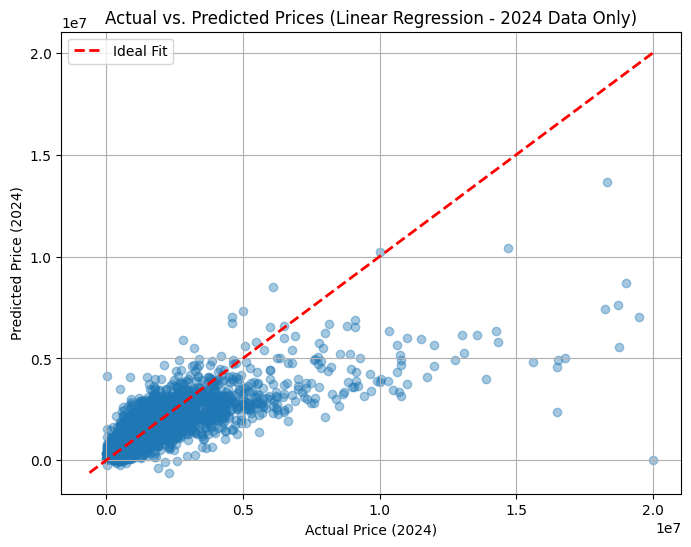


--- Sample Price Prediction (Using Pre-2024 Sample) ---

Selected Sample (Index: 13181 from pre-2024 data):
  Original Date: 2015-09-18
  Original Price: £2,625,000.00
  Address: BARROWGATE ROAD, LONDON, HOUNSLOW, GREATER LONDON, W4 4QU

Prediction for Original Year (2015): £1,849,808.51
Prediction for Year 2026: £2,138,841.60
Prediction for Year 2028: £2,191,393.07

Comparison:
  Actual (2015):      £2,625,000.00
  Predicted (2015): £1,849,808.51
  Predicted (2026):     £2,138,841.60
  Predicted (2028):     £2,191,393.07

--- Script Finished ---


In [ ]:
import numpy as np
import pandas as pd
from math import sqrt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore") 


df = pd.read_csv("london_merged_df_filtered_2015.csv")
initial_rows = len(df)
df = df.dropna(subset=["postcode","epc_floor_area","epc_habitable_rooms"])
print(f"Dropped {initial_rows - len(df)} rows with missing values in key columns.")

initial_rows = len(df)
df = df.drop(columns=['record status - monthly file only', "Transaction unique identifier"], errors='ignore')
print("Dropped specified identifier columns.")

initial_rows = len(df)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])
df['price'] = df['price'].astype(float) 
# Filter Outliers
df = df[(df["price"] >= 10_000) & (df["price"] <= 2_0000_000)]
print(f"Filtered {initial_rows - len(df)} rows with price outside £10k-£20M range or non-numeric price.")
print(f"DataFrame shape after initial cleaning: {df.shape}")


# Feature Engineering (Date) ---
print("\n--- Feature Engineering (Date) ---")
df["date of transfer"] = pd.to_datetime(df["date of transfer"], format="%Y-%m-%d", errors="coerce")
initial_rows = len(df)
df = df.dropna(subset=["date of transfer"]) 
print(f"Dropped {initial_rows - len(df)} rows with invalid date format.")

# Extract meaningful date features
df['year']    = df['date of transfer'].dt.year
df["month"]   = df['date of transfer'].dt.month
df["day"]     = df['date of transfer'].dt.day
df["weekday"] = df['date of transfer'].dt.weekday
df["quarter"] = df['date of transfer'].dt.quarter
print("Extracted date features (year, month, day, weekday, quarter).")
print(f"Years present in data: {sorted(df['year'].unique())}")


# eparate 2024 Data ---
print("\n--- Separating 2024 Data ---")
df_2024 = df[df['year'] == 2024].copy() 
df = df[df['year'] != 2024] 

print(f"Number of rows in training data (pre-2024): {len(df)}")
print(f"Number of rows set aside for 2024 evaluation: {len(df_2024)}")

df_original_lookup = df.copy() # Contains sampled, pre-2024 data with original columns


# Prepare Data for Training
# Drop the original date column for the training dataframe
train_df = df.drop(columns=['date of transfer'])

# Identify categorical columns
categorical_cols = [col for col in train_df.columns if train_df[col].dtype == 'O']



label_encoders = {} # Dictionary to store fitted encoders

for col in categorical_cols:
   
    train_df[col].fillna('Missing', inplace=True)
    
    train_df[col] = train_df[col].astype(str)
    
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
   
    label_encoders[col] = le
    print(f"Label encoded column: {col}")

print(f"Shape after label encoding: {train_df.shape}") 

# Fill NaNs in numerical columns (if any remain after initial cleaning)
initial_nans = train_df.isna().sum().sum()
if initial_nans > 0:
    print(f"Filling {initial_nans} potential NaN values in numerical columns with 0.")
    train_df.fillna(0, inplace=True) 

# Define Features (X) and Target (y) for training
X = train_df.drop(['price'], axis=1)
y = train_df['price']

# Split into training and testing sets (using only pre-2024 data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data shape (X_train): {X_train.shape}")
print(f"Testing data shape (X_test): {X_test.shape}")


# Train the Linear Regression Model ---
print("\n--- Training Linear Regression Model ---")
lr_model = LinearRegression(n_jobs=-1)
lr_model.fit(X_train, y_train)
print("Model training complete.")


#  Evaluate Model on the Test Set (Pre-2024 Data) ---
print("\n--- Model Evaluation (Test Set - Pre-2024 Data) ---")
predictions_test = lr_model.predict(X_test)

mae_test = mean_absolute_error(y_test, predictions_test)
mse_test = mean_squared_error(y_test, predictions_test)
rmse_test = sqrt(mse_test)
r2_test = r2_score(y_test, predictions_test)

print(f'  MAE: {mae_test:.2f}')
print(f'  MSE: {mse_test:.2f}')
print(f'  RMSE: {rmse_test:.2f}')
print(f"  R-squared (R²): {r2_test:.2f}")


# Plot Actual vs. Predicted (Test Set - Pre-2024 Data) ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions_test, alpha=0.3)
plt.xlabel("Actual Price (Pre-2024 Test Set)")
plt.ylabel("Predicted Price (Pre-2024 Test Set)")
plt.title("Actual vs. Predicted Prices (Linear Regression - Pre-2024 Test Set)")
min_price = min(y_test.min(), predictions_test.min()) if len(y_test)>0 else 0
max_price = max(y_test.max(), predictions_test.max()) if len(y_test)>0 else 0
if min_price != max_price and not np.isnan(min_price) and not np.isnan(max_price): # Added NaN check
    plt.plot([min_price, max_price], [min_price, max_price], 'r--', lw=2, label='Ideal Fit')
plt.legend()
plt.grid(True)
plt.show()


# Prepare 2024 Data for Prediction ---
print("\n--- Preparing 2024 Data for Prediction ---")
if not df_2024.empty:
    
    df_2024_processed = df_2024.drop(columns=['date of transfer'])

   
    for col in categorical_cols:
        if col in df_2024_processed.columns:
           
            df_2024_processed[col].fillna('Missing', inplace=True)
            
            df_2024_processed[col] = df_2024_processed[col].astype(str)
           
            le = label_encoders[col]
            
            known_classes = set(le.classes_)

            df_2024_processed[col] = df_2024_processed[col].apply(
                lambda x: le.transform([x])[0] if x in known_classes else -1
            )
            print(f"Applied label encoding to 2024 data column: {col}")
        else:
             print(f"Warning: Categorical column '{col}' not found in 2024 data during processing.")


    # Separate features (X_2024) and actual prices (y_2024)
    y_2024_actual = df_2024_processed['price']
    X_2024 = df_2024_processed.drop('price', axis=1)


    X_2024 = X_2024.reindex(columns=X_train.columns, fill_value=0) # Fill missing numerical cols with 0
    print(f"Shape of 2024 features after alignment: {X_2024.shape}")

    # Fill any remaining NaNs in numerical columns (e.g., from reindex or original Nans)
    initial_nans_2024 = X_2024.isna().sum().sum()
    if initial_nans_2024 > 0:
       print(f"Filling {initial_nans_2024} NaN values in 2024 numerical features with 0.")
       X_2024.fillna(0, inplace=True)


    # Predict Prices for 2024 Data ---
    print("\n--- Predicting Prices for 2024 Data ---")
    predictions_2024 = lr_model.predict(X_2024)

 
    df_2024['predicted_price'] = predictions_2024
    print("Added 'predicted_price' column to the 2024 DataFrame.")

    # -Evaluate Model on 2024 Data ---
    print("\n--- Model Evaluation (2024 Data Only) ---")
    mae_2024 = mean_absolute_error(y_2024_actual, predictions_2024)
    mse_2024 = mean_squared_error(y_2024_actual, predictions_2024)
    rmse_2024 = sqrt(mse_2024)
    r2_2024 = r2_score(y_2024_actual, predictions_2024)

    print(f'  MAE (2024): {mae_2024:.2f}')
    print(f'  MSE (2024): {mse_2024:.2f}')
    print(f'  RMSE (2024): {rmse_2024:.2f}')
    print(f"  R-squared (R²) (2024): {r2_2024:.2f}")

    # Compare Actual vs Predicted Prices for 2024 ---
    print("\n--- Comparison of Actual vs Predicted Prices (Year 2024) ---")
    # Display the first few rows with actual and predicted prices
    print(df_2024[['price', 'predicted_price']].head())

    
    print("\nDescriptive Statistics for 2024 Prices:")
    print(df_2024[['price', 'predicted_price']].describe())

    # Plot Actual vs. Predicted (2024 Data) ---
    plt.figure(figsize=(8, 6))
    plt.scatter(df_2024['price'], df_2024['predicted_price'], alpha=0.4)
    plt.xlabel("Actual Price (2024)")
    plt.ylabel("Predicted Price (2024)")
    plt.title("Actual vs. Predicted Prices (Linear Regression - 2024 Data Only)")
    min_price_2024 = min(df_2024['price'].min(), df_2024['predicted_price'].min())
    max_price_2024 = max(df_2024['price'].max(), df_2024['predicted_price'].max())
    # Added NaN checks for plotting bounds
    if min_price_2024 != max_price_2024 and not np.isnan(min_price_2024) and not np.isnan(max_price_2024):
       plt.plot([min_price_2024, max_price_2024], [min_price_2024, max_price_2024], 'r--', lw=2, label='Ideal Fit')
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print("\n--- No Data Found for Year 2024 ---")
    print("Skipping prediction and evaluation for 2024.")


print("\n--- Sample Price Prediction (Using Pre-2024 Sample) ---")

if not df_original_lookup.empty:
    sample_original_df = df_original_lookup.sample(1, random_state=42) # random_state=42 ensures reproducibility

    if not sample_original_df.empty: # Check if sample is valid
        sample_index = sample_original_df.index[0]

        # Get original details from the lookup table
        original_date = sample_original_df['date of transfer'].iloc[0]
        original_year = sample_original_df['year'].iloc[0]
        original_price = sample_original_df['price'].iloc[0]
        address_fields = ['paon', 'saon', 'street', 'locality', 'town/city', 'district', 'county', 'postcode']
        original_address = ", ".join(str(sample_original_df[col].iloc[0]) for col in address_fields if col in sample_original_df.columns and pd.notna(sample_original_df[col].iloc[0]))

        print(f"\nSelected Sample (Index: {sample_index} from pre-2024 data):")
        print(f"  Original Date: {original_date.strftime('%Y-%m-%d')}")
        print(f"  Original Price: £{original_price:,.2f}")
        print(f"  Address: {original_address}")

        if sample_index in train_df.index:
            sample_processed_row = train_df.loc[[sample_index]]

            X_sample = sample_processed_row.drop('price', axis=1)
   
            X_sample = X_sample.reindex(columns=X_train.columns, fill_value=0)


           
            prediction_original_year = lr_model.predict(X_sample)[0]
            print(f"\nPrediction for Original Year ({original_year}): £{prediction_original_year:,.2f}")

       
            target_year_1 = 2026
            X_sample_future_1 = X_sample.copy()
            if 'year' in X_sample_future_1.columns:
                 X_sample_future_1['year'] = target_year_1
                 prediction_future_1 = lr_model.predict(X_sample_future_1)[0]
                 print(f"Prediction for Year {target_year_1}: £{prediction_future_1:,.2f}")
            else:
                 print(f"Warning: 'year' column not found in sample features. Cannot predict for {target_year_1}.")
                 prediction_future_1 = np.nan 

            target_year_2 = 2028
            X_sample_future_2 = X_sample.copy()
            if 'year' in X_sample_future_2.columns:
                 X_sample_future_2['year'] = target_year_2
                 prediction_future_2 = lr_model.predict(X_sample_future_2)[0]
                 print(f"Prediction for Year {target_year_2}: £{prediction_future_2:,.2f}")
            else:
                 print(f"Warning: 'year' column not found in sample features. Cannot predict for {target_year_2}.")
                 prediction_future_2 = np.nan 

            # Print Comparison
            print("\nComparison:")
            print(f"  Actual ({original_year}):      £{original_price:,.2f}")
            print(f"  Predicted ({original_year}): £{prediction_original_year:,.2f}")
            if not np.isnan(prediction_future_1): print(f"  Predicted ({target_year_1}):     £{prediction_future_1:,.2f}")
            if not np.isnan(prediction_future_2): print(f"  Predicted ({target_year_2}):     £{prediction_future_2:,.2f}")
        else:
            print(f"Sample index {sample_index} not found in the processed training data (train_df). Skipping sample prediction.")
    else:
        print("Could not select a valid sample from the original lookup DataFrame. Skipping sample prediction.")

else:
    print("Original lookup DataFrame (pre-2024) is empty. Skipping sample prediction.")

print("\n--- Script Finished ---")

RF 2024 full

Successfully loaded data. Initial shape: (601221, 28)

--- Initial Cleaning ---
Dropped 14166 rows with missing values in key columns (postcode, epc_floor_area, epc_habitable_rooms).
Dropped specified identifier columns.
Filtered 1164 rows with price outside £10k-£20M range or non-numeric price.
DataFrame shape after initial cleaning: (585891, 19)

--- Feature Engineering (Date) ---
Dropped 0 rows with invalid date format.
Extracted date features (year, month, day, weekday, quarter).
Years present in data: [np.int32(1995), np.int32(1996), np.int32(1997), np.int32(1998), np.int32(1999), np.int32(2000), np.int32(2001), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int3

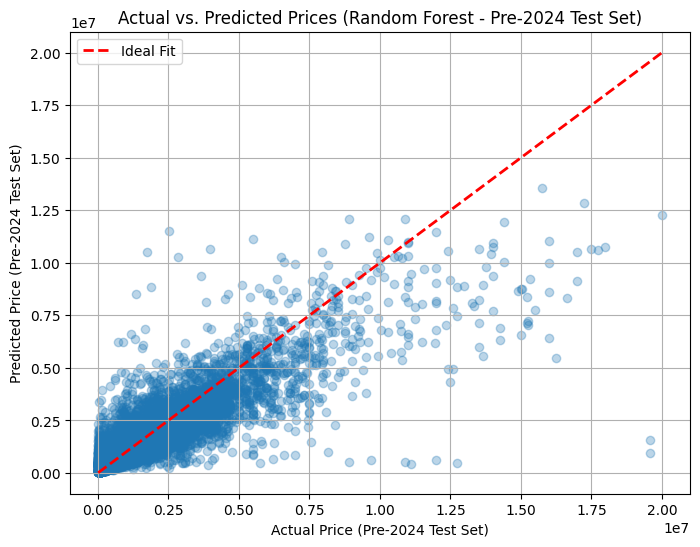


--- Preparing 2024 Data for Prediction ---
Applied label encoding to 2024 data column: postcode
Applied label encoding to 2024 data column: property type
Applied label encoding to 2024 data column: old/new
Applied label encoding to 2024 data column: duration
Applied label encoding to 2024 data column: PAON
Applied label encoding to 2024 data column: street
Applied label encoding to 2024 data column: locality
Applied label encoding to 2024 data column: town/city
Applied label encoding to 2024 data column: district
Applied label encoding to 2024 data column: county
Applied label encoding to 2024 data column: PPD category type
Applied label encoding to 2024 data column: epc_property_type
Applied label encoding to 2024 data column: epc_energy_rating
Shape of 2024 features after alignment: (14342, 21)
Filling 14342 NaN values in 2024 numerical features with 0.

--- Predicting Prices for 2024 Data ---
Added 'predicted_price' column to the 2024 DataFrame.

--- Model Evaluation (2024 Data Onl

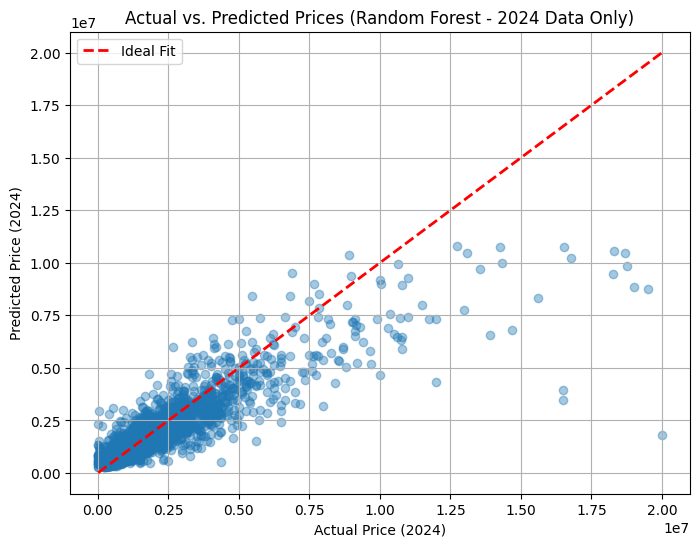


--- Sample Price Prediction (Random Forest - Using Pre-2024 Sample) ---

Selected Sample (Index: 401656 from pre-2024 data):
  Original Date: 2014-04-29
  Original Price: £900,000.00
  Address: SHIREHALL PARK, LONDON, BARNET, GREATER LONDON, NW4 2QU

Prediction for Original Year (2014): £1,489,664.00
Prediction for Year 2026: £1,805,980.75
Prediction for Year 2028: £1,805,980.75

Comparison:
  Actual (2014):      £900,000.00
  Predicted (2014): £1,489,664.00
  Predicted (2026):     £1,805,980.75
  Predicted (2028):     £1,805,980.75

--- Script Finished ---


In [ ]:
import numpy as np
import pandas as pd
from math import sqrt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import warnings # Import warnings
warnings.filterwarnings("ignore") # <-- Ignores ALL warnings! Use with extreme caution.



# --- Constants ---
TARGET_YEAR_FOR_SEPARATION = 2024 # Define the year to separate
MODEL_NAME = "Random Forest" # Define model name for titles/prints

# --- 1. Load Data ---
try:
    df = pd.read_csv("london_merged_df_filtered.csv")
    print(f"Successfully loaded data. Initial shape: {df.shape}")
except FileNotFoundError:
    # Adjusted error message slightly for clarity
    print("Error: london_merged_df_filtered.csv not found. Please ensure the file is in the correct directory.")
    exit() # Exit if file not found

# Added errors='ignore' for robustness if columns are already dropped
df = df.drop(columns=['postcode_cleaned', 'ppd_address_key', 'epc_address_key',
       'lodgement_date','lmk_key','epc_built_form','epc_age_band'], errors='ignore')



#  Basic Cleaning & Filtering ---
print("\n--- Initial Cleaning ---")
initial_rows = len(df)

df = df.dropna(subset=["postcode","epc_floor_area","epc_habitable_rooms"])
print(f"Dropped {initial_rows - len(df)} rows with missing values in key columns (postcode, epc_floor_area, epc_habitable_rooms).")

initial_rows = len(df)
df = df.drop(columns=['record status - monthly file only', "Transaction unique identifier"], errors='ignore')
print("Dropped specified identifier columns.")

initial_rows = len(df)

df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price']) 
df['price'] = df['price'].astype(float) # Ensure price is float for comparison

df = df[(df["price"] >= 10_000) & (df["price"] <= 2_0000_000)]
print(f"Filtered {initial_rows - len(df)} rows with price outside £10k-£20M range or non-numeric price.")
print(f"DataFrame shape after initial cleaning: {df.shape}")


# Feature Engineering (Date) ---
print("\n--- Feature Engineering (Date) ---")
df["date of transfer"] = pd.to_datetime(df["date of transfer"], format="%Y-%m-%d", errors="coerce")
initial_rows = len(df)
df = df.dropna(subset=["date of transfer"]) # Drop rows where date couldn't be parsed
print(f"Dropped {initial_rows - len(df)} rows with invalid date format.")

# Extract meaningful date features
df['year']    = df['date of transfer'].dt.year
df["month"]   = df['date of transfer'].dt.month
df["day"]     = df['date of transfer'].dt.day
df["weekday"] = df['date of transfer'].dt.weekday
df["quarter"] = df['date of transfer'].dt.quarter
print("Extracted date features (year, month, day, weekday, quarter).")
print(f"Years present in data: {sorted(df['year'].unique())}")


#  Separate Target Year Data ---
print(f"\n--- Separating {TARGET_YEAR_FOR_SEPARATION} Data ---")
# Check if the target year exists after sampling and cleaning
if TARGET_YEAR_FOR_SEPARATION in df['year'].unique():
    df_target_year = df[df['year'] == TARGET_YEAR_FOR_SEPARATION].copy() # Create a copy for target year data
    df = df[df['year'] != TARGET_YEAR_FOR_SEPARATION] # Remove target year data from the main dataframe
    print(f"Number of rows in training data (pre-{TARGET_YEAR_FOR_SEPARATION}): {len(df)}")
    print(f"Number of rows set aside for {TARGET_YEAR_FOR_SEPARATION} evaluation: {len(df_target_year)}")
else:
    print(f"Warning: Year {TARGET_YEAR_FOR_SEPARATION} not found in the sampled and cleaned data. Cannot separate.")
    df_target_year = pd.DataFrame() # Create an empty DataFrame


df_original_lookup = df.copy() # Contains sampled, pre-target year data with original columns

print(f"\n--- Preparing Training Data (Pre-{TARGET_YEAR_FOR_SEPARATION}) ---")
# Drop the original date column for the training dataframe
train_df = df.drop(columns=['date of transfer'])


categorical_cols = [col for col in train_df.columns if train_df[col].dtype == 'O']
print(f"Identified categorical columns: {categorical_cols}")


label_encoders = {}

for col in categorical_cols:

    train_df[col].fillna('Missing', inplace=True)
    # Ensure column is string type for LabelEncoder
    train_df[col] = train_df[col].astype(str)
    # Initialize and fit LabelEncoder
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    # Store the fitted encoder
    label_encoders[col] = le
    print(f"Label encoded column: {col}")

# Print shape after encoding (number of columns won't change with label encoding)
print(f"Shape after label encoding: {train_df.shape}")



initial_nans = train_df.isna().sum().sum()
if initial_nans > 0:
    print(f"Filling {initial_nans} potential NaN values in numerical columns with 0.")
    # Consider a more sophisticated imputation strategy if appropriate (e.g., median)
    train_df.fillna(0, inplace=True) #

# Define Features (X) and Target (y) for training
X = train_df.drop(['price'], axis=1)
y = train_df['price']

# Check if training data is empty
if X.empty or y.empty:
    print("Error: Training data (X or y) is empty after preprocessing. Cannot proceed.")
    exit()

# Split into training and testing sets (using only pre-target year data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data shape (X_train): {X_train.shape}")
print(f"Testing data shape (X_test): {X_test.shape}")


# --- 7. Train the Random Forest Model ---
print(f"\n--- Training {MODEL_NAME} Model ---")
# Instantiate Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100,
                                 random_state=42,
                                 n_jobs=-1,
                                 oob_score=True,
                                 max_features='sqrt')

rf_model.fit(X_train, y_train)
print("Model training complete.")


# Evaluate Model on the Test Set (Pre-Target Year Data) ---
print(f"\n--- Model Evaluation (Test Set - Pre-{TARGET_YEAR_FOR_SEPARATION} Data) ---")
predictions_test = rf_model.predict(X_test)

mae_test = mean_absolute_error(y_test, predictions_test)
mse_test = mean_squared_error(y_test, predictions_test)
rmse_test = sqrt(mse_test)
r2_test = r2_score(y_test, predictions_test)



print(f'  MAE: {mae_test:.2f}')
print(f'  MSE: {mse_test:.2f}')
print(f'  RMSE: {rmse_test:.2f}')
print(f"  R-squared (R²): {r2_test:.2f}")


# --- 9. Plot Actual vs. Predicted (Test Set - Pre-Target Year Data) ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions_test, alpha=0.3)
plt.xlabel(f"Actual Price (Pre-{TARGET_YEAR_FOR_SEPARATION} Test Set)")
plt.ylabel(f"Predicted Price (Pre-{TARGET_YEAR_FOR_SEPARATION} Test Set)")
plt.title(f"Actual vs. Predicted Prices ({MODEL_NAME} - Pre-{TARGET_YEAR_FOR_SEPARATION} Test Set)")
min_price = min(y_test.min(), predictions_test.min()) if len(y_test)>0 else 0
max_price = max(y_test.max(), predictions_test.max()) if len(y_test)>0 else 0
# Add NaN check for plot limits
if min_price != max_price and not np.isnan(min_price) and not np.isnan(max_price):
    plt.plot([min_price, max_price], [min_price, max_price], 'r--', lw=2, label='Ideal Fit')
plt.legend()
plt.grid(True)
plt.show()


# --- 10. Prepare Target Year Data for Prediction ---
print(f"\n--- Preparing {TARGET_YEAR_FOR_SEPARATION} Data for Prediction ---")
if not df_target_year.empty:
    # Apply the same preprocessing steps as the training data
    df_target_year_processed = df_target_year.drop(columns=['date of transfer'])

    for col in categorical_cols:
         if col in df_target_year_processed.columns:
             # Handle NaNs before encoding, using the same placeholder
             df_target_year_processed[col].fillna('Missing', inplace=True)
             # Ensure column is string type
             df_target_year_processed[col] = df_target_year_processed[col].astype(str)
             # Retrieve the stored encoder
             if col in label_encoders:
                 le = label_encoders[col]
                 # Get known classes from the fitted encoder
                 known_classes = set(le.classes_)

                 df_target_year_processed[col] = df_target_year_processed[col].apply(
                     lambda x: le.transform([x])[0] if x in known_classes else -1 # Assign -1 to unknown categories
                 )
                 print(f"Applied label encoding to {TARGET_YEAR_FOR_SEPARATION} data column: {col}")
             else:
                  # This case should ideally not happen if categorical_cols are derived from train_df correctly
                  print(f"Warning: Label encoder for column '{col}' not found. Filling with -1.")
                  df_target_year_processed[col] = -1 # Fill with placeholder if encoder somehow missing
         else:
             # This handles cases where a categorical column identified in training data is missing in target year data
             print(f"Warning: Categorical column '{col}' not found in {TARGET_YEAR_FOR_SEPARATION} data during processing.")


    # Separate features (X_target_year) and actual prices (y_target_year)
    y_target_year_actual = df_target_year_processed['price']
    X_target_year = df_target_year_processed.drop('price', axis=1)


    X_target_year = X_target_year.reindex(columns=X_train.columns, fill_value=0)
    print(f"Shape of {TARGET_YEAR_FOR_SEPARATION} features after alignment: {X_target_year.shape}")

    # Fill any remaining NaNs (e.g., in numerical columns that weren't dropped or imputed earlier)
    initial_nans_target_year = X_target_year.isna().sum().sum()
    if initial_nans_target_year > 0:
        print(f"Filling {initial_nans_target_year} NaN values in {TARGET_YEAR_FOR_SEPARATION} numerical features with 0.")
        X_target_year.fillna(0, inplace=True)



    print(f"\n--- Predicting Prices for {TARGET_YEAR_FOR_SEPARATION} Data ---")
    predictions_target_year = rf_model.predict(X_target_year) # Use rf_model here


    df_target_year['predicted_price'] = predictions_target_year
    print(f"Added 'predicted_price' column to the {TARGET_YEAR_FOR_SEPARATION} DataFrame.")

   
    print(f"\n--- Model Evaluation ({TARGET_YEAR_FOR_SEPARATION} Data Only) ---")
    mae_target_year = mean_absolute_error(y_target_year_actual, predictions_target_year)
    mse_target_year = mean_squared_error(y_target_year_actual, predictions_target_year)
    rmse_target_year = sqrt(mse_target_year)
    r2_target_year = r2_score(y_target_year_actual, predictions_target_year)

    print(f'  MAE ({TARGET_YEAR_FOR_SEPARATION}): {mae_target_year:.2f}')
    print(f'  MSE ({TARGET_YEAR_FOR_SEPARATION}): {mse_target_year:.2f}')
    print(f'  RMSE ({TARGET_YEAR_FOR_SEPARATION}): {rmse_target_year:.2f}')
    print(f"  R-squared (R²) ({TARGET_YEAR_FOR_SEPARATION}): {r2_target_year:.2f}")

    # Compare Actual vs Predicted Prices for Target Year ---
    print(f"\n--- Comparison of Actual vs Predicted Prices (Year {TARGET_YEAR_FOR_SEPARATION}) ---")
    # Display the first few rows with actual and predicted prices
    print(df_target_year[['price', 'predicted_price']].head())

    # Optionally, display descriptive statistics for comparison
    print(f"\nDescriptive Statistics for {TARGET_YEAR_FOR_SEPARATION} Prices:")
    print(df_target_year[['price', 'predicted_price']].describe())

    # Plot Actual vs. Predicted (Target Year Data) ---
    plt.figure(figsize=(8, 6))
    plt.scatter(df_target_year['price'], df_target_year['predicted_price'], alpha=0.4)
    plt.xlabel(f"Actual Price ({TARGET_YEAR_FOR_SEPARATION})")
    plt.ylabel(f"Predicted Price ({TARGET_YEAR_FOR_SEPARATION})")
    plt.title(f"Actual vs. Predicted Prices ({MODEL_NAME} - {TARGET_YEAR_FOR_SEPARATION} Data Only)") # Updated title
    # Handle potential edge cases for plotting limits (empty df, single point, NaNs)
    if len(df_target_year) > 1 and df_target_year['price'].nunique() > 1 and df_target_year['predicted_price'].nunique() > 1 :
        min_price_target_year = df_target_year[['price', 'predicted_price']].min().min() # Simpler min/max finding
        max_price_target_year = df_target_year[['price', 'predicted_price']].max().max()
        # Add NaN checks for plot limits
        if min_price_target_year != max_price_target_year and not np.isnan(min_price_target_year) and not np.isnan(max_price_target_year):
           plt.plot([min_price_target_year, max_price_target_year], [min_price_target_year, max_price_target_year], 'r--', lw=2, label='Ideal Fit')
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print(f"\n--- No Data Found for Year {TARGET_YEAR_FOR_SEPARATION} ---")
    print(f"Skipping prediction and evaluation for {TARGET_YEAR_FOR_SEPARATION}.")


#  Sample Prediction Section
# This section uses data derived from train_df, which is already label-encoded.
print(f"\n--- Sample Price Prediction ({MODEL_NAME} - Using Pre-{TARGET_YEAR_FOR_SEPARATION} Sample) ---") # Updated title

if not df_original_lookup.empty:
    # Select a random sample from the pre-target year lookup table
    sample_original_df = df_original_lookup.sample(1, random_state=42) # random_state=42 ensures reproducibility

    if not sample_original_df.empty: # Check if sample is valid
        sample_index = sample_original_df.index[0]

        # Get original details from the lookup table
        original_date = sample_original_df['date of transfer'].iloc[0]
        original_year = sample_original_df['year'].iloc[0]
        original_price = sample_original_df['price'].iloc[0]
        address_fields = ['paon', 'saon', 'street', 'locality', 'town/city', 'district', 'county', 'postcode']
        original_address = ", ".join(str(sample_original_df[col].iloc[0]) for col in address_fields if col in sample_original_df.columns and pd.notna(sample_original_df[col].iloc[0]))

        print(f"\nSelected Sample (Index: {sample_index} from pre-{TARGET_YEAR_FOR_SEPARATION} data):")
        print(f"  Original Date: {original_date.strftime('%Y-%m-%d')}")
        print(f"  Original Price: £{original_price:,.2f}")
        print(f"  Address: {original_address}")

       
        if sample_index in train_df.index:
            sample_processed_row = train_df.loc[[sample_index]] # Use double brackets to keep it a DataFrame

            # Ensure the sample has the same columns as X_train (important if columns were dropped/added)
            X_sample = sample_processed_row.drop('price', axis=1)
            # Realign just in case something changed, using X_train columns as the reference
            X_sample = X_sample.reindex(columns=X_train.columns, fill_value=0)


            
            prediction_original_year = rf_model.predict(X_sample)[0]
            print(f"\nPrediction for Original Year ({original_year}): £{prediction_original_year:,.2f}")

            # Predict for future years (these remain hypothetical future predictions)
            target_year_1 = 2026 # Example future year 1
            X_sample_future_1 = X_sample.copy()
            if 'year' in X_sample_future_1.columns:
                 X_sample_future_1['year'] = target_year_1
                 prediction_future_1 = rf_model.predict(X_sample_future_1)[0] # Use rf_model
                 print(f"Prediction for Year {target_year_1}: £{prediction_future_1:,.2f}")
            else:
                 print(f"Warning: 'year' column not found in sample features. Cannot predict for {target_year_1}.")
                 prediction_future_1 = np.nan # Set prediction to NaN

            target_year_2 = 2028 # Example future year 2
            X_sample_future_2 = X_sample.copy()
            if 'year' in X_sample_future_2.columns:
                 X_sample_future_2['year'] = target_year_2
                 prediction_future_2 = rf_model.predict(X_sample_future_2)[0] # Use rf_model
                 print(f"Prediction for Year {target_year_2}: £{prediction_future_2:,.2f}")
            else:
                 print(f"Warning: 'year' column not found in sample features. Cannot predict for {target_year_2}.")
                 prediction_future_2 = np.nan # Set prediction to NaN


            # Print Comparison
            print("\nComparison:")
            print(f"  Actual ({original_year}):      £{original_price:,.2f}")
            print(f"  Predicted ({original_year}): £{prediction_original_year:,.2f}")
            if not np.isnan(prediction_future_1): print(f"  Predicted ({target_year_1}):     £{prediction_future_1:,.2f}")
            if not np.isnan(prediction_future_2): print(f"  Predicted ({target_year_2}):     £{prediction_future_2:,.2f}")
        else:
            print(f"Sample index {sample_index} not found in the processed training data (train_df). Skipping sample prediction.")
    else:
         print("Could not select a valid sample from the original lookup DataFrame. Skipping sample prediction.")
else:
    print(f"Original lookup DataFrame (pre-{TARGET_YEAR_FOR_SEPARATION}) is empty. Skipping sample prediction.")

RF 2024 10y

Successfully loaded data. Initial shape: (191678, 28)

--- Initial Cleaning ---
Dropped 9538 rows with missing values in key columns (postcode, epc_floor_area, epc_habitable_rooms).
Dropped specified identifier columns.
Filtered 765 rows with price outside £10k-£20M range or non-numeric price.
DataFrame shape after initial cleaning: (181375, 19)

--- Feature Engineering (Date) ---
Dropped 0 rows with invalid date format.
Extracted date features (year, month, day, weekday, quarter).
Years present in data: [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]

--- Separating 2024 Data ---
Number of rows in training data (pre-2024): 167033
Number of rows set aside for 2024 evaluation: 14342

--- Preparing Training Data (Pre-2024) ---
Identified categorical columns: ['postcode', 'property type', 'old/new', 'duration', 'PAON', 'street', 'locality', 'town/city', 'distric

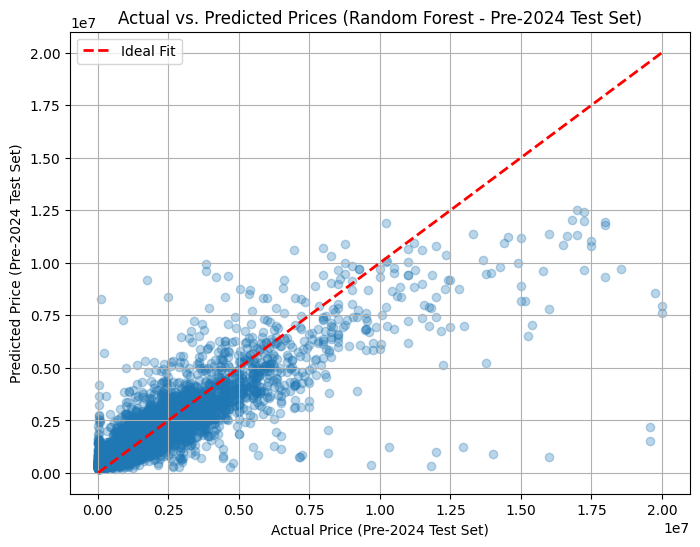


--- Preparing 2024 Data for Prediction ---
Applied label encoding to 2024 data column: postcode
Applied label encoding to 2024 data column: property type
Applied label encoding to 2024 data column: old/new
Applied label encoding to 2024 data column: duration
Applied label encoding to 2024 data column: PAON
Applied label encoding to 2024 data column: street
Applied label encoding to 2024 data column: locality
Applied label encoding to 2024 data column: town/city
Applied label encoding to 2024 data column: district
Applied label encoding to 2024 data column: county
Applied label encoding to 2024 data column: PPD category type
Applied label encoding to 2024 data column: epc_property_type
Applied label encoding to 2024 data column: epc_energy_rating
Shape of 2024 features after alignment: (14342, 21)
Filling 14342 NaN values in 2024 numerical features with 0.

--- Predicting Prices for 2024 Data ---
Added 'predicted_price' column to the 2024 DataFrame.

--- Model Evaluation (2024 Data Onl

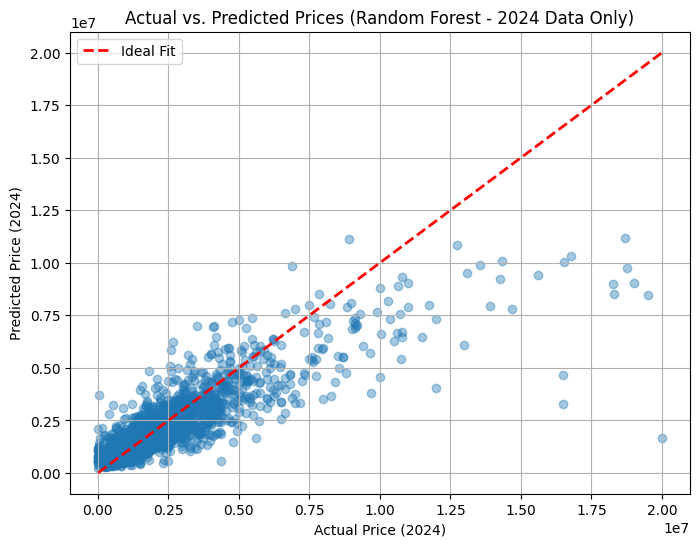


--- Sample Price Prediction (Random Forest - Using Pre-2024 Sample) ---

Selected Sample (Index: 13181 from pre-2024 data):
  Original Date: 2015-09-18
  Original Price: £2,625,000.00
  Address: BARROWGATE ROAD, LONDON, HOUNSLOW, GREATER LONDON, W4 4QU

Prediction for Original Year (2015): £1,862,138.68
Prediction for Year 2026: £1,826,507.17
Prediction for Year 2028: £1,826,507.17

Comparison:
  Actual (2015):      £2,625,000.00
  Predicted (2015): £1,862,138.68
  Predicted (2026):     £1,826,507.17
  Predicted (2028):     £1,826,507.17

--- Script Finished ---


In [ ]:
import numpy as np
import pandas as pd
from math import sqrt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import warnings # Import warnings
warnings.filterwarnings("ignore") # <-- Ignores ALL warnings! Use with extreme caution.



# --- Constants ---
TARGET_YEAR_FOR_SEPARATION = 2024 # Define the year to separate
MODEL_NAME = "Random Forest" # Define model name for titles/prints

# --- 1. Load Data ---
try:
    df = pd.read_csv("london_merged_df_filtered_2015.csv")
    print(f"Successfully loaded data. Initial shape: {df.shape}")
except FileNotFoundError:
    # Adjusted error message slightly for clarity
    print("Error: london_merged_df_filtered.csv not found. Please ensure the file is in the correct directory.")
    exit() # Exit if file not found

# Added errors='ignore' for robustness if columns are already dropped
df = df.drop(columns=['postcode_cleaned', 'ppd_address_key', 'epc_address_key',
       'lodgement_date','lmk_key','epc_built_form','epc_age_band'], errors='ignore')



#  Basic Cleaning & Filtering ---
print("\n--- Initial Cleaning ---")
initial_rows = len(df)

df = df.dropna(subset=["postcode","epc_floor_area","epc_habitable_rooms"])
print(f"Dropped {initial_rows - len(df)} rows with missing values in key columns (postcode, epc_floor_area, epc_habitable_rooms).")

initial_rows = len(df)
df = df.drop(columns=['record status - monthly file only', "Transaction unique identifier"], errors='ignore')
print("Dropped specified identifier columns.")

initial_rows = len(df)

df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price']) 
df['price'] = df['price'].astype(float) # Ensure price is float for comparison

df = df[(df["price"] >= 10_000) & (df["price"] <= 2_0000_000)]
print(f"Filtered {initial_rows - len(df)} rows with price outside £10k-£20M range or non-numeric price.")
print(f"DataFrame shape after initial cleaning: {df.shape}")


# Feature Engineering (Date) ---
print("\n--- Feature Engineering (Date) ---")
df["date of transfer"] = pd.to_datetime(df["date of transfer"], format="%Y-%m-%d", errors="coerce")
initial_rows = len(df)
df = df.dropna(subset=["date of transfer"]) # Drop rows where date couldn't be parsed
print(f"Dropped {initial_rows - len(df)} rows with invalid date format.")

# Extract meaningful date features
df['year']    = df['date of transfer'].dt.year
df["month"]   = df['date of transfer'].dt.month
df["day"]     = df['date of transfer'].dt.day
df["weekday"] = df['date of transfer'].dt.weekday
df["quarter"] = df['date of transfer'].dt.quarter
print("Extracted date features (year, month, day, weekday, quarter).")
print(f"Years present in data: {sorted(df['year'].unique())}")


#  Separate Target Year Data ---
print(f"\n--- Separating {TARGET_YEAR_FOR_SEPARATION} Data ---")
# Check if the target year exists after sampling and cleaning
if TARGET_YEAR_FOR_SEPARATION in df['year'].unique():
    df_target_year = df[df['year'] == TARGET_YEAR_FOR_SEPARATION].copy() # Create a copy for target year data
    df = df[df['year'] != TARGET_YEAR_FOR_SEPARATION] # Remove target year data from the main dataframe
    print(f"Number of rows in training data (pre-{TARGET_YEAR_FOR_SEPARATION}): {len(df)}")
    print(f"Number of rows set aside for {TARGET_YEAR_FOR_SEPARATION} evaluation: {len(df_target_year)}")
else:
    print(f"Warning: Year {TARGET_YEAR_FOR_SEPARATION} not found in the sampled and cleaned data. Cannot separate.")
    df_target_year = pd.DataFrame() # Create an empty DataFrame


df_original_lookup = df.copy() # Contains sampled, pre-target year data with original columns

print(f"\n--- Preparing Training Data (Pre-{TARGET_YEAR_FOR_SEPARATION}) ---")
# Drop the original date column for the training dataframe
train_df = df.drop(columns=['date of transfer'])


categorical_cols = [col for col in train_df.columns if train_df[col].dtype == 'O']
print(f"Identified categorical columns: {categorical_cols}")


label_encoders = {}

for col in categorical_cols:

    train_df[col].fillna('Missing', inplace=True)
    # Ensure column is string type for LabelEncoder
    train_df[col] = train_df[col].astype(str)
    # Initialize and fit LabelEncoder
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    # Store the fitted encoder
    label_encoders[col] = le
    print(f"Label encoded column: {col}")

# Print shape after encoding (number of columns won't change with label encoding)
print(f"Shape after label encoding: {train_df.shape}")



initial_nans = train_df.isna().sum().sum()
if initial_nans > 0:
    print(f"Filling {initial_nans} potential NaN values in numerical columns with 0.")
    # Consider a more sophisticated imputation strategy if appropriate (e.g., median)
    train_df.fillna(0, inplace=True) #

# Define Features (X) and Target (y) for training
X = train_df.drop(['price'], axis=1)
y = train_df['price']

# Check if training data is empty
if X.empty or y.empty:
    print("Error: Training data (X or y) is empty after preprocessing. Cannot proceed.")
    exit()

# Split into training and testing sets (using only pre-target year data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data shape (X_train): {X_train.shape}")
print(f"Testing data shape (X_test): {X_test.shape}")


# --- 7. Train the Random Forest Model ---
print(f"\n--- Training {MODEL_NAME} Model ---")
# Instantiate Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100,
                                 random_state=42,
                                 n_jobs=-1,
                                 oob_score=True,
                                 max_features='sqrt')

rf_model.fit(X_train, y_train)
print("Model training complete.")


# Evaluate Model on the Test Set (Pre-Target Year Data) ---
print(f"\n--- Model Evaluation (Test Set - Pre-{TARGET_YEAR_FOR_SEPARATION} Data) ---")
predictions_test = rf_model.predict(X_test)

mae_test = mean_absolute_error(y_test, predictions_test)
mse_test = mean_squared_error(y_test, predictions_test)
rmse_test = sqrt(mse_test)
r2_test = r2_score(y_test, predictions_test)



print(f'  MAE: {mae_test:.2f}')
print(f'  MSE: {mse_test:.2f}')
print(f'  RMSE: {rmse_test:.2f}')
print(f"  R-squared (R²): {r2_test:.2f}")


# --- 9. Plot Actual vs. Predicted (Test Set - Pre-Target Year Data) ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions_test, alpha=0.3)
plt.xlabel(f"Actual Price (Pre-{TARGET_YEAR_FOR_SEPARATION} Test Set)")
plt.ylabel(f"Predicted Price (Pre-{TARGET_YEAR_FOR_SEPARATION} Test Set)")
plt.title(f"Actual vs. Predicted Prices ({MODEL_NAME} - Pre-{TARGET_YEAR_FOR_SEPARATION} Test Set)")
min_price = min(y_test.min(), predictions_test.min()) if len(y_test)>0 else 0
max_price = max(y_test.max(), predictions_test.max()) if len(y_test)>0 else 0
# Add NaN check for plot limits
if min_price != max_price and not np.isnan(min_price) and not np.isnan(max_price):
    plt.plot([min_price, max_price], [min_price, max_price], 'r--', lw=2, label='Ideal Fit')
plt.legend()
plt.grid(True)
plt.show()


# --- 10. Prepare Target Year Data for Prediction ---
print(f"\n--- Preparing {TARGET_YEAR_FOR_SEPARATION} Data for Prediction ---")
if not df_target_year.empty:
    # Apply the same preprocessing steps as the training data
    df_target_year_processed = df_target_year.drop(columns=['date of transfer'])

    for col in categorical_cols:
         if col in df_target_year_processed.columns:
             # Handle NaNs before encoding, using the same placeholder
             df_target_year_processed[col].fillna('Missing', inplace=True)
             # Ensure column is string type
             df_target_year_processed[col] = df_target_year_processed[col].astype(str)
             # Retrieve the stored encoder
             if col in label_encoders:
                 le = label_encoders[col]
                 # Get known classes from the fitted encoder
                 known_classes = set(le.classes_)

                 df_target_year_processed[col] = df_target_year_processed[col].apply(
                     lambda x: le.transform([x])[0] if x in known_classes else -1 # Assign -1 to unknown categories
                 )
                 print(f"Applied label encoding to {TARGET_YEAR_FOR_SEPARATION} data column: {col}")
             else:
                  # This case should ideally not happen if categorical_cols are derived from train_df correctly
                  print(f"Warning: Label encoder for column '{col}' not found. Filling with -1.")
                  df_target_year_processed[col] = -1 # Fill with placeholder if encoder somehow missing
         else:
             # This handles cases where a categorical column identified in training data is missing in target year data
             print(f"Warning: Categorical column '{col}' not found in {TARGET_YEAR_FOR_SEPARATION} data during processing.")


    # Separate features (X_target_year) and actual prices (y_target_year)
    y_target_year_actual = df_target_year_processed['price']
    X_target_year = df_target_year_processed.drop('price', axis=1)


    X_target_year = X_target_year.reindex(columns=X_train.columns, fill_value=0)
    print(f"Shape of {TARGET_YEAR_FOR_SEPARATION} features after alignment: {X_target_year.shape}")

    # Fill any remaining NaNs (e.g., in numerical columns that weren't dropped or imputed earlier)
    initial_nans_target_year = X_target_year.isna().sum().sum()
    if initial_nans_target_year > 0:
        print(f"Filling {initial_nans_target_year} NaN values in {TARGET_YEAR_FOR_SEPARATION} numerical features with 0.")
        X_target_year.fillna(0, inplace=True)



    print(f"\n--- Predicting Prices for {TARGET_YEAR_FOR_SEPARATION} Data ---")
    predictions_target_year = rf_model.predict(X_target_year) # Use rf_model here


    df_target_year['predicted_price'] = predictions_target_year
    print(f"Added 'predicted_price' column to the {TARGET_YEAR_FOR_SEPARATION} DataFrame.")

   
    print(f"\n--- Model Evaluation ({TARGET_YEAR_FOR_SEPARATION} Data Only) ---")
    mae_target_year = mean_absolute_error(y_target_year_actual, predictions_target_year)
    mse_target_year = mean_squared_error(y_target_year_actual, predictions_target_year)
    rmse_target_year = sqrt(mse_target_year)
    r2_target_year = r2_score(y_target_year_actual, predictions_target_year)

    print(f'  MAE ({TARGET_YEAR_FOR_SEPARATION}): {mae_target_year:.2f}')
    print(f'  MSE ({TARGET_YEAR_FOR_SEPARATION}): {mse_target_year:.2f}')
    print(f'  RMSE ({TARGET_YEAR_FOR_SEPARATION}): {rmse_target_year:.2f}')
    print(f"  R-squared (R²) ({TARGET_YEAR_FOR_SEPARATION}): {r2_target_year:.2f}")

    # Compare Actual vs Predicted Prices for Target Year ---
    print(f"\n--- Comparison of Actual vs Predicted Prices (Year {TARGET_YEAR_FOR_SEPARATION}) ---")
    # Display the first few rows with actual and predicted prices
    print(df_target_year[['price', 'predicted_price']].head())

    # Optionally, display descriptive statistics for comparison
    print(f"\nDescriptive Statistics for {TARGET_YEAR_FOR_SEPARATION} Prices:")
    print(df_target_year[['price', 'predicted_price']].describe())

    # Plot Actual vs. Predicted (Target Year Data) ---
    plt.figure(figsize=(8, 6))
    plt.scatter(df_target_year['price'], df_target_year['predicted_price'], alpha=0.4)
    plt.xlabel(f"Actual Price ({TARGET_YEAR_FOR_SEPARATION})")
    plt.ylabel(f"Predicted Price ({TARGET_YEAR_FOR_SEPARATION})")
    plt.title(f"Actual vs. Predicted Prices ({MODEL_NAME} - {TARGET_YEAR_FOR_SEPARATION} Data Only)") # Updated title
    # Handle potential edge cases for plotting limits (empty df, single point, NaNs)
    if len(df_target_year) > 1 and df_target_year['price'].nunique() > 1 and df_target_year['predicted_price'].nunique() > 1 :
        min_price_target_year = df_target_year[['price', 'predicted_price']].min().min() # Simpler min/max finding
        max_price_target_year = df_target_year[['price', 'predicted_price']].max().max()
        # Add NaN checks for plot limits
        if min_price_target_year != max_price_target_year and not np.isnan(min_price_target_year) and not np.isnan(max_price_target_year):
           plt.plot([min_price_target_year, max_price_target_year], [min_price_target_year, max_price_target_year], 'r--', lw=2, label='Ideal Fit')
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print(f"\n--- No Data Found for Year {TARGET_YEAR_FOR_SEPARATION} ---")
    print(f"Skipping prediction and evaluation for {TARGET_YEAR_FOR_SEPARATION}.")


#  Sample Prediction Section
# This section uses data derived from train_df, which is already label-encoded.
print(f"\n--- Sample Price Prediction ({MODEL_NAME} - Using Pre-{TARGET_YEAR_FOR_SEPARATION} Sample) ---") # Updated title

if not df_original_lookup.empty:
    # Select a random sample from the pre-target year lookup table
    sample_original_df = df_original_lookup.sample(1, random_state=42) # random_state=42 ensures reproducibility

    if not sample_original_df.empty: # Check if sample is valid
        sample_index = sample_original_df.index[0]

        # Get original details from the lookup table
        original_date = sample_original_df['date of transfer'].iloc[0]
        original_year = sample_original_df['year'].iloc[0]
        original_price = sample_original_df['price'].iloc[0]
        address_fields = ['paon', 'saon', 'street', 'locality', 'town/city', 'district', 'county', 'postcode']
        original_address = ", ".join(str(sample_original_df[col].iloc[0]) for col in address_fields if col in sample_original_df.columns and pd.notna(sample_original_df[col].iloc[0]))

        print(f"\nSelected Sample (Index: {sample_index} from pre-{TARGET_YEAR_FOR_SEPARATION} data):")
        print(f"  Original Date: {original_date.strftime('%Y-%m-%d')}")
        print(f"  Original Price: £{original_price:,.2f}")
        print(f"  Address: {original_address}")

       
        if sample_index in train_df.index:
            sample_processed_row = train_df.loc[[sample_index]] # Use double brackets to keep it a DataFrame

            # Ensure the sample has the same columns as X_train (important if columns were dropped/added)
            X_sample = sample_processed_row.drop('price', axis=1)
            # Realign just in case something changed, using X_train columns as the reference
            X_sample = X_sample.reindex(columns=X_train.columns, fill_value=0)


            
            prediction_original_year = rf_model.predict(X_sample)[0]
            print(f"\nPrediction for Original Year ({original_year}): £{prediction_original_year:,.2f}")

            # Predict for future years (these remain hypothetical future predictions)
            target_year_1 = 2026 # Example future year 1
            X_sample_future_1 = X_sample.copy()
            if 'year' in X_sample_future_1.columns:
                 X_sample_future_1['year'] = target_year_1
                 prediction_future_1 = rf_model.predict(X_sample_future_1)[0] # Use rf_model
                 print(f"Prediction for Year {target_year_1}: £{prediction_future_1:,.2f}")
            else:
                 print(f"Warning: 'year' column not found in sample features. Cannot predict for {target_year_1}.")
                 prediction_future_1 = np.nan # Set prediction to NaN

            target_year_2 = 2028 # Example future year 2
            X_sample_future_2 = X_sample.copy()
            if 'year' in X_sample_future_2.columns:
                 X_sample_future_2['year'] = target_year_2
                 prediction_future_2 = rf_model.predict(X_sample_future_2)[0] # Use rf_model
                 print(f"Prediction for Year {target_year_2}: £{prediction_future_2:,.2f}")
            else:
                 print(f"Warning: 'year' column not found in sample features. Cannot predict for {target_year_2}.")
                 prediction_future_2 = np.nan # Set prediction to NaN


            # Print Comparison
            print("\nComparison:")
            print(f"  Actual ({original_year}):      £{original_price:,.2f}")
            print(f"  Predicted ({original_year}): £{prediction_original_year:,.2f}")
            if not np.isnan(prediction_future_1): print(f"  Predicted ({target_year_1}):     £{prediction_future_1:,.2f}")
            if not np.isnan(prediction_future_2): print(f"  Predicted ({target_year_2}):     £{prediction_future_2:,.2f}")
        else:
            print(f"Sample index {sample_index} not found in the processed training data (train_df). Skipping sample prediction.")
    else:
         print("Could not select a valid sample from the original lookup DataFrame. Skipping sample prediction.")
else:
    print(f"Original lookup DataFrame (pre-{TARGET_YEAR_FOR_SEPARATION}) is empty. Skipping sample prediction.")

NN 2024

2025-04-25 11:25:13.955755: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-25 11:25:14.038576: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-25 11:25:14.106967: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745576714.162579  334093 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745576714.177877  334093 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745576714.185096  334093 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

Successfully loaded data. Initial shape: (601221, 28)

--- Initial Cleaning & Filtering ---
Dropped 14166 rows with missing values in key columns (postcode, epc_floor_area, epc_habitable_rooms).
Dropped specified identifier columns.
Filtered 1164 rows with price outside £10k-£20M range or non-numeric price.
DataFrame shape after initial cleaning/filtering: (585891, 19)

--- Feature Engineering (Date) ---
Dropped 0 rows with invalid date format.
Extracted date features.
Years present in data after cleaning: [np.int32(1995), np.int32(1996), np.int32(1997), np.int32(1998), np.int32(1999), np.int32(2000), np.int32(2001), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int3

2025-04-25 11:25:19.554855: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,137 (43.50 KB)

 Trainable params: 11,137 (43.50 KB)

 Non-trainable params: 0 (0.00 B)


Starting model training...
Epoch 1/200
5716/5716 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.5839 - mae: 0.3244 - mse: 0.4930 - val_loss: 0.3708 - val_mae: 0.2400 - val_mse: 0.3226
Epoch 2/200
5716/5716 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.4114 - mae: 0.2608 - mse: 0.3677 - val_loss: 0.3601 - val_mae: 0.2351 - val_mse: 0.3262
Epoch 3/200
5716/5716 ━━━━━━━━━━━━━━━━━━━━ 6s 962us/step - loss: 0.3745 - mae: 0.2539 - mse: 0.3421 - val_loss: 0.3266 - val_mae: 0.2247 - val_mse: 0.2958
Epoch 4/200
5716/5716 ━━━━━━━━━━━━━━━━━━━━ 5s 952us/step - loss: 0.3707 - mae: 0.2547 - mse: 0.3401 - val_loss: 0.3244 - val_mae: 0.2264 - val_mse: 0.2958
Epoch 5/200
5716/5716 ━━━━━━━━━━━━━━━━━━━━ 5s 952us/step - loss: 0.3603 - mae: 0.2531 - mse: 0.3321 - val_loss: 0.3337 - val_mae: 0.2300 - val_mse: 0.3057
Epoch 6/200
5716/5716 ━━━━━━━━━━━━━━━━━━━━ 5s 919us/step - loss: 0.3360 - mae: 0.2487 - mse: 0.3079 - val_loss: 0.3163 - val_mae: 0.2221 - val_mse: 0.2877
Epoch 7/200
5716/5716 ━━━━━━━━━━━━━━━━━━━━ 5s 

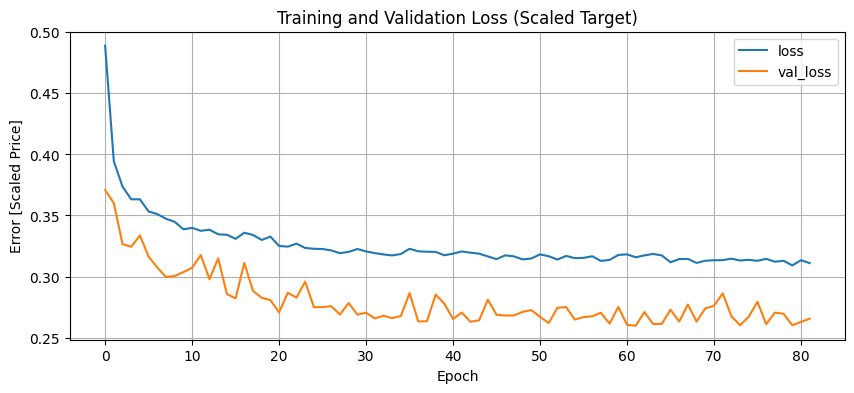


--- Evaluating Model on Test Set (Pre-2024 Data) ---
3573/3573 ━━━━━━━━━━━━━━━━━━━━ 1s 360us/step

Metrics on Original Price Scale (Test Set):
  MAE: 176,363.60
  MSE: 156,863,958,814.63
  RMSE: 396,060.55
  R-squared (R²): 0.7491


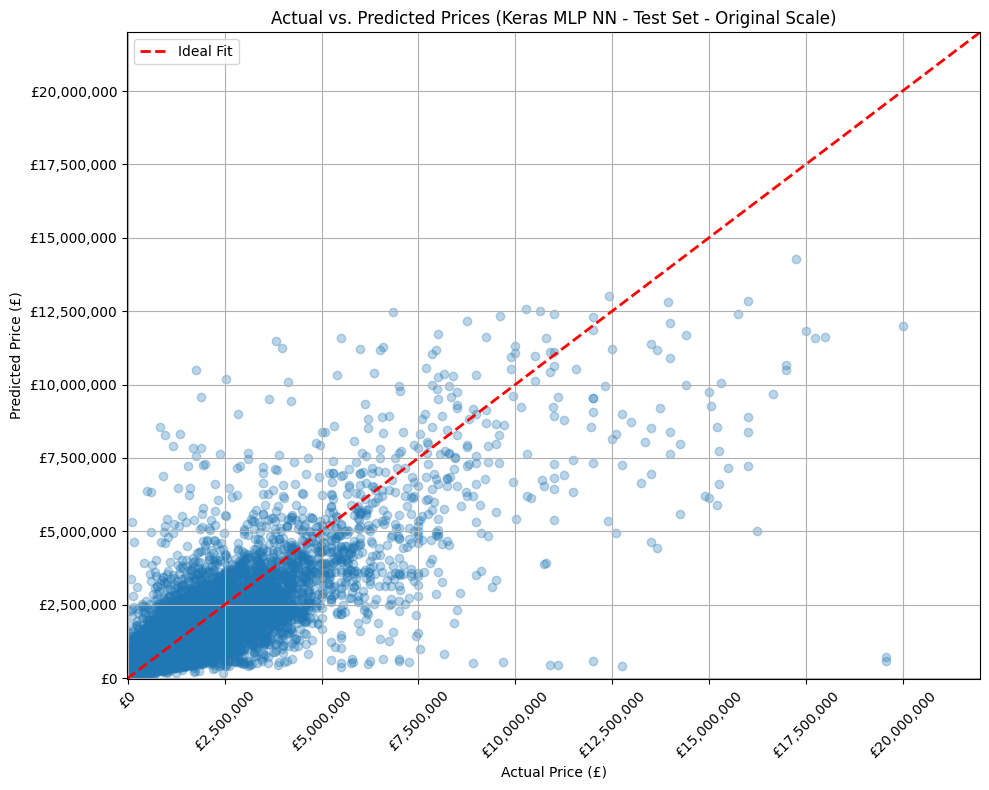


--- Preparing and Predicting on 2024 Data ---
Applied label encoding to 2024 data column: postcode
Applied label encoding to 2024 data column: property type
Applied label encoding to 2024 data column: old/new
Applied label encoding to 2024 data column: duration
Applied label encoding to 2024 data column: PAON
Applied label encoding to 2024 data column: street
Applied label encoding to 2024 data column: locality
Applied label encoding to 2024 data column: town/city
Applied label encoding to 2024 data column: district
Applied label encoding to 2024 data column: county
Applied label encoding to 2024 data column: PPD category type
Applied label encoding to 2024 data column: epc_property_type
Applied label encoding to 2024 data column: epc_energy_rating
Shape of 2024 features after align: (14342, 21)
Filling 14342 NaN values in 2024 features with 0.
Shape of 2024 features after scaling: (14342, 21)
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 361us/step
Added 'predicted_price' column (original scale) t

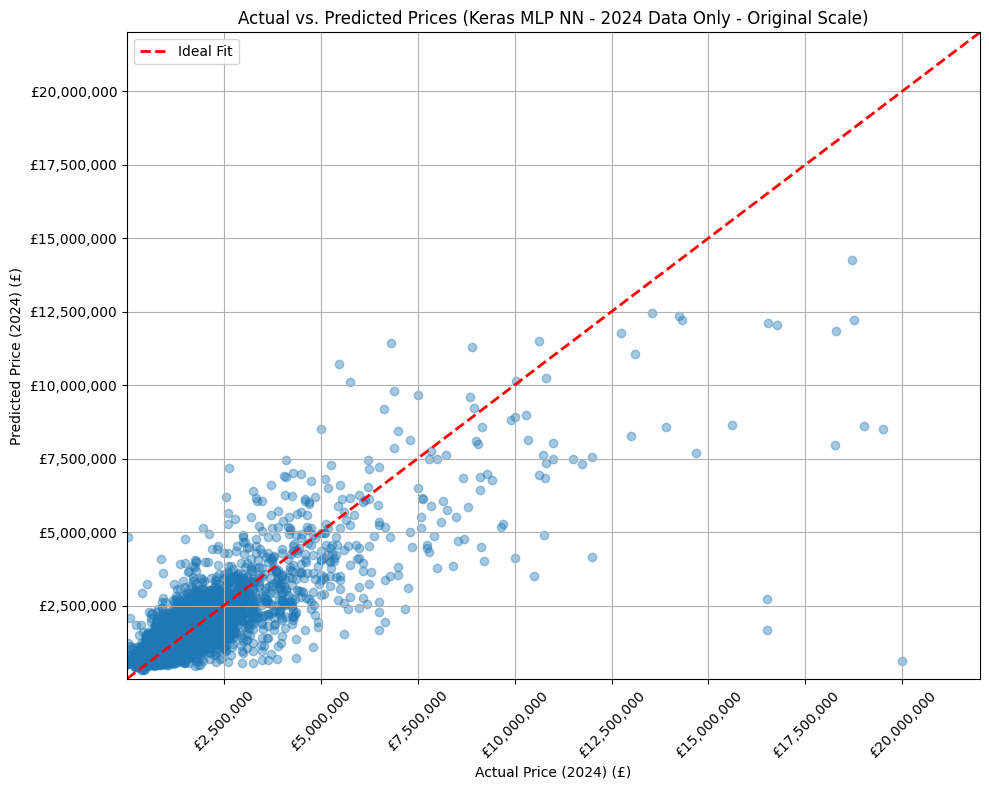


--- Sample Price Prediction (Keras MLP NN - Using Pre-2024 Sample) ---

Selected Sample (Index: 401656):
  Original Date of Transfer: 2014-04-29
  Original Actual Price: £900,000.00
  Address: SHIREHALL PARK, LONDON, BARNET, GREATER LONDON, NW4 2QU
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

Prediction for Original Year (2014): £912,861.06
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Prediction for Year 2026: £1,519,846.88
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Prediction for Year 2028: £1,628,808.38

Comparison:
  Actual (2014):      £900,000.00
  Predicted (2014): £912,861.06
  Predicted (2026):     £1,519,846.88
  Predicted (2028):     £1,628,808.38

--- Script Finished ---


In [ ]:
import numpy as np
import pandas as pd
from math import sqrt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler # Keep StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore") 


TARGET_YEAR_FOR_SEPARATION = 2024 # Define the year to separate
MODEL_NAME = "Keras MLP NN" # Define model name for titles/prints


df = pd.read_csv("london_merged_df_filtered.csv")


df = df.drop(columns=['postcode_cleaned', 'ppd_address_key', 'epc_address_key',
       'lodgement_date','lmk_key','epc_built_form','epc_age_band'], errors='ignore')

# Basic Cleaning & Filtering ---
print("\n--- Initial Cleaning & Filtering ---")
initial_rows = len(df)

df = df.dropna(subset=["postcode","epc_floor_area","epc_habitable_rooms"])
print(f"Dropped {initial_rows - len(df)} rows with missing values in key columns (postcode, epc_floor_area, epc_habitable_rooms).")

initial_rows = len(df)
df = df.drop(columns=['record status - monthly file only', "Transaction unique identifier"], errors='ignore')
print("Dropped specified identifier columns.")

initial_rows = len(df)
# Ensure 'price' is numeric before filtering
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price']) # Drop rows where price couldn't be converted
df['price'] = df['price'].astype(float) # Ensure price is float for comparison
# Filter Outliers
df = df[(df["price"] >= 10_000) & (df["price"] <= 2_0000_000)]
print(f"Filtered {initial_rows - len(df)} rows with price outside £10k-£20M range or non-numeric price.")
print(f"DataFrame shape after initial cleaning/filtering: {df.shape}")

# Feature Engineering (Date) ---
print("\n--- Feature Engineering (Date) ---")
df["date of transfer"] = pd.to_datetime(df["date of transfer"], format="%Y-%m-%d", errors="coerce")
initial_rows = len(df)
df = df.dropna(subset=["date of transfer"]) # Drop rows where date couldn't be parsed
print(f"Dropped {initial_rows - len(df)} rows with invalid date format.")

# Extract meaningful date features
df['year']    = df['date of transfer'].dt.year
df["month"]   = df['date of transfer'].dt.month
df["day"]     = df['date of transfer'].dt.day
df["weekday"] = df['date of transfer'].dt.weekday
df["quarter"] = df['date of transfer'].dt.quarter
print("Extracted date features.")
print(f"Years present in data after cleaning: {sorted(df['year'].unique())}")

#  Separate Target Year Data --- # Changed target year back to constant
print(f"\n--- Separating {TARGET_YEAR_FOR_SEPARATION} Data ---")
# Check if the target year exists after sampling and cleaning
if TARGET_YEAR_FOR_SEPARATION in df['year'].unique():
    # Use df_target_year as the variable name for the separated data
    df_target_year = df[df['year'] == TARGET_YEAR_FOR_SEPARATION].copy()
    df = df[df['year'] != TARGET_YEAR_FOR_SEPARATION] # Remove target year data from the main dataframe (for training)
    print(f"Number of rows in training data (pre-{TARGET_YEAR_FOR_SEPARATION}): {len(df)}")
    print(f"Number of rows set aside for {TARGET_YEAR_FOR_SEPARATION} evaluation: {len(df_target_year)}")
else:
    print(f"Warning: Year {TARGET_YEAR_FOR_SEPARATION} not found in the sampled and cleaned data. Cannot separate.")
    df_target_year = pd.DataFrame() # Create an empty DataFrame

# Keep a copy for sample lookup (now only contains pre-target year data)
df_original_lookup = df.copy()

#  Prepare Data for Training (Pre-Target Year) ---
print(f"\n--- Preparing Training Data (Pre-{TARGET_YEAR_FOR_SEPARATION}) ---")
# Drop the original date column for the training dataframe
train_df = df.drop(columns=['date of transfer'])

# Identify categorical columns
categorical_cols = [col for col in train_df.columns if train_df[col].dtype == 'O']
print(f"Identified categorical columns: {categorical_cols}")


label_encoders = {} # Dictionary to store fitted encoders

for col in categorical_cols:
    # Handle NaNs before encoding: fill with a placeholder string
    train_df[col].fillna('Missing', inplace=True)
    # Ensure column is string type for LabelEncoder
    train_df[col] = train_df[col].astype(str)
    # Initialize and fit LabelEncoder
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    # Store the fitted encoder
    label_encoders[col] = le
    print(f"Label encoded column: {col}")

# Print shape after encoding (number of columns won't change with label encoding)
print(f"Shape after label encoding: {train_df.shape}")

# Fill NaNs in numerical columns (if any remain)
initial_nans = train_df.isna().sum().sum()
if initial_nans > 0:
    print(f"Filling {initial_nans} potential NaN values in numerical columns with 0.")
    train_df.fillna(0, inplace=True)

# Define Features (X) and Target (y) for training
X = train_df.drop(['price'], axis=1)
y = train_df['price']

# Get the number of features *after* preprocessing for the Input layer
n_features = X.shape[1]
print(f"Number of features after preprocessing: {n_features}")


if X.empty or y.empty:
    print("Error: Training data (X or y) is empty after preprocessing. Cannot proceed.")
    exit()

# Split into training and testing sets (using only pre-target year data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data shape (X_train): {X_train.shape}")
print(f"Testing data shape (X_test): {X_test.shape}")


print("\n--- Scaling Features and Target ---")
x_scaler = StandardScaler()
# Fit scaler ONLY on training data features
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)
print("Features scaled using StandardScaler.")


y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
# Transform y_test using the *same* scaler fitted on y_train
# y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1)) # Only needed if evaluating loss on scaled test data directly
print("Target variable (price) scaled using StandardScaler.")

# Define and Train the Keras Model ---
print(f"\n--- Defining and Training {MODEL_NAME} Model ---")
# Using the build function from the user's provided code (no changes needed here)
def build_and_compile_model(n_features):
  model = keras.Sequential([
      layers.Input(shape=(n_features,)),
      layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
      layers.Dropout(0.3),
      layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
      layers.Dropout(0.3),
      layers.Dense(1) # Output layer for regression
  ])

  model.compile(loss='mean_squared_error',
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
                metrics=['mae', 'mse']) # MAE and MSE on the SCALED target
  return model

nn_model = build_and_compile_model(n_features)
nn_model.summary()

# Define callbacks 
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor validation loss (on scaled target)
    patience=20,        # Stop after 20 epochs with no improvement
    restore_best_weights=True, # Restore weights from the best epoch
    verbose=1
)


print("\nStarting model training...")

if X_train_scaled.shape[0] == 0 or y_train_scaled.shape[0] == 0:
    print("Error: Training data is empty after scaling/splitting. Cannot train model.")
    exit()

history = nn_model.fit(
    X_train_scaled,
    y_train_scaled, # Use scaled target for training
    epochs=200,           # Number of training epochs
    batch_size=64,        # Batch size
    validation_split=0.2, # Use 20% of training data for validation
    verbose=1,            # Show progress per epoch
    callbacks=[early_stopping] # Apply early stopping
)
print("Model training complete.")




print(f"\n--- Evaluating Model on Test Set (Pre-{TARGET_YEAR_FOR_SEPARATION} Data) ---")
# Predict SCALED prices on SCALED test data
scaled_predictions_test = nn_model.predict(X_test_scaled)


predictions_test_original_scale = y_scaler.inverse_transform(scaled_predictions_test).flatten()


valid_indices_test = np.isfinite(predictions_test_original_scale) & np.isfinite(y_test.values)
if not np.all(valid_indices_test):
    print(f"Warning: Found {np.sum(~valid_indices_test)} non-finite values in test set final predictions or actuals. Removing them for evaluation.")
    predictions_eval_test = predictions_test_original_scale[valid_indices_test]
    y_test_eval = y_test.values[valid_indices_test]
else:
    predictions_eval_test = predictions_test_original_scale
    y_test_eval = y_test.values # Use original y_test values


if len(predictions_eval_test) > 0 and len(y_test_eval) > 0:
    mae_test = mean_absolute_error(y_test_eval, predictions_eval_test)
    mse_test = mean_squared_error(y_test_eval, predictions_eval_test)
    rmse_test = sqrt(max(0, mse_test)) # Prevent sqrt of potential tiny negative due to precision
    r2_test = r2_score(y_test_eval, predictions_eval_test)

    print("\nMetrics on Original Price Scale (Test Set):")
    print(f'  MAE: {mae_test:,.2f}')
    print(f'  MSE: {mse_test:,.2f}')
    print(f'  RMSE: {rmse_test:,.2f}')
    print(f"  R-squared (R²): {r2_test:.4f}")
else:
     print("Could not evaluate model on test set as no valid predictions or actual values were available after cleaning.")

# Plot Actual vs. Predicted (Test Set - Pre-Target Year Data) ---
if len(predictions_eval_test) > 0 and len(y_test_eval) > 0:
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_eval, predictions_eval_test, alpha=0.3)
    plt.xlabel("Actual Price (£)")
    plt.ylabel("Predicted Price (£)")
    plt.title(f"Actual vs. Predicted Prices ({MODEL_NAME} - Test Set - Original Scale)")
    min_price_val = min(y_test_eval.min(), predictions_eval_test.min()) * 0.9
    max_price_val = max(y_test_eval.max(), predictions_eval_test.max()) * 1.1
    if min_price_val >= max_price_val: max_price_val = min_price_val + 10000 # Prevent equal limits
    plt.plot([min_price_val, max_price_val], [min_price_val, max_price_val], 'r--', lw=2, label='Ideal Fit')
    plt.xlim(min_price_val, max_price_val)
    plt.ylim(min_price_val, max_price_val)
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping test set plot due to lack of valid data points.")

# Prepare and Predict on Target Year Data 
print(f"\n--- Preparing and Predicting on {TARGET_YEAR_FOR_SEPARATION} Data ---")
# Use df_target_year which was created in step 5
if not df_target_year.empty:
    try:
        # Store original prices for evaluation
        y_target_year_actual_original = df_target_year['price'].copy()

        # Prepare features for target year data
        # Drop price and date here
        df_target_year_processed = df_target_year.drop(columns=['date of transfer', 'price'])


        for col in categorical_cols:
             if col in df_target_year_processed.columns:
                 # Handle NaNs before encoding, using the same placeholder
                 df_target_year_processed[col].fillna('Missing', inplace=True)
                 # Ensure column is string type
                 df_target_year_processed[col] = df_target_year_processed[col].astype(str)
                 # Retrieve the stored encoder
                 if col in label_encoders:
                     le = label_encoders[col]
                     # Get known classes from the fitted encoder
                     known_classes = set(le.classes_)
                     # Handle potential new/unknown categories: map them to a specific value (e.g., -1)
                     df_target_year_processed[col] = df_target_year_processed[col].apply(
                         lambda x: le.transform([x])[0] if x in known_classes else -1 # Assign -1 to unknown
                     )
                     print(f"Applied label encoding to {TARGET_YEAR_FOR_SEPARATION} data column: {col}")
                 else:
                      print(f"Warning: Label encoder for column '{col}' not found. Filling with -1.")
                      df_target_year_processed[col] = -1 # Fill with placeholder if encoder missing
             else:
                 # This handles cases where a categorical column identified in training data is missing in target year data
                 print(f"Warning: Categorical column '{col}' not found in {TARGET_YEAR_FOR_SEPARATION} data during processing. It will be handled by reindex.")


        X_target_year = df_target_year_processed


        X_target_year = X_target_year.reindex(columns=X.columns, fill_value=0)
        print(f"Shape of {TARGET_YEAR_FOR_SEPARATION} features after align: {X_target_year.shape}")


        initial_nans_target_year = X_target_year.isna().sum().sum()
        if initial_nans_target_year > 0:
            print(f"Filling {initial_nans_target_year} NaN values in {TARGET_YEAR_FOR_SEPARATION} features with 0.")
            X_target_year.fillna(0, inplace=True)


        X_target_year_scaled = x_scaler.transform(X_target_year)
        print(f"Shape of {TARGET_YEAR_FOR_SEPARATION} features after scaling: {X_target_year_scaled.shape}")


        scaled_predictions_target_year = nn_model.predict(X_target_year_scaled)


        predictions_target_year_original_scale = y_scaler.inverse_transform(scaled_predictions_target_year).flatten()

  
        df_target_year['predicted_price'] = predictions_target_year_original_scale
        print(f"Added 'predicted_price' column (original scale) to the {TARGET_YEAR_FOR_SEPARATION} DataFrame.")


        print(f"\n--- Model Evaluation ({TARGET_YEAR_FOR_SEPARATION} Data Only - Original Scale) ---")
        # Ensure finite values for evaluation
        target_valid_indices = np.isfinite(predictions_target_year_original_scale) & np.isfinite(y_target_year_actual_original.values)
        if not np.all(target_valid_indices):
            print(f"Warning: Found {np.sum(~target_valid_indices)} non-finite values in {TARGET_YEAR_FOR_SEPARATION} final predictions or actuals. Removing them for evaluation.")
            target_predictions_eval = predictions_target_year_original_scale[target_valid_indices]
            target_y_eval = y_target_year_actual_original.values[target_valid_indices]
        else:
            target_predictions_eval = predictions_target_year_original_scale
            target_y_eval = y_target_year_actual_original.values

        if len(target_predictions_eval) > 0 and len(target_y_eval) > 0:
            mae_target_year = mean_absolute_error(target_y_eval, target_predictions_eval)
            mse_target_year = mean_squared_error(target_y_eval, target_predictions_eval)
            rmse_target_year = sqrt(max(0, mse_target_year))
            r2_target_year = r2_score(target_y_eval, target_predictions_eval)

            print(f'  MAE ({TARGET_YEAR_FOR_SEPARATION}): {mae_target_year:,.2f}')
            print(f'  MSE ({TARGET_YEAR_FOR_SEPARATION}): {mse_target_year:,.2f}')
            print(f'  RMSE ({TARGET_YEAR_FOR_SEPARATION}): {rmse_target_year:,.2f}')
            print(f"  R-squared (R²) ({TARGET_YEAR_FOR_SEPARATION}): {r2_target_year:.4f}")

   
            print(f"\n--- Comparison of Actual vs Predicted Prices (Year {TARGET_YEAR_FOR_SEPARATION}) ---")
            print(df_target_year[['price', 'predicted_price']].head())
            print(f"\nDescriptive Statistics for {TARGET_YEAR_FOR_SEPARATION} Prices:")
            # Format describe output
            print(df_target_year[['price', 'predicted_price']].describe().applymap(lambda x: f"{x:,.0f}"))

            # Plot Target Year Actual vs Predicted (Original Scale)
            plt.figure(figsize=(10, 8))
            plt.scatter(target_y_eval, target_predictions_eval, alpha=0.4)
            plt.xlabel(f"Actual Price ({TARGET_YEAR_FOR_SEPARATION}) (£)")
            plt.ylabel(f"Predicted Price ({TARGET_YEAR_FOR_SEPARATION}) (£)")
            plt.title(f"Actual vs. Predicted Prices ({MODEL_NAME} - {TARGET_YEAR_FOR_SEPARATION} Data Only - Original Scale)")
            min_price_tgt = min(target_y_eval.min(), target_predictions_eval.min()) * 0.9
            max_price_tgt = max(target_y_eval.max(), target_predictions_eval.max()) * 1.1
            if min_price_tgt >= max_price_tgt: max_price_tgt = min_price_tgt + 10000 # Prevent equal limits
            plt.plot([min_price_tgt, max_price_tgt], [min_price_tgt, max_price_tgt], 'r--', lw=2, label='Ideal Fit')
            plt.xlim(min_price_tgt, max_price_tgt)
            plt.ylim(min_price_tgt, max_price_tgt)
            plt.legend()
            plt.grid(True)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
        else:
             print(f"Could not evaluate {TARGET_YEAR_FOR_SEPARATION} model as no valid predictions or actual values were available after cleaning.")
    except Exception as e:
        print(f"An error occurred during {TARGET_YEAR_FOR_SEPARATION} prediction/evaluation: {e}")
        import traceback
        traceback.print_exc()

else:
    print(f"\n--- No Data Found for Year {TARGET_YEAR_FOR_SEPARATION} ---")
    print(f"Skipping prediction and evaluation for {TARGET_YEAR_FOR_SEPARATION}.")

# Sample Prediction Section 
print(f"\n--- Sample Price Prediction ({MODEL_NAME} - Using Pre-{TARGET_YEAR_FOR_SEPARATION} Sample) ---")
if not df_original_lookup.empty:
    try:
        # Select a random sample from the pre-target year lookup table
        sample_original_df = df_original_lookup.sample(1, random_state=42)

        if not sample_original_df.empty: # Check if sample is valid
            sample_index = sample_original_df.index[0]

            # Get original details
            original_date = sample_original_df['date of transfer'].iloc[0]
            original_year = sample_original_df['year'].iloc[0]
            original_price = sample_original_df['price'].iloc[0] # Actual price
            address_fields = ['paon', 'saon', 'street', 'locality', 'town/city', 'district', 'county', 'postcode']
            original_address = ", ".join(str(sample_original_df[col].iloc[0]) for col in address_fields if col in sample_original_df.columns and pd.notna(sample_original_df[col].iloc[0]))

            print(f"\nSelected Sample (Index: {sample_index}):")
            print(f"  Original Date of Transfer: {original_date.strftime('%Y-%m-%d')}")
            print(f"  Original Actual Price: £{original_price:,.2f}")
            print(f"  Address: {original_address}")

            # Get the corresponding processed row from train_df (which is label encoded)
            if sample_index in train_df.index:
                sample_processed_row = train_df.loc[[sample_index]]

                X_sample_unscaled = sample_processed_row.drop('price', axis=1)

                X_sample_unscaled = X_sample_unscaled.reindex(columns=X.columns, fill_value=0)

   
                X_sample_scaled = x_scaler.transform(X_sample_unscaled)

  
                scaled_prediction_original_year = nn_model.predict(X_sample_scaled) # Output is 2D

                prediction_original_year = y_scaler.inverse_transform(scaled_prediction_original_year)[0, 0]
                print(f"\nPrediction for Original Year ({original_year}): £{prediction_original_year:,.2f}")


                target_year_1 = 2026
                X_sample_future_1_unscaled = X_sample_unscaled.copy()
                if 'year' in X_sample_future_1_unscaled.columns:
                    X_sample_future_1_unscaled['year'] = target_year_1
                    X_sample_future_1_scaled = x_scaler.transform(X_sample_future_1_unscaled)
                    scaled_prediction_future_1 = nn_model.predict(X_sample_future_1_scaled)
                    prediction_future_1 = y_scaler.inverse_transform(scaled_prediction_future_1)[0, 0]
                    print(f"Prediction for Year {target_year_1}: £{prediction_future_1:,.2f}")
                else:
                    print(f"Warning: 'year' column not found in sample features. Cannot predict for {target_year_1}.")
                    prediction_future_1 = np.nan

  
                target_year_2 = 2028
                X_sample_future_2_unscaled = X_sample_unscaled.copy()
                if 'year' in X_sample_future_2_unscaled.columns:
                    X_sample_future_2_unscaled['year'] = target_year_2
                    X_sample_future_2_scaled = x_scaler.transform(X_sample_future_2_unscaled)
                    scaled_prediction_future_2 = nn_model.predict(X_sample_future_2_scaled)
                    prediction_future_2 = y_scaler.inverse_transform(scaled_prediction_future_2)[0, 0]
                    print(f"Prediction for Year {target_year_2}: £{prediction_future_2:,.2f}")
                else:
                    print(f"Warning: 'year' column not found in sample features. Cannot predict for {target_year_2}.")
                    prediction_future_2 = np.nan

                print("\nComparison:")
                print(f"  Actual ({original_year}):      £{original_price:,.2f}")
                print(f"  Predicted ({original_year}): £{prediction_original_year:,.2f}")
                if not np.isnan(prediction_future_1): print(f"  Predicted ({target_year_1}):     £{prediction_future_1:,.2f}")
                if not np.isnan(prediction_future_2): print(f"  Predicted ({target_year_2}):     £{prediction_future_2:,.2f}")

            else:
                print(f"Sample index {sample_index} not found in the processed training data (train_df). Skipping sample prediction.")
        else:
             print("Could not select a valid sample from the original lookup DataFrame. Skipping sample prediction.")
    except Exception as e:
        print(f"An error occurred during sample prediction: {e}")
        import traceback
        traceback.print_exc()

else:
    print(f"Original lookup DataFrame (pre-{TARGET_YEAR_FOR_SEPARATION}) is empty. Skipping sample prediction.")

print("\n--- Script Finished ---")

NN 2024 10y

Successfully loaded data. Initial shape: (191678, 28)

--- Initial Cleaning & Filtering ---
Dropped 9538 rows with missing values in key columns (postcode, epc_floor_area, epc_habitable_rooms).
Dropped specified identifier columns.
Filtered 765 rows with price outside £10k-£20M range or non-numeric price.
DataFrame shape after initial cleaning/filtering: (181375, 19)

--- Feature Engineering (Date) ---
Dropped 0 rows with invalid date format.
Extracted date features.
Years present in data after cleaning: [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]

--- Separating 2024 Data ---
Number of rows in training data (pre-2024): 167033
Number of rows set aside for 2024 evaluation: 14342

--- Preparing Training Data (Pre-2024) ---
Identified categorical columns: ['postcode', 'property type', 'old/new', 'duration', 'PAON', 'street', 'locality', 'town/city', 'distric

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,137 (43.50 KB)

 Trainable params: 11,137 (43.50 KB)

 Non-trainable params: 0 (0.00 B)


Starting model training...
Epoch 1/200
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.6920 - mae: 0.3929 - mse: 0.5881 - val_loss: 0.4439 - val_mae: 0.2914 - val_mse: 0.3671
Epoch 2/200
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 2s 983us/step - loss: 0.5173 - mae: 0.3138 - mse: 0.4460 - val_loss: 0.4071 - val_mae: 0.2807 - val_mse: 0.3504
Epoch 3/200
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 2s 951us/step - loss: 0.4600 - mae: 0.3026 - mse: 0.4068 - val_loss: 0.3798 - val_mae: 0.2714 - val_mse: 0.3356
Epoch 4/200
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 2s 962us/step - loss: 0.4358 - mae: 0.2967 - mse: 0.3929 - val_loss: 0.3655 - val_mae: 0.2730 - val_mse: 0.3281
Epoch 5/200
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 2s 965us/step - loss: 0.4074 - mae: 0.2911 - mse: 0.3707 - val_loss: 0.3592 - val_mae: 0.2824 - val_mse: 0.3250
Epoch 6/200
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 2s 975us/step - loss: 0.4033 - mae: 0.2898 - mse: 0.3696 - val_loss: 0.3602 - val_mae: 0.2811 - val_mse: 0.3280
Epoch 7/200
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 2

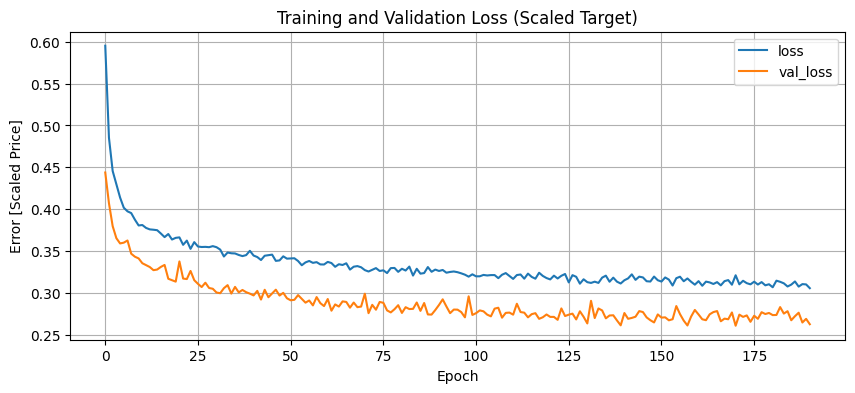


--- Evaluating Model on Test Set (Pre-2024 Data) ---
1044/1044 ━━━━━━━━━━━━━━━━━━━━ 0s 375us/step

Metrics on Original Price Scale (Test Set):
  MAE: 250,770.84
  MSE: 308,728,857,075.99
  RMSE: 555,633.74
  R-squared (R²): 0.7479


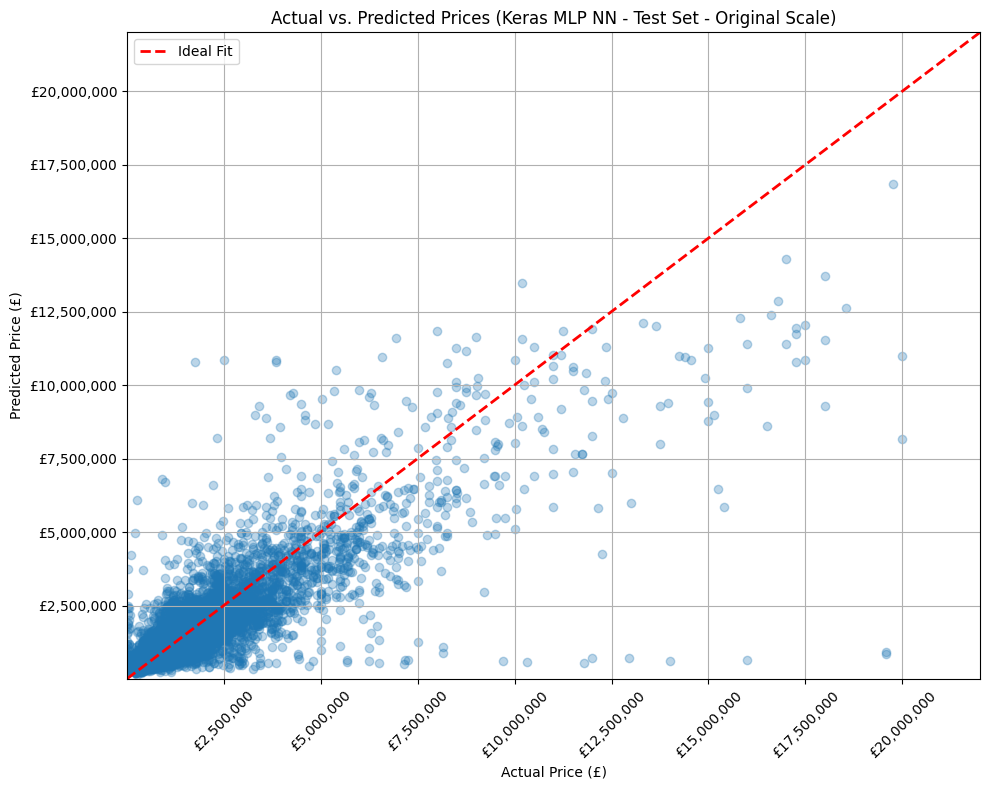


--- Preparing and Predicting on 2024 Data ---
Applied label encoding to 2024 data column: postcode
Applied label encoding to 2024 data column: property type
Applied label encoding to 2024 data column: old/new
Applied label encoding to 2024 data column: duration
Applied label encoding to 2024 data column: PAON
Applied label encoding to 2024 data column: street
Applied label encoding to 2024 data column: locality
Applied label encoding to 2024 data column: town/city
Applied label encoding to 2024 data column: district
Applied label encoding to 2024 data column: county
Applied label encoding to 2024 data column: PPD category type
Applied label encoding to 2024 data column: epc_property_type
Applied label encoding to 2024 data column: epc_energy_rating
Shape of 2024 features after align: (14342, 21)
Filling 14342 NaN values in 2024 features with 0.
Shape of 2024 features after scaling: (14342, 21)
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 362us/step
Added 'predicted_price' column (original scale) t

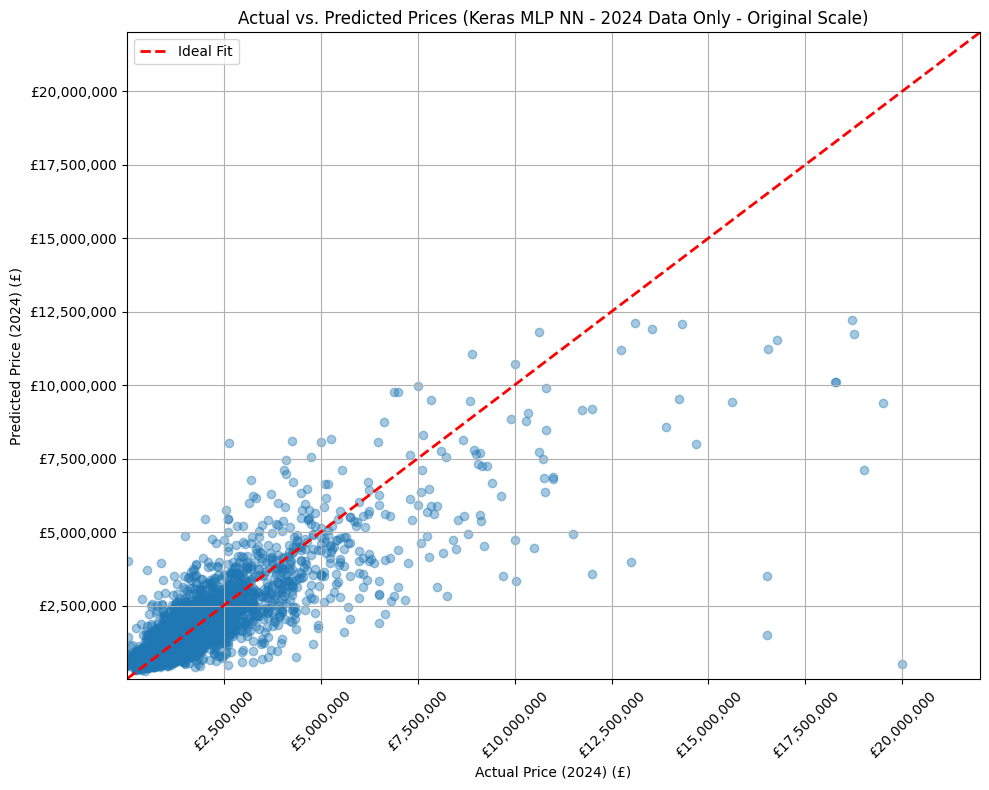


--- Sample Price Prediction (Keras MLP NN - Using Pre-2024 Sample) ---

Selected Sample (Index: 13181):
  Original Date of Transfer: 2015-09-18
  Original Actual Price: £2,625,000.00
  Address: BARROWGATE ROAD, LONDON, HOUNSLOW, GREATER LONDON, W4 4QU
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Prediction for Original Year (2015): £1,902,898.75
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Prediction for Year 2026: £2,565,599.50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Prediction for Year 2028: £3,036,787.50

Comparison:
  Actual (2015):      £2,625,000.00
  Predicted (2015): £1,902,898.75
  Predicted (2026):     £2,565,599.50
  Predicted (2028):     £3,036,787.50

--- Script Finished ---


In [ ]:
import numpy as np
import pandas as pd
from math import sqrt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler # Keep StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore") 


TARGET_YEAR_FOR_SEPARATION = 2024 # Define the year to separate
MODEL_NAME = "Keras MLP NN" # Define model name for titles/prints


df = pd.read_csv("london_merged_df_filtered_2015.csv")


df = df.drop(columns=['postcode_cleaned', 'ppd_address_key', 'epc_address_key',
       'lodgement_date','lmk_key','epc_built_form','epc_age_band'], errors='ignore')

# Basic Cleaning & Filtering ---
print("\n--- Initial Cleaning & Filtering ---")
initial_rows = len(df)

df = df.dropna(subset=["postcode","epc_floor_area","epc_habitable_rooms"])
print(f"Dropped {initial_rows - len(df)} rows with missing values in key columns (postcode, epc_floor_area, epc_habitable_rooms).")

initial_rows = len(df)
df = df.drop(columns=['record status - monthly file only', "Transaction unique identifier"], errors='ignore')
print("Dropped specified identifier columns.")

initial_rows = len(df)
# Ensure 'price' is numeric before filtering
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price']) # Drop rows where price couldn't be converted
df['price'] = df['price'].astype(float) # Ensure price is float for comparison
# Filter Outliers
df = df[(df["price"] >= 10_000) & (df["price"] <= 2_0000_000)]
print(f"Filtered {initial_rows - len(df)} rows with price outside £10k-£20M range or non-numeric price.")
print(f"DataFrame shape after initial cleaning/filtering: {df.shape}")

# Feature Engineering (Date) ---
print("\n--- Feature Engineering (Date) ---")
df["date of transfer"] = pd.to_datetime(df["date of transfer"], format="%Y-%m-%d", errors="coerce")
initial_rows = len(df)
df = df.dropna(subset=["date of transfer"]) # Drop rows where date couldn't be parsed
print(f"Dropped {initial_rows - len(df)} rows with invalid date format.")

# Extract meaningful date features
df['year']    = df['date of transfer'].dt.year
df["month"]   = df['date of transfer'].dt.month
df["day"]     = df['date of transfer'].dt.day
df["weekday"] = df['date of transfer'].dt.weekday
df["quarter"] = df['date of transfer'].dt.quarter
print("Extracted date features.")
print(f"Years present in data after cleaning: {sorted(df['year'].unique())}")

#  Separate Target Year Data --- # Changed target year back to constant
print(f"\n--- Separating {TARGET_YEAR_FOR_SEPARATION} Data ---")
# Check if the target year exists after sampling and cleaning
if TARGET_YEAR_FOR_SEPARATION in df['year'].unique():
    # Use df_target_year as the variable name for the separated data
    df_target_year = df[df['year'] == TARGET_YEAR_FOR_SEPARATION].copy()
    df = df[df['year'] != TARGET_YEAR_FOR_SEPARATION] # Remove target year data from the main dataframe (for training)
    print(f"Number of rows in training data (pre-{TARGET_YEAR_FOR_SEPARATION}): {len(df)}")
    print(f"Number of rows set aside for {TARGET_YEAR_FOR_SEPARATION} evaluation: {len(df_target_year)}")
else:
    print(f"Warning: Year {TARGET_YEAR_FOR_SEPARATION} not found in the sampled and cleaned data. Cannot separate.")
    df_target_year = pd.DataFrame() # Create an empty DataFrame

# Keep a copy for sample lookup (now only contains pre-target year data)
df_original_lookup = df.copy()

#  Prepare Data for Training (Pre-Target Year) ---
print(f"\n--- Preparing Training Data (Pre-{TARGET_YEAR_FOR_SEPARATION}) ---")
# Drop the original date column for the training dataframe
train_df = df.drop(columns=['date of transfer'])

# Identify categorical columns
categorical_cols = [col for col in train_df.columns if train_df[col].dtype == 'O']
print(f"Identified categorical columns: {categorical_cols}")


label_encoders = {} # Dictionary to store fitted encoders

for col in categorical_cols:
    # Handle NaNs before encoding: fill with a placeholder string
    train_df[col].fillna('Missing', inplace=True)
    # Ensure column is string type for LabelEncoder
    train_df[col] = train_df[col].astype(str)
    # Initialize and fit LabelEncoder
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    # Store the fitted encoder
    label_encoders[col] = le
    print(f"Label encoded column: {col}")

# Print shape after encoding (number of columns won't change with label encoding)
print(f"Shape after label encoding: {train_df.shape}")

# Fill NaNs in numerical columns (if any remain)
initial_nans = train_df.isna().sum().sum()
if initial_nans > 0:
    print(f"Filling {initial_nans} potential NaN values in numerical columns with 0.")
    train_df.fillna(0, inplace=True)

# Define Features (X) and Target (y) for training
X = train_df.drop(['price'], axis=1)
y = train_df['price']

# Get the number of features *after* preprocessing for the Input layer
n_features = X.shape[1]
print(f"Number of features after preprocessing: {n_features}")


if X.empty or y.empty:
    print("Error: Training data (X or y) is empty after preprocessing. Cannot proceed.")
    exit()

# Split into training and testing sets (using only pre-target year data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data shape (X_train): {X_train.shape}")
print(f"Testing data shape (X_test): {X_test.shape}")


print("\n--- Scaling Features and Target ---")
x_scaler = StandardScaler()
# Fit scaler ONLY on training data features
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)
print("Features scaled using StandardScaler.")


y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
# Transform y_test using the *same* scaler fitted on y_train
# y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1)) # Only needed if evaluating loss on scaled test data directly
print("Target variable (price) scaled using StandardScaler.")

# Define and Train the Keras Model ---
print(f"\n--- Defining and Training {MODEL_NAME} Model ---")
# Using the build function from the user's provided code (no changes needed here)
def build_and_compile_model(n_features):
  model = keras.Sequential([
      layers.Input(shape=(n_features,)),
      layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
      layers.Dropout(0.3),
      layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
      layers.Dropout(0.3),
      layers.Dense(1) # Output layer for regression
  ])

  model.compile(loss='mean_squared_error',
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
                metrics=['mae', 'mse']) # MAE and MSE on the SCALED target
  return model

nn_model = build_and_compile_model(n_features)
nn_model.summary()

# Define callbacks 
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor validation loss (on scaled target)
    patience=20,        # Stop after 20 epochs with no improvement
    restore_best_weights=True, # Restore weights from the best epoch
    verbose=1
)


print("\nStarting model training...")

if X_train_scaled.shape[0] == 0 or y_train_scaled.shape[0] == 0:
    print("Error: Training data is empty after scaling/splitting. Cannot train model.")
    exit()

history = nn_model.fit(
    X_train_scaled,
    y_train_scaled, # Use scaled target for training
    epochs=200,           # Number of training epochs
    batch_size=64,        # Batch size
    validation_split=0.2, # Use 20% of training data for validation
    verbose=1,            # Show progress per epoch
    callbacks=[early_stopping] # Apply early stopping
)
print("Model training complete.")




print(f"\n--- Evaluating Model on Test Set (Pre-{TARGET_YEAR_FOR_SEPARATION} Data) ---")
# Predict SCALED prices on SCALED test data
scaled_predictions_test = nn_model.predict(X_test_scaled)


predictions_test_original_scale = y_scaler.inverse_transform(scaled_predictions_test).flatten()


valid_indices_test = np.isfinite(predictions_test_original_scale) & np.isfinite(y_test.values)
if not np.all(valid_indices_test):
    print(f"Warning: Found {np.sum(~valid_indices_test)} non-finite values in test set final predictions or actuals. Removing them for evaluation.")
    predictions_eval_test = predictions_test_original_scale[valid_indices_test]
    y_test_eval = y_test.values[valid_indices_test]
else:
    predictions_eval_test = predictions_test_original_scale
    y_test_eval = y_test.values # Use original y_test values


if len(predictions_eval_test) > 0 and len(y_test_eval) > 0:
    mae_test = mean_absolute_error(y_test_eval, predictions_eval_test)
    mse_test = mean_squared_error(y_test_eval, predictions_eval_test)
    rmse_test = sqrt(max(0, mse_test)) # Prevent sqrt of potential tiny negative due to precision
    r2_test = r2_score(y_test_eval, predictions_eval_test)

    print("\nMetrics on Original Price Scale (Test Set):")
    print(f'  MAE: {mae_test:,.2f}')
    print(f'  MSE: {mse_test:,.2f}')
    print(f'  RMSE: {rmse_test:,.2f}')
    print(f"  R-squared (R²): {r2_test:.4f}")
else:
     print("Could not evaluate model on test set as no valid predictions or actual values were available after cleaning.")

# Plot Actual vs. Predicted (Test Set - Pre-Target Year Data) ---
if len(predictions_eval_test) > 0 and len(y_test_eval) > 0:
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_eval, predictions_eval_test, alpha=0.3)
    plt.xlabel("Actual Price (£)")
    plt.ylabel("Predicted Price (£)")
    plt.title(f"Actual vs. Predicted Prices ({MODEL_NAME} - Test Set - Original Scale)")
    min_price_val = min(y_test_eval.min(), predictions_eval_test.min()) * 0.9
    max_price_val = max(y_test_eval.max(), predictions_eval_test.max()) * 1.1
    if min_price_val >= max_price_val: max_price_val = min_price_val + 10000 # Prevent equal limits
    plt.plot([min_price_val, max_price_val], [min_price_val, max_price_val], 'r--', lw=2, label='Ideal Fit')
    plt.xlim(min_price_val, max_price_val)
    plt.ylim(min_price_val, max_price_val)
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping test set plot due to lack of valid data points.")

# Prepare and Predict on Target Year Data 
print(f"\n--- Preparing and Predicting on {TARGET_YEAR_FOR_SEPARATION} Data ---")
# Use df_target_year which was created in step 5
if not df_target_year.empty:
    try:
        # Store original prices for evaluation
        y_target_year_actual_original = df_target_year['price'].copy()

        # Prepare features for target year data
        # Drop price and date here
        df_target_year_processed = df_target_year.drop(columns=['date of transfer', 'price'])


        for col in categorical_cols:
             if col in df_target_year_processed.columns:
                 # Handle NaNs before encoding, using the same placeholder
                 df_target_year_processed[col].fillna('Missing', inplace=True)
                 # Ensure column is string type
                 df_target_year_processed[col] = df_target_year_processed[col].astype(str)
                 # Retrieve the stored encoder
                 if col in label_encoders:
                     le = label_encoders[col]
                     # Get known classes from the fitted encoder
                     known_classes = set(le.classes_)
                     # Handle potential new/unknown categories: map them to a specific value (e.g., -1)
                     df_target_year_processed[col] = df_target_year_processed[col].apply(
                         lambda x: le.transform([x])[0] if x in known_classes else -1 # Assign -1 to unknown
                     )
                     print(f"Applied label encoding to {TARGET_YEAR_FOR_SEPARATION} data column: {col}")
                 else:
                      print(f"Warning: Label encoder for column '{col}' not found. Filling with -1.")
                      df_target_year_processed[col] = -1 # Fill with placeholder if encoder missing
             else:
                 # This handles cases where a categorical column identified in training data is missing in target year data
                 print(f"Warning: Categorical column '{col}' not found in {TARGET_YEAR_FOR_SEPARATION} data during processing. It will be handled by reindex.")


        X_target_year = df_target_year_processed


        X_target_year = X_target_year.reindex(columns=X.columns, fill_value=0)
        print(f"Shape of {TARGET_YEAR_FOR_SEPARATION} features after align: {X_target_year.shape}")


        initial_nans_target_year = X_target_year.isna().sum().sum()
        if initial_nans_target_year > 0:
            print(f"Filling {initial_nans_target_year} NaN values in {TARGET_YEAR_FOR_SEPARATION} features with 0.")
            X_target_year.fillna(0, inplace=True)


        X_target_year_scaled = x_scaler.transform(X_target_year)
        print(f"Shape of {TARGET_YEAR_FOR_SEPARATION} features after scaling: {X_target_year_scaled.shape}")


        scaled_predictions_target_year = nn_model.predict(X_target_year_scaled)


        predictions_target_year_original_scale = y_scaler.inverse_transform(scaled_predictions_target_year).flatten()

  
        df_target_year['predicted_price'] = predictions_target_year_original_scale
        print(f"Added 'predicted_price' column (original scale) to the {TARGET_YEAR_FOR_SEPARATION} DataFrame.")


        print(f"\n--- Model Evaluation ({TARGET_YEAR_FOR_SEPARATION} Data Only - Original Scale) ---")
        # Ensure finite values for evaluation
        target_valid_indices = np.isfinite(predictions_target_year_original_scale) & np.isfinite(y_target_year_actual_original.values)
        if not np.all(target_valid_indices):
            print(f"Warning: Found {np.sum(~target_valid_indices)} non-finite values in {TARGET_YEAR_FOR_SEPARATION} final predictions or actuals. Removing them for evaluation.")
            target_predictions_eval = predictions_target_year_original_scale[target_valid_indices]
            target_y_eval = y_target_year_actual_original.values[target_valid_indices]
        else:
            target_predictions_eval = predictions_target_year_original_scale
            target_y_eval = y_target_year_actual_original.values

        if len(target_predictions_eval) > 0 and len(target_y_eval) > 0:
            mae_target_year = mean_absolute_error(target_y_eval, target_predictions_eval)
            mse_target_year = mean_squared_error(target_y_eval, target_predictions_eval)
            rmse_target_year = sqrt(max(0, mse_target_year))
            r2_target_year = r2_score(target_y_eval, target_predictions_eval)

            print(f'  MAE ({TARGET_YEAR_FOR_SEPARATION}): {mae_target_year:,.2f}')
            print(f'  MSE ({TARGET_YEAR_FOR_SEPARATION}): {mse_target_year:,.2f}')
            print(f'  RMSE ({TARGET_YEAR_FOR_SEPARATION}): {rmse_target_year:,.2f}')
            print(f"  R-squared (R²) ({TARGET_YEAR_FOR_SEPARATION}): {r2_target_year:.4f}")

   
            print(f"\n--- Comparison of Actual vs Predicted Prices (Year {TARGET_YEAR_FOR_SEPARATION}) ---")
            print(df_target_year[['price', 'predicted_price']].head())
            print(f"\nDescriptive Statistics for {TARGET_YEAR_FOR_SEPARATION} Prices:")
            # Format describe output
            print(df_target_year[['price', 'predicted_price']].describe().applymap(lambda x: f"{x:,.0f}"))

            # Plot Target Year Actual vs Predicted (Original Scale)
            plt.figure(figsize=(10, 8))
            plt.scatter(target_y_eval, target_predictions_eval, alpha=0.4)
            plt.xlabel(f"Actual Price ({TARGET_YEAR_FOR_SEPARATION}) (£)")
            plt.ylabel(f"Predicted Price ({TARGET_YEAR_FOR_SEPARATION}) (£)")
            plt.title(f"Actual vs. Predicted Prices ({MODEL_NAME} - {TARGET_YEAR_FOR_SEPARATION} Data Only - Original Scale)")
            min_price_tgt = min(target_y_eval.min(), target_predictions_eval.min()) * 0.9
            max_price_tgt = max(target_y_eval.max(), target_predictions_eval.max()) * 1.1
            if min_price_tgt >= max_price_tgt: max_price_tgt = min_price_tgt + 10000 # Prevent equal limits
            plt.plot([min_price_tgt, max_price_tgt], [min_price_tgt, max_price_tgt], 'r--', lw=2, label='Ideal Fit')
            plt.xlim(min_price_tgt, max_price_tgt)
            plt.ylim(min_price_tgt, max_price_tgt)
            plt.legend()
            plt.grid(True)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
        else:
             print(f"Could not evaluate {TARGET_YEAR_FOR_SEPARATION} model as no valid predictions or actual values were available after cleaning.")
    except Exception as e:
        print(f"An error occurred during {TARGET_YEAR_FOR_SEPARATION} prediction/evaluation: {e}")
        import traceback
        traceback.print_exc()

else:
    print(f"\n--- No Data Found for Year {TARGET_YEAR_FOR_SEPARATION} ---")
    print(f"Skipping prediction and evaluation for {TARGET_YEAR_FOR_SEPARATION}.")

# Sample Prediction Section 
print(f"\n--- Sample Price Prediction ({MODEL_NAME} - Using Pre-{TARGET_YEAR_FOR_SEPARATION} Sample) ---")
if not df_original_lookup.empty:
    try:
        # Select a random sample from the pre-target year lookup table
        sample_original_df = df_original_lookup.sample(1, random_state=42)

        if not sample_original_df.empty: # Check if sample is valid
            sample_index = sample_original_df.index[0]

            # Get original details
            original_date = sample_original_df['date of transfer'].iloc[0]
            original_year = sample_original_df['year'].iloc[0]
            original_price = sample_original_df['price'].iloc[0] # Actual price
            address_fields = ['paon', 'saon', 'street', 'locality', 'town/city', 'district', 'county', 'postcode']
            original_address = ", ".join(str(sample_original_df[col].iloc[0]) for col in address_fields if col in sample_original_df.columns and pd.notna(sample_original_df[col].iloc[0]))

            print(f"\nSelected Sample (Index: {sample_index}):")
            print(f"  Original Date of Transfer: {original_date.strftime('%Y-%m-%d')}")
            print(f"  Original Actual Price: £{original_price:,.2f}")
            print(f"  Address: {original_address}")

            # Get the corresponding processed row from train_df (which is label encoded)
            if sample_index in train_df.index:
                sample_processed_row = train_df.loc[[sample_index]]

                X_sample_unscaled = sample_processed_row.drop('price', axis=1)

                X_sample_unscaled = X_sample_unscaled.reindex(columns=X.columns, fill_value=0)

   
                X_sample_scaled = x_scaler.transform(X_sample_unscaled)

  
                scaled_prediction_original_year = nn_model.predict(X_sample_scaled) # Output is 2D

                prediction_original_year = y_scaler.inverse_transform(scaled_prediction_original_year)[0, 0]
                print(f"\nPrediction for Original Year ({original_year}): £{prediction_original_year:,.2f}")


                target_year_1 = 2026
                X_sample_future_1_unscaled = X_sample_unscaled.copy()
                if 'year' in X_sample_future_1_unscaled.columns:
                    X_sample_future_1_unscaled['year'] = target_year_1
                    X_sample_future_1_scaled = x_scaler.transform(X_sample_future_1_unscaled)
                    scaled_prediction_future_1 = nn_model.predict(X_sample_future_1_scaled)
                    prediction_future_1 = y_scaler.inverse_transform(scaled_prediction_future_1)[0, 0]
                    print(f"Prediction for Year {target_year_1}: £{prediction_future_1:,.2f}")
                else:
                    print(f"Warning: 'year' column not found in sample features. Cannot predict for {target_year_1}.")
                    prediction_future_1 = np.nan

  
                target_year_2 = 2028
                X_sample_future_2_unscaled = X_sample_unscaled.copy()
                if 'year' in X_sample_future_2_unscaled.columns:
                    X_sample_future_2_unscaled['year'] = target_year_2
                    X_sample_future_2_scaled = x_scaler.transform(X_sample_future_2_unscaled)
                    scaled_prediction_future_2 = nn_model.predict(X_sample_future_2_scaled)
                    prediction_future_2 = y_scaler.inverse_transform(scaled_prediction_future_2)[0, 0]
                    print(f"Prediction for Year {target_year_2}: £{prediction_future_2:,.2f}")
                else:
                    print(f"Warning: 'year' column not found in sample features. Cannot predict for {target_year_2}.")
                    prediction_future_2 = np.nan

                print("\nComparison:")
                print(f"  Actual ({original_year}):      £{original_price:,.2f}")
                print(f"  Predicted ({original_year}): £{prediction_original_year:,.2f}")
                if not np.isnan(prediction_future_1): print(f"  Predicted ({target_year_1}):     £{prediction_future_1:,.2f}")
                if not np.isnan(prediction_future_2): print(f"  Predicted ({target_year_2}):     £{prediction_future_2:,.2f}")

            else:
                print(f"Sample index {sample_index} not found in the processed training data (train_df). Skipping sample prediction.")
        else:
             print("Could not select a valid sample from the original lookup DataFrame. Skipping sample prediction.")
    except Exception as e:
        print(f"An error occurred during sample prediction: {e}")
        import traceback
        traceback.print_exc()

else:
    print(f"Original lookup DataFrame (pre-{TARGET_YEAR_FOR_SEPARATION}) is empty. Skipping sample prediction.")

print("\n--- Script Finished ---")

LSTM 2024

Successfully loaded data. Initial shape: (601221, 28)

--- Initial Cleaning & Filtering ---
Dropped 14166 rows with missing values in key columns (postcode, epc_floor_area, epc_habitable_rooms).
Dropped specified identifier columns.
Filtered 1164 rows with price outside [£10,000, £20,000,000].
DataFrame shape after initial cleaning/filtering: (585891, 19)

--- Feature Engineering (Date) ---
Dropped 0 rows with invalid date format.
Extracted date features.
Years present in data after cleaning: [np.int32(1995), np.int32(1996), np.int32(1997), np.int32(1998), np.int32(1999), np.int32(2000), np.int32(2001), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]

--- 

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,129 (94.25 KB)

 Trainable params: 24,129 (94.25 KB)

 Non-trainable params: 0 (0.00 B)


Starting model training...
Model training complete.

--- Evaluating Model on Test Set (Pre-2024 Data) ---
3573/3573 ━━━━━━━━━━━━━━━━━━━━ 2s 455us/step

Metrics on Original Price Scale (Test Set):
  MAE: 198,782.02
  MSE: 209,433,998,135.33
  RMSE: 457,639.59
  R-squared (R²): 0.6650


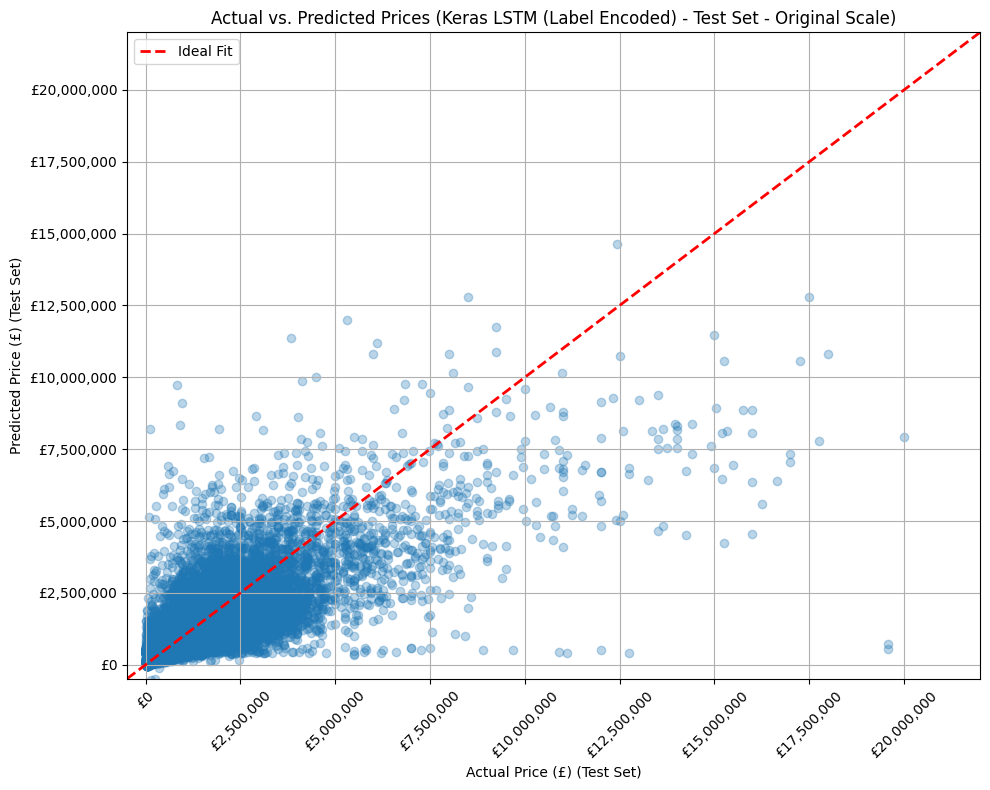


--- Preparing and Predicting on 2024 Data ---
Applying label encoding to 2024 data...
Shape of 2024 features after align: (14342, 21)
Filling 14342 NaN values in 2024 numerical features with 0.
Shape of 2024 features after scaling: (14342, 21)
Shape of 2024 features after reshaping: (14342, 1, 21)

--- Predicting Prices for 2024 Data ---
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 472us/step
Added 'predicted_price' column (original scale) to the 2024 DataFrame.

--- Model Evaluation (2024 Data Only - Original Scale) ---
  MAE (2024): 345,916.53
  MSE (2024): 442,410,988,334.98
  RMSE (2024): 665,139.83
  R-squared (R²) (2024): 0.6383

--- Comparison of Actual vs Predicted Prices (Year 2024) ---
            price  predicted_price
586068   367500.0       607874.625
586069   987000.0       951818.500
586070  1080600.0      1283888.500
586071  2098000.0      2092838.000
586072  1580000.0      1845800.625

Descriptive Statistics for 2024 Prices:
           price  predicted_price
count     14,342      

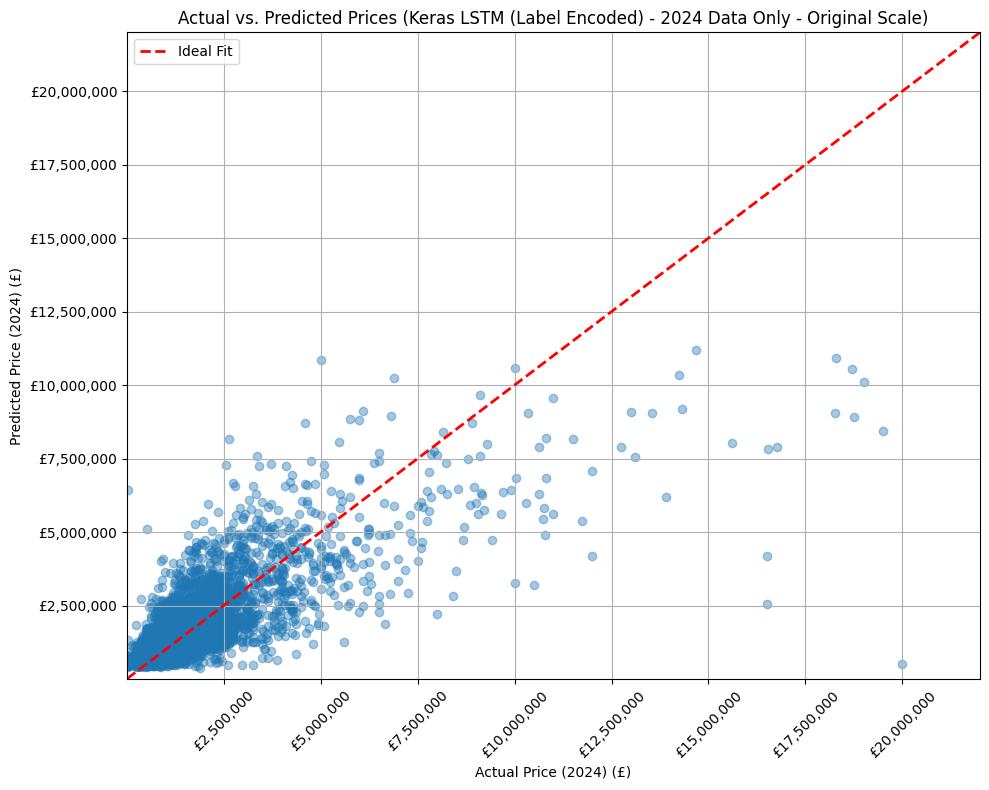


--- Predicting Price for a Sample Property at Different Years (Keras LSTM (Label Encoded)) ---

Selected Sample (Index: 401656):
  Original Date: 2014-04-29
  Original Price: £900,000.00
  Address: SHIREHALL PARK, LONDON, BARNET, GREATER LONDON, NW4 2QU
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Prediction for Original Year (2014): £1,162,876.62
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Prediction for Year 2026: £1,680,131.50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Prediction for Year 2028: £1,760,119.25

Comparison:
  Actual (2014):      £900,000.00
  Predicted (2014): £1,162,876.62
  Predicted (2026):     £1,680,131.50
  Predicted (2028):     £1,760,119.25

NOTE: Future year predictions are extrapolations beyond the training data range.
------------------------------------------------------------

--- Script Finished ---


In [ ]:
import numpy as np
import pandas as pd
from math import sqrt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from matplotlib.ticker import FuncFormatter # Import for formatting axis


TARGET_YEAR_FOR_SEPARATION = 2024 # Define the year to separate
MODEL_NAME = "Keras LSTM (Label Encoded)" # Updated model name
PLACEHOLDER_VALUE = 'Missing' # Define placeholder for missing categorical values
UNKNOWN_CATEGORY_VALUE = -1 # Define value for unknown categories during encoding


df = pd.read_csv("london_merged_df_filtered.csv")
df = df.drop(columns=['postcode_cleaned', 'ppd_address_key', 'epc_address_key',
       'lodgement_date','lmk_key','epc_built_form','epc_age_band'], errors='ignore')

# Basic Cleaning & Filtering ---
print("\n--- Initial Cleaning & Filtering ---")
initial_rows = len(df)

df = df.dropna(subset=["postcode","epc_floor_area","epc_habitable_rooms"])
print(f"Dropped {initial_rows - len(df)} rows with missing values in key columns (postcode, epc_floor_area, epc_habitable_rooms).")

initial_rows = len(df)
df = df.drop(columns=['record status - monthly file only', "Transaction unique identifier"], errors='ignore')
print("Dropped specified identifier columns.")

initial_rows = len(df)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])
df['price'] = df['price'].astype(float)
price_min = 10_000
price_max = 20_000_000
df = df[(df["price"] >= price_min) & (df["price"] <= price_max)]
print(f"Filtered {initial_rows - len(df)} rows with price outside [£{price_min:,}, £{price_max:,}].")
print(f"DataFrame shape after initial cleaning/filtering: {df.shape}")


df["date of transfer"] = pd.to_datetime(df["date of transfer"], format="%Y-%m-%d", errors="coerce")
initial_rows = len(df)
df = df.dropna(subset=["date of transfer"])
print(f"Dropped {initial_rows - len(df)} rows with invalid date format.")
if df.empty:
    print("Error: No valid data remaining after date processing.")
    exit()

df['year']    = df['date of transfer'].dt.year
df["month"]   = df['date of transfer'].dt.month
df["day"]     = df['date of transfer'].dt.day
df["weekday"] = df['date of transfer'].dt.weekday
df["quarter"] = df['date of transfer'].dt.quarter
print("Extracted date features.")
print(f"Years present in data after cleaning: {sorted(df['year'].unique())}")

# Separate Target Year Data ---
print(f"\n--- Separating {TARGET_YEAR_FOR_SEPARATION} Data ---")
if TARGET_YEAR_FOR_SEPARATION in df['year'].unique():
    # Using df_2024 
    df_2024 = df[df['year'] == TARGET_YEAR_FOR_SEPARATION].copy()
    # Remove target year data from the main dataframe for training
    df = df[df['year'] != TARGET_YEAR_FOR_SEPARATION]
    print(f"Number of rows in training data (pre-{TARGET_YEAR_FOR_SEPARATION}): {len(df)}")
    print(f"Number of rows set aside for {TARGET_YEAR_FOR_SEPARATION} evaluation: {len(df_2024)}")
else:
    print(f"Warning: Year {TARGET_YEAR_FOR_SEPARATION} not found. Cannot separate.")
    df_2024 = pd.DataFrame() # Create empty df if year not found

df_original_lookup = df.copy()

# Prepare Data for Training (Pre-Target Year) ---
print(f"\n--- Preparing Training Data (Pre-{TARGET_YEAR_FOR_SEPARATION}) ---")
# Use the modified 'df' which excludes the target year
train_df = df.drop(columns=['date of transfer'])


categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
print(f"Identified categorical columns: {list(categorical_cols)}")


label_encoders = {} # Dictionary to store fitted encoders
print(f"Label encoding columns: {list(categorical_cols)}")
for col in categorical_cols:
    train_df[col] = train_df[col].astype(str).fillna(PLACEHOLDER_VALUE) # Ensure string and fill NaNs
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    label_encoders[col] = le # Store fitted encoder
print(f"Shape after label encoding: {train_df.shape}") # Should have same number of columns


train_df.fillna(0, inplace=True) # Fill any remaining NaNs (e.g., in numerical cols)

# Data Splitting (Renumbered logically) ---
X = train_df.drop(['price'], axis=1)
y = train_df['price']

if 'price' in X.columns:
     raise ValueError("Column 'price' should not be in features X")
if X.empty:
    print("Error: Feature set X is empty after processing.")
    exit()


feature_order = list(X.columns)
print(f"Number of features after label encoding: {len(feature_order)}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train) # Fit only on X_train
X_test_scaled = x_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)) 

n_features = X_train_scaled.shape[1] # Number of features remains the same


X_train_reshaped = X_train_scaled.reshape((X_train_scaled.shape[0], 1, n_features))
X_test_reshaped = X_test_scaled.reshape((X_test_scaled.shape[0], 1, n_features))
print(f"Training data shape (Reshaped for LSTM): {X_train_reshaped.shape}")


def build_and_compile_lstm_model_v3(input_shape):
  model = keras.Sequential([
      layers.Input(shape=input_shape),
      layers.LSTM(64, activation='tanh', recurrent_activation='sigmoid',
                  kernel_regularizer=regularizers.l2(0.01),
                  recurrent_regularizer=regularizers.l2(0.01)
                 ),
      layers.Dropout(0.4),
      layers.Dense(32, activation='relu',
                   kernel_regularizer=regularizers.l2(0.01)),
      layers.Dropout(0.4),
      layers.Dense(1)
  ])
  model.compile(loss='mean_squared_error',
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),
                metrics=['mae', 'mse'])
  return model

lstm_input_shape = (X_train_reshaped.shape[1], X_train_reshaped.shape[2])
lstm_model = build_and_compile_lstm_model_v3(lstm_input_shape)
lstm_model.summary()

early_stopping = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)


history = lstm_model.fit(
    X_train_reshaped,
    y_train_scaled,
    epochs=200,
    batch_size=64,
    validation_split=0.2,
    verbose=0, # Set to 1 to see epoch progress
    callbacks=[early_stopping]
)


# Evaluate Model on Test Set (Pre-2024 Data) ---
# Evaluation logic remains the same
print(f"\n--- Evaluating Model on Test Set (Pre-{TARGET_YEAR_FOR_SEPARATION} Data) ---")
scaled_predictions_test = lstm_model.predict(X_test_reshaped)
predictions_test = y_scaler.inverse_transform(scaled_predictions_test).flatten()

# Ensure finite values
valid_indices_test = np.isfinite(predictions_test) & np.isfinite(y_test.values)
if not np.all(valid_indices_test):
    print(f"Warning: Found {np.sum(~valid_indices_test)} non-finite values in test set predictions/actuals. Removing them for evaluation.")
    predictions_eval_test = predictions_test[valid_indices_test]
    y_test_eval = y_test.values[valid_indices_test]
else:
    predictions_eval_test = predictions_test
    y_test_eval = y_test.values

if len(predictions_eval_test) > 0 and len(y_test_eval) > 0:
    mae_test = mean_absolute_error(y_test_eval, predictions_eval_test)
    mse_test = mean_squared_error(y_test_eval, predictions_eval_test)
    rmse_test = sqrt(max(0, mse_test))
    r2_test = r2_score(y_test_eval, predictions_eval_test)
    print("\nMetrics on Original Price Scale (Test Set):")
    print(f'  MAE: {mae_test:,.2f}')
    print(f'  MSE: {mse_test:,.2f}')
    print(f'  RMSE: {rmse_test:,.2f}')
    print(f"  R-squared (R²): {r2_test:.4f}")
else:
     print("Could not evaluate model on test set due to lack of valid data.")


if len(predictions_eval_test) > 0 and len(y_test_eval) > 0:
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_eval, predictions_eval_test, alpha=0.3)
    plt.xlabel("Actual Price (£) (Test Set)")
    plt.ylabel("Predicted Price (£) (Test Set)")
    plt.title(f"Actual vs. Predicted Prices ({MODEL_NAME} - Test Set - Original Scale)")
    min_price_val = min(y_test_eval.min(), predictions_eval_test.min()) * 0.9
    max_price_val = max(y_test_eval.max(), predictions_eval_test.max()) * 1.1
    if min_price_val >= max_price_val: max_price_val = min_price_val + 10000
    plt.plot([min_price_val, max_price_val], [min_price_val, max_price_val], 'r--', lw=2, label='Ideal Fit')
    plt.xlim(min_price_val, max_price_val)
    plt.ylim(min_price_val, max_price_val)
    plt.legend()
    plt.grid(True)
    formatter = FuncFormatter(lambda x, p: f'£{x:,.0f}')
    plt.gca().xaxis.set_major_formatter(formatter)
    plt.gca().yaxis.set_major_formatter(formatter)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping test set plot due to lack of valid data.")


print(f"\n--- Preparing and Predicting on {TARGET_YEAR_FOR_SEPARATION} Data ---")
if not df_2024.empty:
    try:
        # Store original prices for evaluation
        y_2024_actual_original = df_2024['price'].copy()

        # Prepare features for 2024 data
        df_2024_processed = df_2024.drop(columns=['date of transfer', 'price'])

        # Apply Label Encoders to 2024 data**
        print(f"Applying label encoding to {TARGET_YEAR_FOR_SEPARATION} data...")
        for col in categorical_cols:
             if col in df_2024_processed.columns:
                 df_2024_processed[col] = df_2024_processed[col].astype(str).fillna(PLACEHOLDER_VALUE)
                 if col in label_encoders:
                     le = label_encoders[col]
                     known_classes = set(le.classes_)
                     # Apply transform, replacing unknowns with UNKNOWN_CATEGORY_VALUE
                     df_2024_processed[col] = df_2024_processed[col].apply(
                         lambda x: le.transform([x])[0] if x in known_classes else UNKNOWN_CATEGORY_VALUE
                     )
                 else:
                      print(f"Warning: Label encoder for column '{col}' not found. Filling with {UNKNOWN_CATEGORY_VALUE}.")
                      df_2024_processed[col] = UNKNOWN_CATEGORY_VALUE
             else:
                 print(f"Warning: Categorical column '{col}' not found in {TARGET_YEAR_FOR_SEPARATION} data. It will be handled by reindex.")

      
        X_2024 = df_2024_processed

        X_2024 = X_2024.reindex(columns=feature_order, fill_value=0)
        print(f"Shape of {TARGET_YEAR_FOR_SEPARATION} features after align: {X_2024.shape}")

 
        initial_nans_2024 = X_2024.isna().sum().sum()
        if initial_nans_2024 > 0:
            print(f"Filling {initial_nans_2024} NaN values in {TARGET_YEAR_FOR_SEPARATION} numerical features with 0.")
            X_2024.fillna(0, inplace=True)

        X_2024_scaled = x_scaler.transform(X_2024)
        print(f"Shape of {TARGET_YEAR_FOR_SEPARATION} features after scaling: {X_2024_scaled.shape}")


        X_2024_reshaped = X_2024_scaled.reshape((X_2024_scaled.shape[0], 1, n_features))
        print(f"Shape of {TARGET_YEAR_FOR_SEPARATION} features after reshaping: {X_2024_reshaped.shape}")



        scaled_predictions_2024 = lstm_model.predict(X_2024_reshaped)


        predictions_2024_original_scale = y_scaler.inverse_transform(scaled_predictions_2024).flatten()


        df_2024['predicted_price'] = predictions_2024_original_scale
        print(f"Added 'predicted_price' column (original scale) to the {TARGET_YEAR_FOR_SEPARATION} DataFrame.")


        print(f"\n--- Model Evaluation ({TARGET_YEAR_FOR_SEPARATION} Data Only - Original Scale) ---")

        target_valid_indices = np.isfinite(predictions_2024_original_scale) & np.isfinite(y_2024_actual_original.values)
        if not np.all(target_valid_indices):
            print(f"Warning: Found {np.sum(~target_valid_indices)} non-finite values in {TARGET_YEAR_FOR_SEPARATION} final predictions or actuals. Removing them for evaluation.")
            target_predictions_eval = predictions_2024_original_scale[target_valid_indices]
            target_y_eval = y_2024_actual_original.values[target_valid_indices]
        else:
            target_predictions_eval = predictions_2024_original_scale
            target_y_eval = y_2024_actual_original.values

        if len(target_predictions_eval) > 0 and len(target_y_eval) > 0:
            mae_target_year = mean_absolute_error(target_y_eval, target_predictions_eval)
            mse_target_year = mean_squared_error(target_y_eval, target_predictions_eval)
            rmse_target_year = sqrt(max(0, mse_target_year))
            r2_target_year = r2_score(target_y_eval, target_predictions_eval)

            print(f'  MAE ({TARGET_YEAR_FOR_SEPARATION}): {mae_target_year:,.2f}')
            print(f'  MSE ({TARGET_YEAR_FOR_SEPARATION}): {mse_target_year:,.2f}')
            print(f'  RMSE ({TARGET_YEAR_FOR_SEPARATION}): {rmse_target_year:,.2f}')
            print(f"  R-squared (R²) ({TARGET_YEAR_FOR_SEPARATION}): {r2_target_year:.4f}")
        else:
             print(f"Could not evaluate {TARGET_YEAR_FOR_SEPARATION} model as no valid predictions or actual values were available after cleaning.")


        print(f"\n--- Comparison of Actual vs Predicted Prices (Year {TARGET_YEAR_FOR_SEPARATION}) ---")

        print(df_2024[['price', 'predicted_price']].head())

 
        with pd.option_context('display.float_format', '{:,.0f}'.format): # Format output neatly
            print(df_2024[['price', 'predicted_price']].describe())


        if len(target_predictions_eval) > 0 and len(target_y_eval) > 0:
            plt.figure(figsize=(10, 8))
            plt.scatter(target_y_eval, target_predictions_eval, alpha=0.4)
            plt.xlabel(f"Actual Price ({TARGET_YEAR_FOR_SEPARATION}) (£)")
            plt.ylabel(f"Predicted Price ({TARGET_YEAR_FOR_SEPARATION}) (£)")
            plt.title(f"Actual vs. Predicted Prices ({MODEL_NAME} - {TARGET_YEAR_FOR_SEPARATION} Data Only - Original Scale)")
            min_price_tgt = min(target_y_eval.min(), target_predictions_eval.min()) * 0.9
            max_price_tgt = max(target_y_eval.max(), target_predictions_eval.max()) * 1.1
            if min_price_tgt >= max_price_tgt: max_price_tgt = min_price_tgt + 10000
            plt.plot([min_price_tgt, max_price_tgt], [min_price_tgt, max_price_tgt], 'r--', lw=2, label='Ideal Fit')
            plt.xlim(min_price_tgt, max_price_tgt)
            plt.ylim(min_price_tgt, max_price_tgt)
            plt.legend()
            plt.grid(True)
            formatter = FuncFormatter(lambda x, p: f'£{x:,.0f}')
            plt.gca().xaxis.set_major_formatter(formatter)
            plt.gca().yaxis.set_major_formatter(formatter)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
        else:
             print(f"Skipping {TARGET_YEAR_FOR_SEPARATION} plot due to lack of valid data.")

    except Exception as e:
        print(f"An error occurred during {TARGET_YEAR_FOR_SEPARATION} prediction/evaluation: {e}")
        import traceback
        traceback.print_exc()

else:
    print(f"\n--- No Data Found for Year {TARGET_YEAR_FOR_SEPARATION} ---")
    print(f"Skipping prediction and evaluation for {TARGET_YEAR_FOR_SEPARATION}.")


print(f"\n--- Predicting Price for a Sample Property at Different Years ({MODEL_NAME}) ---")
if not df_original_lookup.empty:
    try:
        sample_original_df = df_original_lookup.sample(1, random_state=42)

        if not sample_original_df.empty: # Check sample validity
            sample_index = sample_original_df.index[0]

            original_date_dt = sample_original_df['date of transfer'].iloc[0]
            original_year_val = sample_original_df['year'].iloc[0]
            original_price_val = sample_original_df['price'].iloc[0]
            address_fields = ['paon', 'saon', 'street', 'locality', 'town/city', 'district', 'county', 'postcode']
            original_address = ", ".join(sample_original_df[col].astype(str).iloc[0] for col in address_fields if col in sample_original_df.columns and pd.notna(sample_original_df[col].iloc[0]))

            print(f"\nSelected Sample (Index: {sample_index}):")
            print(f"  Original Date: {original_date_dt.strftime('%Y-%m-%d')}")
            print(f"  Original Price: £{original_price_val:,.2f}")
            print(f"  Address: {original_address}")


            def prepare_sample_lstm(sample_df, target_year=None):
                """Prepares a single sample row for LSTM prediction using label encoding."""
                sample = sample_df.copy()
                original_sample_date = sample['date of transfer'].iloc[0]

                # Update date features if target_year is specified
                if target_year is not None:
                    sample['year']    = target_year
                    try:
                        target_date = pd.Timestamp(year=target_year, month=original_sample_date.month, day=original_sample_date.day)
                    except ValueError: # Handle invalid dates like Feb 29
                        target_date = pd.Timestamp(year=target_year, month=original_sample_date.month, day=max(1, original_sample_date.day-1))
                        print(f" Adjusted date for {target_year} due to potential invalid day.")
                    sample["month"]   = target_date.month
                    sample["day"]     = target_date.day
                    sample["weekday"] = target_date.weekday
                    sample["quarter"] = target_date.quarter

                sample = sample.drop(columns=['date of transfer'], errors='ignore')

                # Apply Label Encoding using stored encoders
                for col in categorical_cols:
                     if col in sample.columns:
                         sample[col] = sample[col].astype(str).fillna(PLACEHOLDER_VALUE)
                         if col in label_encoders:
                             le = label_encoders[col]
                             known_classes = set(le.classes_)
                             # Use apply on the single row (iloc[0])
                             sample[col] = sample[col].apply(lambda x: le.transform([x])[0] if x in known_classes else UNKNOWN_CATEGORY_VALUE)
                         else:
                             sample[col] = UNKNOWN_CATEGORY_VALUE
                     # If col not in sample, reindex will handle it


                sample_reordered = sample.reindex(columns=feature_order, fill_value=0) # Use saved feature_order
                sample_features = sample_reordered.drop(columns=['price'], errors='ignore')

                sample_features = sample_features.apply(pd.to_numeric, errors='coerce').fillna(0)


                sample_scaled = x_scaler.transform(sample_features)
                sample_reshaped = sample_scaled.reshape((1, 1, sample_scaled.shape[1])) # Reshape to (1, 1, n_features)
                return sample_reshaped

            X_sample_orig_reshaped = prepare_sample_lstm(sample_original_df)
            scaled_prediction_original_year = lstm_model.predict(X_sample_orig_reshaped)
            prediction_original_year = y_scaler.inverse_transform(scaled_prediction_original_year)[0, 0]
            print(f"\nPrediction for Original Year ({original_year_val}): £{prediction_original_year:,.2f}")

            target_year_1 = 2026
            X_sample_future_1_reshaped = prepare_sample_lstm(sample_original_df, target_year=target_year_1)
            scaled_prediction_future_1 = lstm_model.predict(X_sample_future_1_reshaped)
            prediction_future_1 = y_scaler.inverse_transform(scaled_prediction_future_1)[0, 0]
            print(f"Prediction for Year {target_year_1}: £{prediction_future_1:,.2f}")

            target_year_2 = 2028
            X_sample_future_2_reshaped = prepare_sample_lstm(sample_original_df, target_year=target_year_2)
            scaled_prediction_future_2 = lstm_model.predict(X_sample_future_2_reshaped)
            prediction_future_2 = y_scaler.inverse_transform(scaled_prediction_future_2)[0, 0]
            print(f"Prediction for Year {target_year_2}: £{prediction_future_2:,.2f}")

            print("\nComparison:")
            print(f"  Actual ({original_year_val}):      £{original_price_val:,.2f}")
            print(f"  Predicted ({original_year_val}): £{prediction_original_year:,.2f}")
            print(f"  Predicted ({target_year_1}):     £{prediction_future_1:,.2f}")
            print(f"  Predicted ({target_year_2}):     £{prediction_future_2:,.2f}")

            max_train_year = df_original_lookup['year'].max()
            if max(target_year_1, target_year_2) > max_train_year:
                 print("\nNOTE: Future year predictions are extrapolations beyond the training data range.")
        else:
             print("Could not select a valid sample from the original lookup DataFrame.")

    except Exception as e:
        print(f"\nError during sample prediction: {e}")
        import traceback
        traceback.print_exc()
        print("Sample prediction skipped.")

else:
    print("\nCould not select a sample as the original DataFrame is empty after initial filtering.")

print("-" * 60)
print("\n--- Script Finished ---")

LSTM 2024 10y

2025-04-25 12:58:14.760286: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-25 12:58:14.763516: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-25 12:58:14.771615: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745582294.784436  436406 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745582294.788197  436406 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745582294.798575  436406 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

Successfully loaded data. Initial shape: (191678, 28)

--- Initial Cleaning & Filtering ---
Dropped 9538 rows with missing values in key columns (postcode, epc_floor_area, epc_habitable_rooms).
Dropped specified identifier columns.
Filtered 765 rows with price outside [£10,000, £20,000,000].
DataFrame shape after initial cleaning/filtering: (181375, 19)

--- Feature Engineering (Date) ---
Dropped 0 rows with invalid date format.
Extracted date features.
Years present in data after cleaning: [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]

--- Separating 2024 Data ---
Number of rows in training data (pre-2024): 167033
Number of rows set aside for 2024 evaluation: 14342

--- Preparing Training Data (Pre-2024) ---
Identified categorical columns: ['postcode', 'property type', 'old/new', 'duration', 'PAON', 'street', 'locality', 'town/city', 'district', 'county', 

2025-04-25 12:58:17.465732: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,129 (94.25 KB)

 Trainable params: 24,129 (94.25 KB)

 Non-trainable params: 0 (0.00 B)


Starting model training...
Model training complete.

--- Evaluating Model on Test Set (Pre-2024 Data) ---
1044/1044 ━━━━━━━━━━━━━━━━━━━━ 1s 521us/step

Metrics on Original Price Scale (Test Set):
  MAE: 315,981.97
  MSE: 455,857,548,072.38
  RMSE: 675,172.24
  R-squared (R²): 0.6278


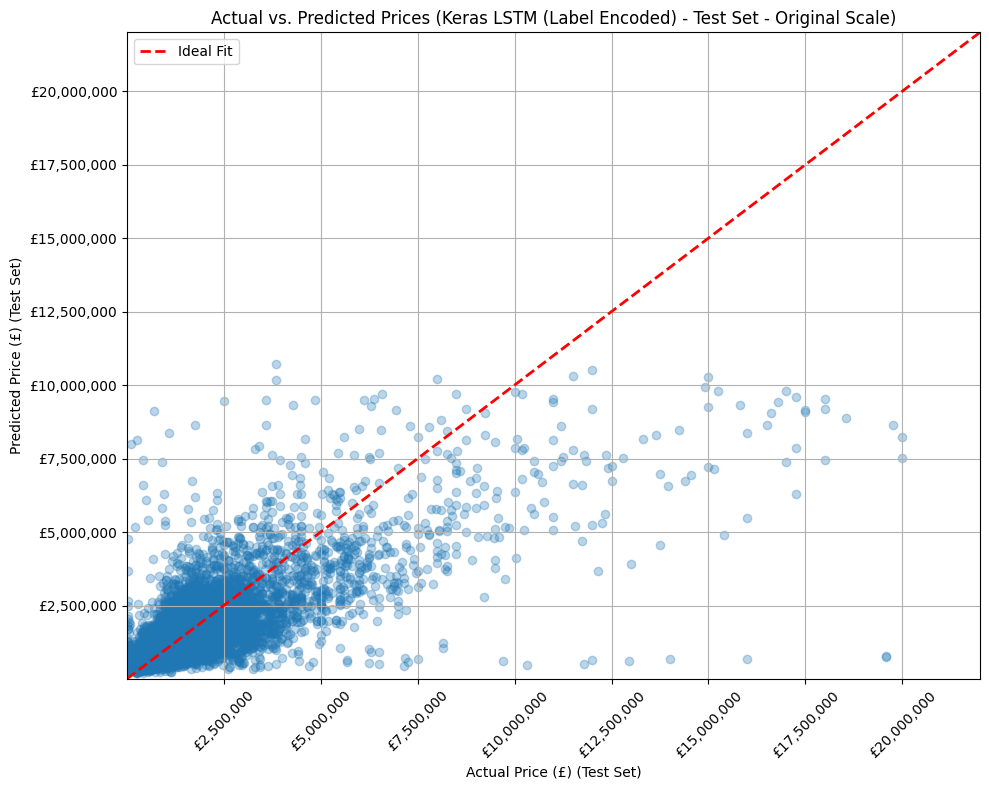


--- Preparing and Predicting on 2024 Data ---
Applying label encoding to 2024 data...
Shape of 2024 features after align: (14342, 21)
Filling 14342 NaN values in 2024 numerical features with 0.
Shape of 2024 features after scaling: (14342, 21)
Shape of 2024 features after reshaping: (14342, 1, 21)

--- Predicting Prices for 2024 Data ---
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 434us/step
Added 'predicted_price' column (original scale) to the 2024 DataFrame.

--- Model Evaluation (2024 Data Only - Original Scale) ---
  MAE (2024): 319,211.07
  MSE (2024): 435,356,906,471.79
  RMSE (2024): 659,815.81
  R-squared (R²) (2024): 0.6441

--- Comparison of Actual vs Predicted Prices (Year 2024) ---
            price  predicted_price
176525   367500.0     6.058728e+05
176526   987000.0     8.721032e+05
176527  1080600.0     1.152494e+06
176528  2098000.0     1.911773e+06
176529  1580000.0     1.748549e+06

Descriptive Statistics for 2024 Prices:
           price  predicted_price
count     14,342      

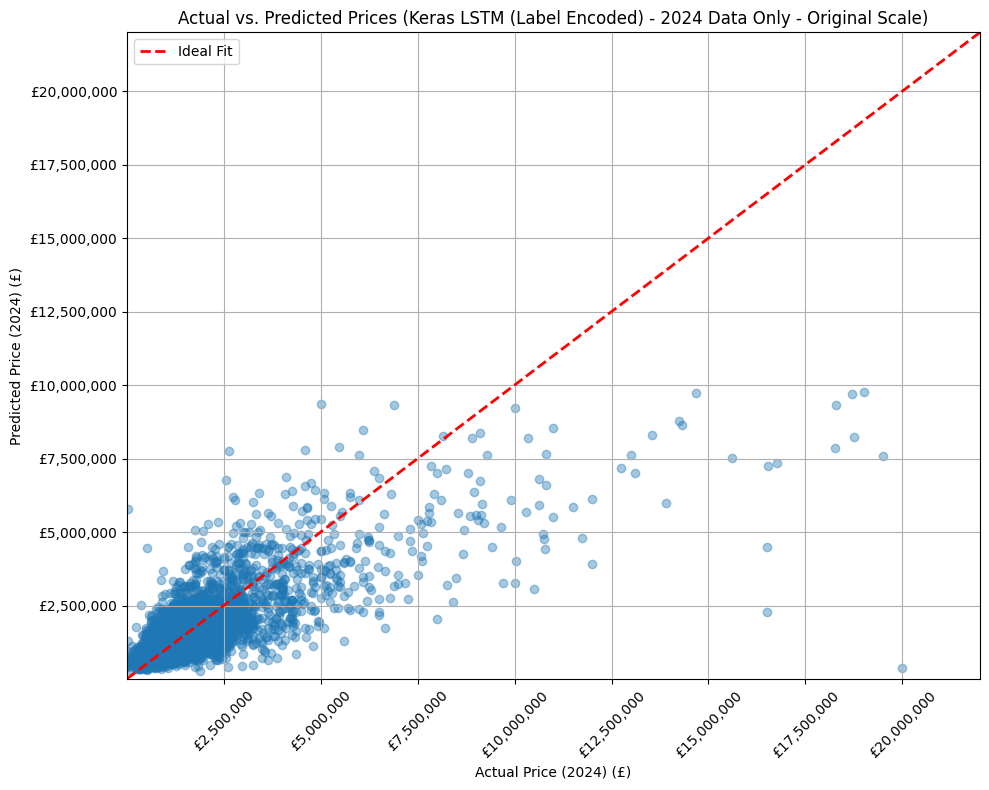


--- Predicting Price for a Sample Property at Different Years (Keras LSTM (Label Encoded)) ---

Selected Sample (Index: 13181):
  Original Date: 2015-09-18
  Original Price: £2,625,000.00
  Address: BARROWGATE ROAD, LONDON, HOUNSLOW, GREATER LONDON, W4 4QU
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

Prediction for Original Year (2015): £1,724,635.62
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Prediction for Year 2026: £2,577,404.00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Prediction for Year 2028: £2,767,838.75

Comparison:
  Actual (2015):      £2,625,000.00
  Predicted (2015): £1,724,635.62
  Predicted (2026):     £2,577,404.00
  Predicted (2028):     £2,767,838.75

NOTE: Future year predictions are extrapolations beyond the training data range.
------------------------------------------------------------

--- Script Finished ---


In [ ]:
import numpy as np
import pandas as pd
from math import sqrt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from matplotlib.ticker import FuncFormatter # Import for formatting axis


TARGET_YEAR_FOR_SEPARATION = 2024 # Define the year to separate
MODEL_NAME = "Keras LSTM (Label Encoded)" # Updated model name
PLACEHOLDER_VALUE = 'Missing' # Define placeholder for missing categorical values
UNKNOWN_CATEGORY_VALUE = -1 # Define value for unknown categories during encoding


df = pd.read_csv("london_merged_df_filtered_2015.csv")
df = df.drop(columns=['postcode_cleaned', 'ppd_address_key', 'epc_address_key',
       'lodgement_date','lmk_key','epc_built_form','epc_age_band'], errors='ignore')

# Basic Cleaning & Filtering ---
print("\n--- Initial Cleaning & Filtering ---")
initial_rows = len(df)

df = df.dropna(subset=["postcode","epc_floor_area","epc_habitable_rooms"])
print(f"Dropped {initial_rows - len(df)} rows with missing values in key columns (postcode, epc_floor_area, epc_habitable_rooms).")

initial_rows = len(df)
df = df.drop(columns=['record status - monthly file only', "Transaction unique identifier"], errors='ignore')
print("Dropped specified identifier columns.")

initial_rows = len(df)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])
df['price'] = df['price'].astype(float)
price_min = 10_000
price_max = 20_000_000
df = df[(df["price"] >= price_min) & (df["price"] <= price_max)]
print(f"Filtered {initial_rows - len(df)} rows with price outside [£{price_min:,}, £{price_max:,}].")
print(f"DataFrame shape after initial cleaning/filtering: {df.shape}")


df["date of transfer"] = pd.to_datetime(df["date of transfer"], format="%Y-%m-%d", errors="coerce")
initial_rows = len(df)
df = df.dropna(subset=["date of transfer"])
print(f"Dropped {initial_rows - len(df)} rows with invalid date format.")
if df.empty:
    print("Error: No valid data remaining after date processing.")
    exit()

df['year']    = df['date of transfer'].dt.year
df["month"]   = df['date of transfer'].dt.month
df["day"]     = df['date of transfer'].dt.day
df["weekday"] = df['date of transfer'].dt.weekday
df["quarter"] = df['date of transfer'].dt.quarter
print("Extracted date features.")
print(f"Years present in data after cleaning: {sorted(df['year'].unique())}")

# Separate Target Year Data ---
print(f"\n--- Separating {TARGET_YEAR_FOR_SEPARATION} Data ---")
if TARGET_YEAR_FOR_SEPARATION in df['year'].unique():
    # Using df_2024 
    df_2024 = df[df['year'] == TARGET_YEAR_FOR_SEPARATION].copy()
    # Remove target year data from the main dataframe for training
    df = df[df['year'] != TARGET_YEAR_FOR_SEPARATION]
    print(f"Number of rows in training data (pre-{TARGET_YEAR_FOR_SEPARATION}): {len(df)}")
    print(f"Number of rows set aside for {TARGET_YEAR_FOR_SEPARATION} evaluation: {len(df_2024)}")
else:
    print(f"Warning: Year {TARGET_YEAR_FOR_SEPARATION} not found. Cannot separate.")
    df_2024 = pd.DataFrame() # Create empty df if year not found

df_original_lookup = df.copy()

# Prepare Data for Training (Pre-Target Year) ---
print(f"\n--- Preparing Training Data (Pre-{TARGET_YEAR_FOR_SEPARATION}) ---")
# Use the modified 'df' which excludes the target year
train_df = df.drop(columns=['date of transfer'])


categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
print(f"Identified categorical columns: {list(categorical_cols)}")


label_encoders = {} # Dictionary to store fitted encoders
print(f"Label encoding columns: {list(categorical_cols)}")
for col in categorical_cols:
    train_df[col] = train_df[col].astype(str).fillna(PLACEHOLDER_VALUE) # Ensure string and fill NaNs
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    label_encoders[col] = le # Store fitted encoder
print(f"Shape after label encoding: {train_df.shape}") # Should have same number of columns


train_df.fillna(0, inplace=True) # Fill any remaining NaNs (e.g., in numerical cols)

# Data Splitting (Renumbered logically) ---
X = train_df.drop(['price'], axis=1)
y = train_df['price']

if 'price' in X.columns:
     raise ValueError("Column 'price' should not be in features X")
if X.empty:
    print("Error: Feature set X is empty after processing.")
    exit()


feature_order = list(X.columns)
print(f"Number of features after label encoding: {len(feature_order)}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train) # Fit only on X_train
X_test_scaled = x_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)) 

n_features = X_train_scaled.shape[1] # Number of features remains the same


X_train_reshaped = X_train_scaled.reshape((X_train_scaled.shape[0], 1, n_features))
X_test_reshaped = X_test_scaled.reshape((X_test_scaled.shape[0], 1, n_features))
print(f"Training data shape (Reshaped for LSTM): {X_train_reshaped.shape}")


def build_and_compile_lstm_model_v3(input_shape):
  model = keras.Sequential([
      layers.Input(shape=input_shape),
      layers.LSTM(64, activation='tanh', recurrent_activation='sigmoid',
                  kernel_regularizer=regularizers.l2(0.01),
                  recurrent_regularizer=regularizers.l2(0.01)
                 ),
      layers.Dropout(0.4),
      layers.Dense(32, activation='relu',
                   kernel_regularizer=regularizers.l2(0.01)),
      layers.Dropout(0.4),
      layers.Dense(1)
  ])
  model.compile(loss='mean_squared_error',
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),
                metrics=['mae', 'mse'])
  return model

lstm_input_shape = (X_train_reshaped.shape[1], X_train_reshaped.shape[2])
lstm_model = build_and_compile_lstm_model_v3(lstm_input_shape)
lstm_model.summary()

early_stopping = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)


history = lstm_model.fit(
    X_train_reshaped,
    y_train_scaled,
    epochs=200,
    batch_size=64,
    validation_split=0.2,
    verbose=0, 
    callbacks=[early_stopping]
)


# Evaluate Model on Test Set (Pre-2024 Data) ---
# Evaluation logic remains the same
print(f"\n--- Evaluating Model on Test Set (Pre-{TARGET_YEAR_FOR_SEPARATION} Data) ---")
scaled_predictions_test = lstm_model.predict(X_test_reshaped)
predictions_test = y_scaler.inverse_transform(scaled_predictions_test).flatten()

# Ensure finite values
valid_indices_test = np.isfinite(predictions_test) & np.isfinite(y_test.values)
if not np.all(valid_indices_test):
    print(f"Warning: Found {np.sum(~valid_indices_test)} non-finite values in test set predictions/actuals. Removing them for evaluation.")
    predictions_eval_test = predictions_test[valid_indices_test]
    y_test_eval = y_test.values[valid_indices_test]
else:
    predictions_eval_test = predictions_test
    y_test_eval = y_test.values

if len(predictions_eval_test) > 0 and len(y_test_eval) > 0:
    mae_test = mean_absolute_error(y_test_eval, predictions_eval_test)
    mse_test = mean_squared_error(y_test_eval, predictions_eval_test)
    rmse_test = sqrt(max(0, mse_test))
    r2_test = r2_score(y_test_eval, predictions_eval_test)
    print("\nMetrics on Original Price Scale (Test Set):")
    print(f'  MAE: {mae_test:,.2f}')
    print(f'  MSE: {mse_test:,.2f}')
    print(f'  RMSE: {rmse_test:,.2f}')
    print(f"  R-squared (R²): {r2_test:.4f}")
else:
     print("Could not evaluate model on test set due to lack of valid data.")


if len(predictions_eval_test) > 0 and len(y_test_eval) > 0:
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_eval, predictions_eval_test, alpha=0.3)
    plt.xlabel("Actual Price (£) (Test Set)")
    plt.ylabel("Predicted Price (£) (Test Set)")
    plt.title(f"Actual vs. Predicted Prices ({MODEL_NAME} - Test Set - Original Scale)")
    min_price_val = min(y_test_eval.min(), predictions_eval_test.min()) * 0.9
    max_price_val = max(y_test_eval.max(), predictions_eval_test.max()) * 1.1
    if min_price_val >= max_price_val: max_price_val = min_price_val + 10000
    plt.plot([min_price_val, max_price_val], [min_price_val, max_price_val], 'r--', lw=2, label='Ideal Fit')
    plt.xlim(min_price_val, max_price_val)
    plt.ylim(min_price_val, max_price_val)
    plt.legend()
    plt.grid(True)
    formatter = FuncFormatter(lambda x, p: f'£{x:,.0f}')
    plt.gca().xaxis.set_major_formatter(formatter)
    plt.gca().yaxis.set_major_formatter(formatter)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping test set plot due to lack of valid data.")


print(f"\n--- Preparing and Predicting on {TARGET_YEAR_FOR_SEPARATION} Data ---")
if not df_2024.empty:
    try:
        # Store original prices for evaluation
        y_2024_actual_original = df_2024['price'].copy()

        # Prepare features for 2024 data
        df_2024_processed = df_2024.drop(columns=['date of transfer', 'price'])

        # Apply Label Encoders to 2024 data**
        print(f"Applying label encoding to {TARGET_YEAR_FOR_SEPARATION} data...")
        for col in categorical_cols:
             if col in df_2024_processed.columns:
                 df_2024_processed[col] = df_2024_processed[col].astype(str).fillna(PLACEHOLDER_VALUE)
                 if col in label_encoders:
                     le = label_encoders[col]
                     known_classes = set(le.classes_)
                     # Apply transform, replacing unknowns with UNKNOWN_CATEGORY_VALUE
                     df_2024_processed[col] = df_2024_processed[col].apply(
                         lambda x: le.transform([x])[0] if x in known_classes else UNKNOWN_CATEGORY_VALUE
                     )
                 else:
                      print(f"Warning: Label encoder for column '{col}' not found. Filling with {UNKNOWN_CATEGORY_VALUE}.")
                      df_2024_processed[col] = UNKNOWN_CATEGORY_VALUE
             else:
                 print(f"Warning: Categorical column '{col}' not found in {TARGET_YEAR_FOR_SEPARATION} data. It will be handled by reindex.")

      
        X_2024 = df_2024_processed

        X_2024 = X_2024.reindex(columns=feature_order, fill_value=0)
        print(f"Shape of {TARGET_YEAR_FOR_SEPARATION} features after align: {X_2024.shape}")

 
        initial_nans_2024 = X_2024.isna().sum().sum()
        if initial_nans_2024 > 0:
            print(f"Filling {initial_nans_2024} NaN values in {TARGET_YEAR_FOR_SEPARATION} numerical features with 0.")
            X_2024.fillna(0, inplace=True)

        X_2024_scaled = x_scaler.transform(X_2024)
        print(f"Shape of {TARGET_YEAR_FOR_SEPARATION} features after scaling: {X_2024_scaled.shape}")


        X_2024_reshaped = X_2024_scaled.reshape((X_2024_scaled.shape[0], 1, n_features))
        print(f"Shape of {TARGET_YEAR_FOR_SEPARATION} features after reshaping: {X_2024_reshaped.shape}")



        scaled_predictions_2024 = lstm_model.predict(X_2024_reshaped)


        predictions_2024_original_scale = y_scaler.inverse_transform(scaled_predictions_2024).flatten()


        df_2024['predicted_price'] = predictions_2024_original_scale
        print(f"Added 'predicted_price' column (original scale) to the {TARGET_YEAR_FOR_SEPARATION} DataFrame.")


        print(f"\n--- Model Evaluation ({TARGET_YEAR_FOR_SEPARATION} Data Only - Original Scale) ---")

        target_valid_indices = np.isfinite(predictions_2024_original_scale) & np.isfinite(y_2024_actual_original.values)
        if not np.all(target_valid_indices):
            print(f"Warning: Found {np.sum(~target_valid_indices)} non-finite values in {TARGET_YEAR_FOR_SEPARATION} final predictions or actuals. Removing them for evaluation.")
            target_predictions_eval = predictions_2024_original_scale[target_valid_indices]
            target_y_eval = y_2024_actual_original.values[target_valid_indices]
        else:
            target_predictions_eval = predictions_2024_original_scale
            target_y_eval = y_2024_actual_original.values

        if len(target_predictions_eval) > 0 and len(target_y_eval) > 0:
            mae_target_year = mean_absolute_error(target_y_eval, target_predictions_eval)
            mse_target_year = mean_squared_error(target_y_eval, target_predictions_eval)
            rmse_target_year = sqrt(max(0, mse_target_year))
            r2_target_year = r2_score(target_y_eval, target_predictions_eval)

            print(f'  MAE ({TARGET_YEAR_FOR_SEPARATION}): {mae_target_year:,.2f}')
            print(f'  MSE ({TARGET_YEAR_FOR_SEPARATION}): {mse_target_year:,.2f}')
            print(f'  RMSE ({TARGET_YEAR_FOR_SEPARATION}): {rmse_target_year:,.2f}')
            print(f"  R-squared (R²) ({TARGET_YEAR_FOR_SEPARATION}): {r2_target_year:.4f}")
        else:
             print(f"Could not evaluate {TARGET_YEAR_FOR_SEPARATION} model as no valid predictions or actual values were available after cleaning.")


        print(f"\n--- Comparison of Actual vs Predicted Prices (Year {TARGET_YEAR_FOR_SEPARATION}) ---")

        print(df_2024[['price', 'predicted_price']].head())

 
        with pd.option_context('display.float_format', '{:,.0f}'.format): # Format output neatly
            print(df_2024[['price', 'predicted_price']].describe())


        if len(target_predictions_eval) > 0 and len(target_y_eval) > 0:
            plt.figure(figsize=(10, 8))
            plt.scatter(target_y_eval, target_predictions_eval, alpha=0.4)
            plt.xlabel(f"Actual Price ({TARGET_YEAR_FOR_SEPARATION}) (£)")
            plt.ylabel(f"Predicted Price ({TARGET_YEAR_FOR_SEPARATION}) (£)")
            plt.title(f"Actual vs. Predicted Prices ({MODEL_NAME} - {TARGET_YEAR_FOR_SEPARATION} Data Only - Original Scale)")
            min_price_tgt = min(target_y_eval.min(), target_predictions_eval.min()) * 0.9
            max_price_tgt = max(target_y_eval.max(), target_predictions_eval.max()) * 1.1
            if min_price_tgt >= max_price_tgt: max_price_tgt = min_price_tgt + 10000
            plt.plot([min_price_tgt, max_price_tgt], [min_price_tgt, max_price_tgt], 'r--', lw=2, label='Ideal Fit')
            plt.xlim(min_price_tgt, max_price_tgt)
            plt.ylim(min_price_tgt, max_price_tgt)
            plt.legend()
            plt.grid(True)
            formatter = FuncFormatter(lambda x, p: f'£{x:,.0f}')
            plt.gca().xaxis.set_major_formatter(formatter)
            plt.gca().yaxis.set_major_formatter(formatter)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
        else:
             print(f"Skipping {TARGET_YEAR_FOR_SEPARATION} plot due to lack of valid data.")

    except Exception as e:
        print(f"An error occurred during {TARGET_YEAR_FOR_SEPARATION} prediction/evaluation: {e}")
        import traceback
        traceback.print_exc()

else:
    print(f"\n--- No Data Found for Year {TARGET_YEAR_FOR_SEPARATION} ---")
    print(f"Skipping prediction and evaluation for {TARGET_YEAR_FOR_SEPARATION}.")


print(f"\n--- Predicting Price for a Sample Property at Different Years ({MODEL_NAME}) ---")
if not df_original_lookup.empty:
    try:
        sample_original_df = df_original_lookup.sample(1, random_state=42)

        if not sample_original_df.empty: # Check sample validity
            sample_index = sample_original_df.index[0]

            original_date_dt = sample_original_df['date of transfer'].iloc[0]
            original_year_val = sample_original_df['year'].iloc[0]
            original_price_val = sample_original_df['price'].iloc[0]
            address_fields = ['paon', 'saon', 'street', 'locality', 'town/city', 'district', 'county', 'postcode']
            original_address = ", ".join(sample_original_df[col].astype(str).iloc[0] for col in address_fields if col in sample_original_df.columns and pd.notna(sample_original_df[col].iloc[0]))

            print(f"\nSelected Sample (Index: {sample_index}):")
            print(f"  Original Date: {original_date_dt.strftime('%Y-%m-%d')}")
            print(f"  Original Price: £{original_price_val:,.2f}")
            print(f"  Address: {original_address}")


            def prepare_sample_lstm(sample_df, target_year=None):
                """Prepares a single sample row for LSTM prediction using label encoding."""
                sample = sample_df.copy()
                original_sample_date = sample['date of transfer'].iloc[0]

                # Update date features if target_year is specified
                if target_year is not None:
                    sample['year']    = target_year
                    try:
                        target_date = pd.Timestamp(year=target_year, month=original_sample_date.month, day=original_sample_date.day)
                    except ValueError: # Handle invalid dates like Feb 29
                        target_date = pd.Timestamp(year=target_year, month=original_sample_date.month, day=max(1, original_sample_date.day-1))
                        print(f" Adjusted date for {target_year} due to potential invalid day.")
                    sample["month"]   = target_date.month
                    sample["day"]     = target_date.day
                    sample["weekday"] = target_date.weekday
                    sample["quarter"] = target_date.quarter

                sample = sample.drop(columns=['date of transfer'], errors='ignore')

                # Apply Label Encoding using stored encoders
                for col in categorical_cols:
                     if col in sample.columns:
                         sample[col] = sample[col].astype(str).fillna(PLACEHOLDER_VALUE)
                         if col in label_encoders:
                             le = label_encoders[col]
                             known_classes = set(le.classes_)
                             # Use apply on the single row (iloc[0])
                             sample[col] = sample[col].apply(lambda x: le.transform([x])[0] if x in known_classes else UNKNOWN_CATEGORY_VALUE)
                         else:
                             sample[col] = UNKNOWN_CATEGORY_VALUE
                     # If col not in sample, reindex will handle it


                sample_reordered = sample.reindex(columns=feature_order, fill_value=0) # Use saved feature_order
                sample_features = sample_reordered.drop(columns=['price'], errors='ignore')

                sample_features = sample_features.apply(pd.to_numeric, errors='coerce').fillna(0)


                sample_scaled = x_scaler.transform(sample_features)
                sample_reshaped = sample_scaled.reshape((1, 1, sample_scaled.shape[1])) # Reshape to (1, 1, n_features)
                return sample_reshaped

            X_sample_orig_reshaped = prepare_sample_lstm(sample_original_df)
            scaled_prediction_original_year = lstm_model.predict(X_sample_orig_reshaped)
            prediction_original_year = y_scaler.inverse_transform(scaled_prediction_original_year)[0, 0]
            print(f"\nPrediction for Original Year ({original_year_val}): £{prediction_original_year:,.2f}")

            target_year_1 = 2026
            X_sample_future_1_reshaped = prepare_sample_lstm(sample_original_df, target_year=target_year_1)
            scaled_prediction_future_1 = lstm_model.predict(X_sample_future_1_reshaped)
            prediction_future_1 = y_scaler.inverse_transform(scaled_prediction_future_1)[0, 0]
            print(f"Prediction for Year {target_year_1}: £{prediction_future_1:,.2f}")

            target_year_2 = 2028
            X_sample_future_2_reshaped = prepare_sample_lstm(sample_original_df, target_year=target_year_2)
            scaled_prediction_future_2 = lstm_model.predict(X_sample_future_2_reshaped)
            prediction_future_2 = y_scaler.inverse_transform(scaled_prediction_future_2)[0, 0]
            print(f"Prediction for Year {target_year_2}: £{prediction_future_2:,.2f}")

            print("\nComparison:")
            print(f"  Actual ({original_year_val}):      £{original_price_val:,.2f}")
            print(f"  Predicted ({original_year_val}): £{prediction_original_year:,.2f}")
            print(f"  Predicted ({target_year_1}):     £{prediction_future_1:,.2f}")
            print(f"  Predicted ({target_year_2}):     £{prediction_future_2:,.2f}")

            max_train_year = df_original_lookup['year'].max()
            if max(target_year_1, target_year_2) > max_train_year:
                 print("\nNOTE: Future year predictions are extrapolations beyond the training data range.")
        else:
             print("Could not select a valid sample from the original lookup DataFrame.")

    except Exception as e:
        print(f"\nError during sample prediction: {e}")
        import traceback
        traceback.print_exc()
        print("Sample prediction skipped.")

else:
    print("\nCould not select a sample as the original DataFrame is empty after initial filtering.")

print("-" * 60)
print("\n--- Script Finished ---")

xGBOOST 2024 label enc

Successfully loaded data. Initial shape: (601221, 28)

--- Initial Cleaning & Filtering ---
Dropped 14166 rows with missing postcodes.
Dropped specified columns.
Filtered 1164 rows with price outside [£10,000, £20,000,000].
DataFrame shape after initial cleaning/filtering: (585891, 19)

--- Feature Engineering (Date) ---
Dropped 0 rows with invalid date format.
Extracted date features.
Years present in data after cleaning: [np.int32(1995), np.int32(1996), np.int32(1997), np.int32(1998), np.int32(1999), np.int32(2000), np.int32(2001), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]

--- Separating 2024 Data ---
Number of rows in training data (pre-2024): 57

<Figure size 1000x600 with 0 Axes>

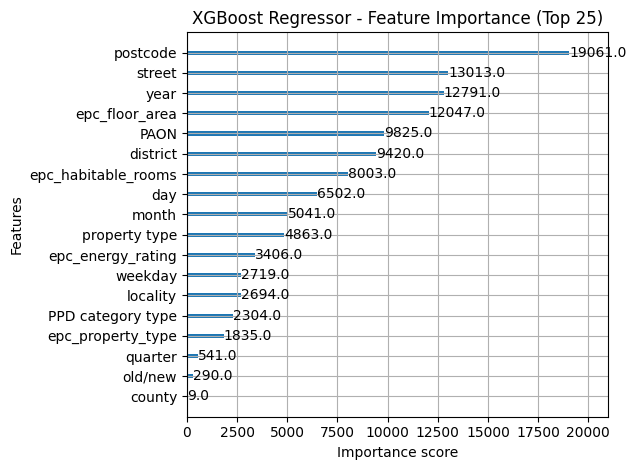


--- Model Evaluation (Test Set - Pre-2024 Data) ---
  MAE: 111,436.10
  MSE: 95,620,231,797.98
  RMSE: 309,225.21
  R-squared (R²): 0.8471


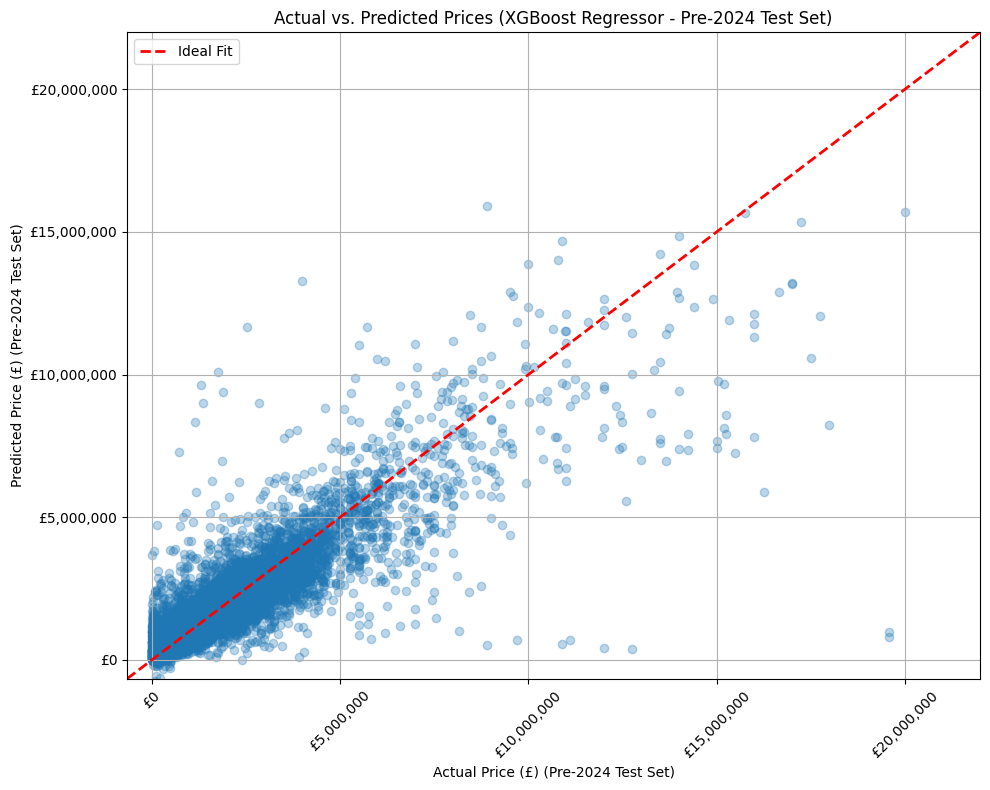


--- Preparing 2024 Data for Prediction ---

--- Applying Consistent Label Encoding to 2024 Data ---
Finished applying label encoding to target year.
Shape of 2024 features after align: (14342, 21)
Filled 14342 NaN values.
Replaced -1 codes with -999 in target year.

--- Predicting Prices for 2024 Data ---
Added 'predicted_price' column to the 2024 DataFrame.

--- Model Evaluation (2024 Data Only) ---
  MAE (2024): 192,270.43
  MSE (2024): 204,208,161,403.10
  RMSE (2024): 451,893.97
  R-squared (R²) (2024): 0.8331

--- Comparison of Actual vs Predicted Prices (Year 2024) ---
            price  predicted_price
586068   367500.0     3.973087e+05
586069   987000.0     9.797626e+05
586070  1080600.0     1.122755e+06
586071  2098000.0     2.129108e+06
586072  1580000.0     1.640833e+06

Descriptive Statistics for 2024 Prices:
            price predicted_price
count      14,342          14,342
mean    1,075,540       1,067,854
std     1,106,069         978,441
min        10,000      -1,193,

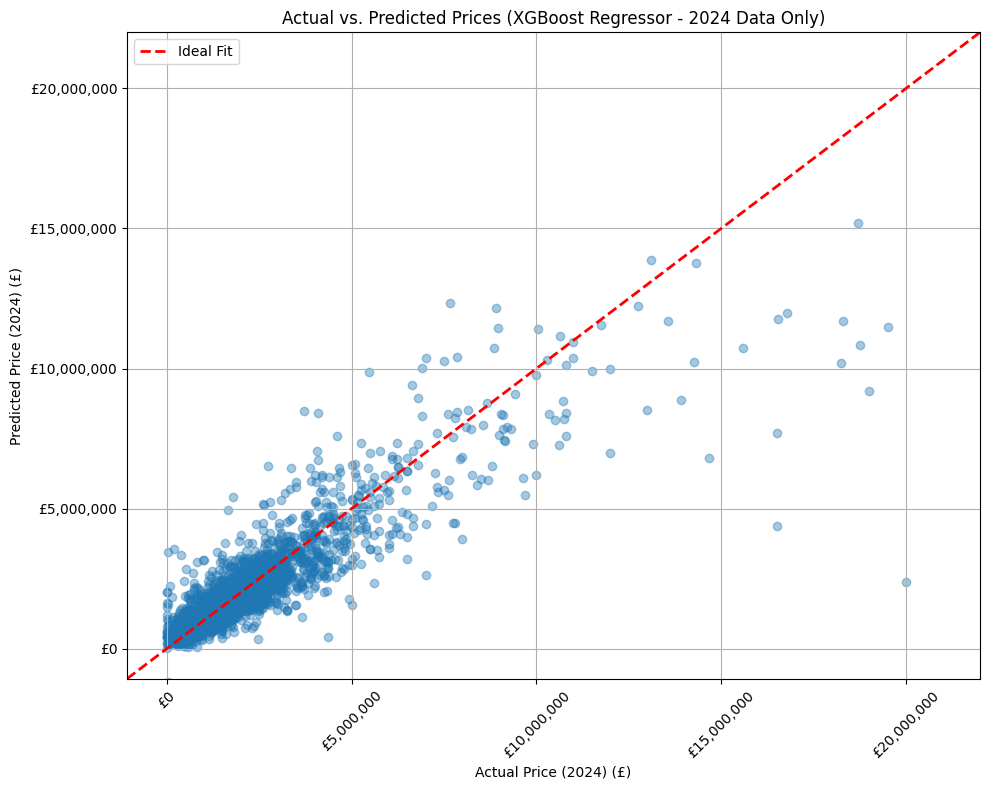


--- Sample Price Prediction (XGBoost Regressor - Using Pre-2024 Sample) ---

Selected Sample (Index: 401656):
  Original Date: 2014-04-29
  Original Actual Price: £900,000.00
  Address: SHIREHALL PARK, LONDON, BARNET, GREATER LONDON, NW4 2QU

Prediction for Original Year (2014): £1,518,360.50
Prediction for Year 2026: £1,938,826.62
Prediction for Year 2028: £1,938,826.62

Comparison:
  Actual (2014):      £900,000.00
  Predicted (2014): £1,518,360.50
  Predicted (2026):     £1,938,826.62
  Predicted (2028):     £1,938,826.62

--- Script Finished ---


In [ ]:
import numpy as np
import pandas as pd
from math import sqrt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import matplotlib.pyplot as plt
import warnings
from matplotlib.ticker import FuncFormatter # For plot formatting


TARGET_YEAR_FOR_SEPARATION = 2024 # Define the year to separate
MODEL_NAME = "XGBoost Regressor" # Define model name for titles/prints

# --- Filter Warnings ---
warnings.filterwarnings("ignore", category=FutureWarning) # XGBoost sometimes throws future warnings
warnings.filterwarnings("ignore", category=UserWarning)   # Pandas category warnings

df = pd.read_csv("london_merged_df_filtered.csv")


print("\n--- Initial Cleaning & Filtering ---")
initial_rows = len(df)
df = df.dropna(subset=["postcode","epc_floor_area","epc_habitable_rooms"])
df = df.dropna(subset=["postcode"])
print(f"Dropped {initial_rows - len(df)} rows with missing postcodes.")

initial_rows = len(df)
df = df.drop(columns=['record status - monthly file only', "Transaction unique identifier"], errors='ignore')
print("Dropped specified columns.")

initial_rows = len(df)
# Ensure 'price' is numeric before filtering
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price']) # Drop rows where price couldn't be converted
df['price'] = df['price'].astype(float) # Ensure price is float for comparison
price_min = 10_000
price_max = 20_000_000
df = df[(df["price"] >= price_min) & (df["price"] <= price_max)]
print(f"Filtered {initial_rows - len(df)} rows with price outside [£{price_min:,}, £{price_max:,}].")
print(f"DataFrame shape after initial cleaning/filtering: {df.shape}")


print("\n--- Feature Engineering (Date) ---")
df["date of transfer"] = pd.to_datetime(df["date of transfer"], format="%Y-%m-%d", errors="coerce")
initial_rows = len(df)
df = df.dropna(subset=["date of transfer"]) # Drop rows where date couldn't be parsed
print(f"Dropped {initial_rows - len(df)} rows with invalid date format.")

df['year']    = df['date of transfer'].dt.year
df["month"]   = df['date of transfer'].dt.month
df["day"]     = df['date of transfer'].dt.day
df["weekday"] = df['date of transfer'].dt.weekday
df["quarter"] = df['date of transfer'].dt.quarter
print("Extracted date features.")
print(f"Years present in data after cleaning: {sorted(df['year'].unique())}")


print(f"\n--- Separating {TARGET_YEAR_FOR_SEPARATION} Data ---")
if TARGET_YEAR_FOR_SEPARATION in df['year'].unique():
    df_target_year = df[df['year'] == TARGET_YEAR_FOR_SEPARATION].copy()
    df = df[df['year'] != TARGET_YEAR_FOR_SEPARATION]
    print(f"Number of rows in training data (pre-{TARGET_YEAR_FOR_SEPARATION}): {len(df)}")
    print(f"Number of rows set aside for {TARGET_YEAR_FOR_SEPARATION} evaluation: {len(df_target_year)}")
else:
    print(f"Warning: Year {TARGET_YEAR_FOR_SEPARATION} not found. Cannot separate.")
    df_target_year = pd.DataFrame()


df_original_lookup = df.copy()


print(f"\n--- Preparing Training Data (Pre-{TARGET_YEAR_FOR_SEPARATION}) ---")
train_df = df.drop(columns=['date of transfer'])
categorical_cols = [col for col in train_df.columns if train_df[col].dtype == 'O']
print(f"Identified categorical columns: {categorical_cols}")


category_mappings = {}
print(f"\n--- Applying Label Encoding ---")
for col in categorical_cols:
    train_df[col] = train_df[col].astype('category')
    category_mappings[col] = train_df[col].cat.categories
    train_df[col] = train_df[col].cat.codes
    print(f"Applied label encoding to '{col}'.")

train_df = train_df.replace(-1, -999) # Replace -1 code with a distinct value
initial_nans = train_df.isna().sum().sum()
train_df.fillna(0, inplace=True) # Fill any other potential NaNs
if initial_nans > 0: print(f"Filled {initial_nans} potential NaN values with 0.")
if (train_df == -999).any().any(): print("Replaced -1 codes from unseen categories with -999.")

# Define Features (X) and Target (y) for training
X = train_df.drop(['price'], axis=1)
y = train_df['price'] # Using original price scale as target for direct replacement
training_columns = X.columns.tolist() # Save columns after encoding
n_features = X.shape[1]
print(f"Number of features after label encoding: {n_features}")


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data shape (X_train): {X_train.shape}")
print(f"Testing data shape (X_test): {X_test.shape}")


print(f"\n--- Training {MODEL_NAME} Model ---")

# Instantiate XGBoost Regressor
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror', # Objective for regression
    n_estimators=1000,             # Start with a higher number, use early stopping
    learning_rate=0.05,            # Common starting point
    max_depth=7,                   # Controls complexity
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,      # Enable early stopping
    eval_metric='rmse'             # Evaluate on RMSE
)


eval_set = [(X_test, y_test)] 


print("\nStarting model training...")
if X_train.shape[0] == 0 or y_train.shape[0] == 0:
    print("Error: Training data is empty. Cannot train model.")
    exit()

xgb_model.fit(
    X_train,
    y_train, # Train directly on original price scale
    eval_set=eval_set,
    verbose=False # Suppress verbose output during training
)
print("Model training complete.")
best_iteration = xgb_model.best_iteration if hasattr(xgb_model, 'best_iteration') else 'N/A'
print(f"Best iteration (if stopped early): {best_iteration}")

try:
    plt.figure(figsize=(10, max(6, n_features // 4)))
    xgb.plot_importance(xgb_model, max_num_features=25)
    plt.title(f'{MODEL_NAME} - Feature Importance (Top 25)')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Could not plot feature importance: {e}")


print(f"\n--- Model Evaluation (Test Set - Pre-{TARGET_YEAR_FOR_SEPARATION} Data) ---")
predictions_test = xgb_model.predict(X_test) # Use xgb_model


valid_indices_test = np.isfinite(predictions_test) & np.isfinite(y_test.values)
if not np.all(valid_indices_test):
    print(f"Warning: Found non-finite values in test set predictions/actuals. Removing.")
    predictions_eval_test = predictions_test[valid_indices_test]
    y_test_eval = y_test.values[valid_indices_test]
else:
    predictions_eval_test = predictions_test
    y_test_eval = y_test.values

if len(predictions_eval_test) > 0 and len(y_test_eval) > 0:
    mae_test = mean_absolute_error(y_test_eval, predictions_eval_test)
    mse_test = mean_squared_error(y_test_eval, predictions_eval_test)
    rmse_test = sqrt(max(0, mse_test))
    r2_test = r2_score(y_test_eval, predictions_eval_test)

    print(f'  MAE: {mae_test:,.2f}')
    print(f'  MSE: {mse_test:,.2f}')
    print(f'  RMSE: {rmse_test:,.2f}')
    print(f"  R-squared (R²): {r2_test:.4f}")
else:
     print("Could not evaluate model on test set.")


if len(predictions_eval_test) > 0 and len(y_test_eval) > 0:
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_eval, predictions_eval_test, alpha=0.3)
    plt.xlabel("Actual Price (£) (Pre-2024 Test Set)")
    plt.ylabel("Predicted Price (£) (Pre-2024 Test Set)")
    plt.title(f"Actual vs. Predicted Prices ({MODEL_NAME} - Pre-2024 Test Set)")
    min_price = min(y_test_eval.min(), predictions_eval_test.min()) * 0.9
    max_price = max(y_test_eval.max(), predictions_eval_test.max()) * 1.1
    if min_price >= max_price: max_price = min_price + 10000
    plt.plot([min_price, max_price], [min_price, max_price], 'r--', lw=2, label='Ideal Fit')
    plt.xlim(min_price, max_price)
    plt.ylim(min_price, max_price)
    plt.legend()
    plt.grid(True)
    formatter = FuncFormatter(lambda x, p: f'£{x:,.0f}')
    plt.gca().xaxis.set_major_formatter(formatter)
    plt.gca().yaxis.set_major_formatter(formatter)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping test set plot.")


print(f"\n--- Preparing {TARGET_YEAR_FOR_SEPARATION} Data for Prediction ---")
if not df_target_year.empty:
    try:
        y_target_year_actual = df_target_year['price'].copy()

        # Apply the same preprocessing as the training data
        df_target_year_processed = df_target_year.drop(columns=['date of transfer', 'price'], errors='ignore')

        print(f"\n--- Applying Consistent Label Encoding to {TARGET_YEAR_FOR_SEPARATION} Data ---")
        for col in categorical_cols: # Use same list from training prep
            if col in df_target_year_processed.columns:
                 categorical_array = pd.Categorical(
                     df_target_year_processed[col].astype(str), # Ensure string type first
                     categories=category_mappings[col],
                     ordered=False
                 )
                 df_target_year_processed[col] = categorical_array.codes
                 # print(f"Applied consistent label encoding to '{col}' in target year data.")
            else:
                  print(f"Warning: Column '{col}' not found in target year data frame for encoding.")
        print("Finished applying label encoding to target year.")

        X_target_year = df_target_year_processed.reindex(columns=training_columns, fill_value=0) # Use saved training columns
        print(f"Shape of {TARGET_YEAR_FOR_SEPARATION} features after align: {X_target_year.shape}")


        X_target_year = X_target_year.replace(-1, -999) # Replace unseen category codes
        initial_nans_target_year = X_target_year.isna().sum().sum()
        X_target_year.fillna(0, inplace=True)
        if initial_nans_target_year > 0: print(f"Filled {initial_nans_target_year} NaN values.")
        if (X_target_year == -999).any().any(): print("Replaced -1 codes with -999 in target year.")


        print(f"\n--- Predicting Prices for {TARGET_YEAR_FOR_SEPARATION} Data ---")
        predictions_target_year = xgb_model.predict(X_target_year) # Use xgb_model


        df_target_year['predicted_price'] = predictions_target_year
        print(f"Added 'predicted_price' column to the {TARGET_YEAR_FOR_SEPARATION} DataFrame.")

        print(f"\n--- Model Evaluation ({TARGET_YEAR_FOR_SEPARATION} Data Only) ---")
        # Ensure finite values
        target_valid_indices = np.isfinite(predictions_target_year) & np.isfinite(y_target_year_actual.values)
        if not np.all(target_valid_indices):
            print(f"Warning: Found non-finite values in {TARGET_YEAR_FOR_SEPARATION} predictions/actuals. Removing.")
            target_predictions_eval = predictions_target_year[target_valid_indices]
            target_y_eval = y_target_year_actual.values[target_valid_indices]
        else:
            target_predictions_eval = predictions_target_year
            target_y_eval = y_target_year_actual.values

        if len(target_predictions_eval) > 0 and len(target_y_eval) > 0:
            mae_target_year = mean_absolute_error(target_y_eval, target_predictions_eval)
            mse_target_year = mean_squared_error(target_y_eval, target_predictions_eval)
            rmse_target_year = sqrt(max(0, mse_target_year))
            r2_target_year = r2_score(target_y_eval, target_predictions_eval)

            print(f'  MAE ({TARGET_YEAR_FOR_SEPARATION}): {mae_target_year:,.2f}')
            print(f'  MSE ({TARGET_YEAR_FOR_SEPARATION}): {mse_target_year:,.2f}')
            print(f'  RMSE ({TARGET_YEAR_FOR_SEPARATION}): {rmse_target_year:,.2f}')
            print(f"  R-squared (R²) ({TARGET_YEAR_FOR_SEPARATION}): {r2_target_year:.4f}")
        else:
            print(f"Could not evaluate {TARGET_YEAR_FOR_SEPARATION} model.")


        print(f"\n--- Comparison of Actual vs Predicted Prices (Year {TARGET_YEAR_FOR_SEPARATION}) ---")
        print(df_target_year[['price', 'predicted_price']].head())
        print(f"\nDescriptive Statistics for {TARGET_YEAR_FOR_SEPARATION} Prices:")
        print(df_target_year[['price', 'predicted_price']].describe().map(lambda x: f"{x:,.0f}")) # Use map


        if len(target_predictions_eval) > 0 and len(target_y_eval) > 0:
            plt.figure(figsize=(10, 8))
            plt.scatter(target_y_eval, target_predictions_eval, alpha=0.4)
            plt.xlabel(f"Actual Price ({TARGET_YEAR_FOR_SEPARATION}) (£)")
            plt.ylabel(f"Predicted Price ({TARGET_YEAR_FOR_SEPARATION}) (£)")
            plt.title(f"Actual vs. Predicted Prices ({MODEL_NAME} - {TARGET_YEAR_FOR_SEPARATION} Data Only)")
            min_price_tgt = min(target_y_eval.min(), target_predictions_eval.min()) * 0.9
            max_price_tgt = max(target_y_eval.max(), target_predictions_eval.max()) * 1.1
            if min_price_tgt >= max_price_tgt: max_price_tgt = min_price_tgt + 10000
            plt.plot([min_price_tgt, max_price_tgt], [min_price_tgt, max_price_tgt], 'r--', lw=2, label='Ideal Fit')
            plt.xlim(min_price_tgt, max_price_tgt)
            plt.ylim(min_price_tgt, max_price_tgt)
            plt.legend()
            plt.grid(True)
            formatter = FuncFormatter(lambda x, p: f'£{x:,.0f}')
            plt.gca().xaxis.set_major_formatter(formatter)
            plt.gca().yaxis.set_major_formatter(formatter)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
        else:
            print("Skipping target year plot.")

    except Exception as e:
        print(f"An error occurred during {TARGET_YEAR_FOR_SEPARATION} prediction/evaluation: {e}")
        import traceback
        traceback.print_exc()

else:
    print(f"\n--- No Data Found for Year {TARGET_YEAR_FOR_SEPARATION} ---")
    print(f"Skipping prediction and evaluation for {TARGET_YEAR_FOR_SEPARATION}.")


print(f"\n--- Sample Price Prediction ({MODEL_NAME} - Using Pre-{TARGET_YEAR_FOR_SEPARATION} Sample) ---")
if not df_original_lookup.empty:
    try:
        sample_original_df = df_original_lookup.sample(1, random_state=42)
        sample_index = sample_original_df.index[0]
        original_price = sample_original_df['price'].iloc[0] # Original actual price

        # Apply consistent label encoding
        sample_for_processing = sample_original_df.copy()
        for col in categorical_cols: # Use same list from training prep
             if col in sample_for_processing.columns:
                 categorical_array = pd.Categorical(
                     sample_for_processing[col].astype(str), # Ensure string
                     categories=category_mappings[col],
                     ordered=False
                 )
                 sample_for_processing[col] = categorical_array.codes

        # Prepare features
        X_sample_unscaled = sample_for_processing.drop(columns=['date of transfer', 'price'], errors='ignore')
        X_sample_unscaled = X_sample_unscaled.reindex(columns=training_columns, fill_value=0) # Align
        X_sample_unscaled = X_sample_unscaled.replace(-1, -999) # Handle unseen
        X_sample_unscaled.fillna(0, inplace=True)

        # Display original info
        original_date = sample_original_df['date of transfer'].iloc[0]
        original_year = sample_original_df['year'].iloc[0]
        address_fields = ['paon', 'saon', 'street', 'locality', 'town/city', 'district', 'county', 'postcode']
        # Retrieve original address values *before* encoding for display
        original_address_df = df_original_lookup.loc[[sample_index]] # Get original row again
        original_address = ", ".join(str(original_address_df[col].iloc[0]) for col in address_fields if col in original_address_df.columns and pd.notna(original_address_df[col].iloc[0]))
        print(f"\nSelected Sample (Index: {sample_index}):")
        print(f"  Original Date: {original_date.strftime('%Y-%m-%d')}")
        print(f"  Original Actual Price: £{original_price:,.2f}")
        print(f"  Address: {original_address}") # Display original address

        # Scale if features were scaled for training
        # X_sample = x_scaler.transform(X_sample_unscaled) if 'x_scaler' in locals() else X_sample_unscaled
        X_sample = X_sample_unscaled # Not scaling features in this version

        # Predict for original year using xgb_model
        prediction_original_year = xgb_model.predict(X_sample)[0]
        if not np.isfinite(prediction_original_year): raise ValueError("Non-finite prediction for sample.")
        print(f"\nPrediction for Original Year ({original_year}): £{prediction_original_year:,.2f}")

        # Predict for future years
        target_year_1 = 2026
        X_sample_future_1_unscaled = X_sample_unscaled.copy()
        X_sample_future_1_unscaled['year'] = target_year_1
        # X_sample_future_1 = x_scaler.transform(X_sample_future_1_unscaled) if 'x_scaler' in locals() else X_sample_future_1_unscaled
        X_sample_future_1 = X_sample_future_1_unscaled
        prediction_future_1 = xgb_model.predict(X_sample_future_1)[0]
        if not np.isfinite(prediction_future_1): raise ValueError("Non-finite prediction for future sample 1.")
        print(f"Prediction for Year {target_year_1}: £{prediction_future_1:,.2f}")

        target_year_2 = 2028
        X_sample_future_2_unscaled = X_sample_unscaled.copy()
        X_sample_future_2_unscaled['year'] = target_year_2
        # X_sample_future_2 = x_scaler.transform(X_sample_future_2_unscaled) if 'x_scaler' in locals() else X_sample_future_2_unscaled
        X_sample_future_2 = X_sample_future_2_unscaled
        prediction_future_2 = xgb_model.predict(X_sample_future_2)[0]
        if not np.isfinite(prediction_future_2): raise ValueError("Non-finite prediction for future sample 2.")
        print(f"Prediction for Year {target_year_2}: £{prediction_future_2:,.2f}")

        print("\nComparison:")
        print(f"  Actual ({original_year}):      £{original_price:,.2f}")
        print(f"  Predicted ({original_year}): £{prediction_original_year:,.2f}")
        print(f"  Predicted ({target_year_1}):     £{prediction_future_1:,.2f}")
        print(f"  Predicted ({target_year_2}):     £{prediction_future_2:,.2f}")

    except Exception as e:
        print(f"An error occurred during sample prediction: {e}")
        import traceback
        traceback.print_exc()
else:
    print(f"Original lookup DataFrame (pre-{TARGET_YEAR_FOR_SEPARATION}) is empty.")

print("\n--- Script Finished ---")



xGBOOST 2024 10y  label enc

Successfully loaded data. Initial shape: (191678, 28)

--- Initial Cleaning & Filtering ---
Dropped 9538 rows with missing postcodes.
Dropped specified columns.
Filtered 765 rows with price outside [£10,000, £20,000,000].
DataFrame shape after initial cleaning/filtering: (181375, 19)

--- Feature Engineering (Date) ---
Dropped 0 rows with invalid date format.
Extracted date features.
Years present in data after cleaning: [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]

--- Separating 2024 Data ---
Number of rows in training data (pre-2024): 167033
Number of rows set aside for 2024 evaluation: 14342

--- Preparing Training Data (Pre-2024) ---
Identified categorical columns: ['postcode', 'property type', 'old/new', 'duration', 'PAON', 'street', 'locality', 'town/city', 'district', 'county', 'PPD category type', 'epc_property_type', 'epc_energy_rating']

--- App

<Figure size 1000x600 with 0 Axes>

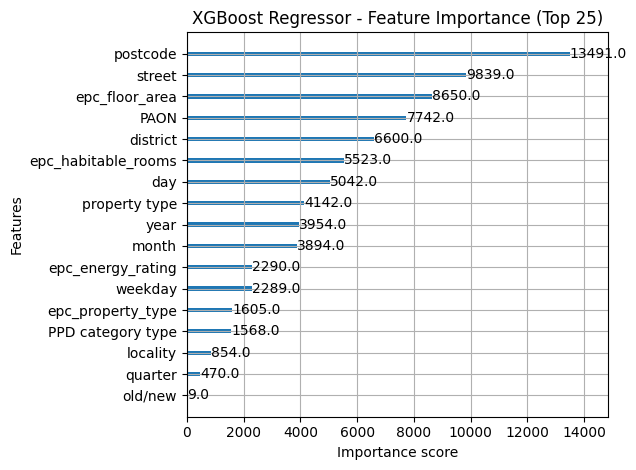


--- Model Evaluation (Test Set - Pre-2024 Data) ---
  MAE: 183,713.10
  MSE: 227,765,657,160.61
  RMSE: 477,248.00
  R-squared (R²): 0.8140


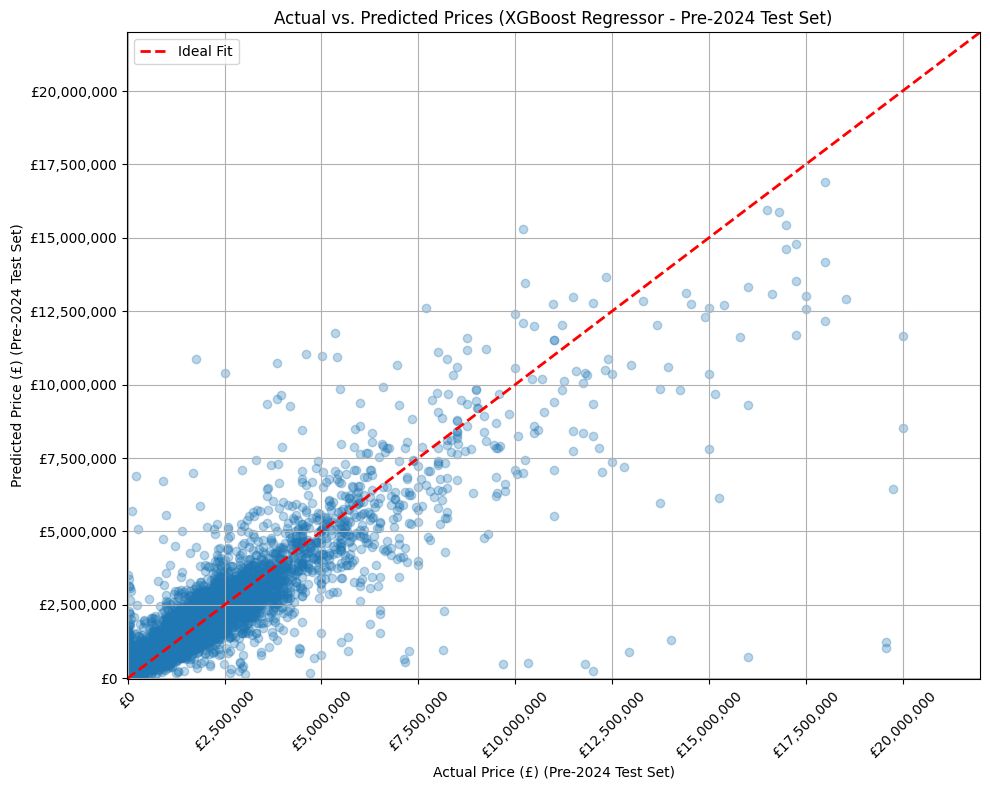


--- Preparing 2024 Data for Prediction ---

--- Applying Consistent Label Encoding to 2024 Data ---
Finished applying label encoding to target year.
Shape of 2024 features after align: (14342, 21)
Filled 14342 NaN values.
Replaced -1 codes with -999 in target year.

--- Predicting Prices for 2024 Data ---
Added 'predicted_price' column to the 2024 DataFrame.

--- Model Evaluation (2024 Data Only) ---
  MAE (2024): 197,249.19
  MSE (2024): 208,776,673,101.78
  RMSE (2024): 456,920.86
  R-squared (R²) (2024): 0.8293

--- Comparison of Actual vs Predicted Prices (Year 2024) ---
            price  predicted_price
176525   367500.0     4.440761e+05
176526   987000.0     1.019995e+06
176527  1080600.0     1.134761e+06
176528  2098000.0     2.068452e+06
176529  1580000.0     1.612054e+06

Descriptive Statistics for 2024 Prices:
            price predicted_price
count      14,342          14,342
mean    1,075,540       1,068,785
std     1,106,069         957,109
min        10,000          52,

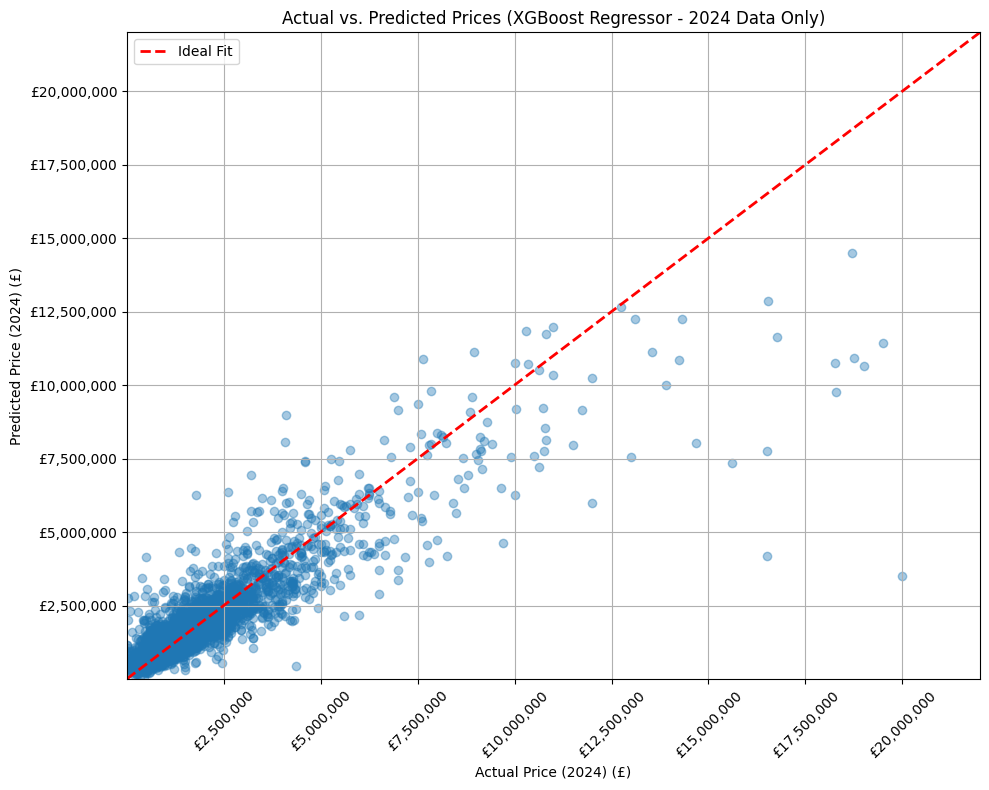


--- Sample Price Prediction (XGBoost Regressor - Using Pre-2024 Sample) ---

Selected Sample (Index: 13181):
  Original Date: 2015-09-18
  Original Actual Price: £2,625,000.00
  Address: BARROWGATE ROAD, LONDON, HOUNSLOW, GREATER LONDON, W4 4QU

Prediction for Original Year (2015): £1,880,065.75
Prediction for Year 2026: £1,991,100.50
Prediction for Year 2028: £1,991,100.50

Comparison:
  Actual (2015):      £2,625,000.00
  Predicted (2015): £1,880,065.75
  Predicted (2026):     £1,991,100.50
  Predicted (2028):     £1,991,100.50

--- Script Finished ---


In [ ]:
import numpy as np
import pandas as pd
from math import sqrt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import matplotlib.pyplot as plt
import warnings
from matplotlib.ticker import FuncFormatter # For plot formatting


TARGET_YEAR_FOR_SEPARATION = 2024 # Define the year to separate
MODEL_NAME = "XGBoost Regressor" # Define model name for titles/prints

# --- Filter Warnings ---
warnings.filterwarnings("ignore", category=FutureWarning) # XGBoost sometimes throws future warnings
warnings.filterwarnings("ignore", category=UserWarning)   # Pandas category warnings

df = pd.read_csv("london_merged_df_filtered_2015.csv")


print("\n--- Initial Cleaning & Filtering ---")
initial_rows = len(df)
df = df.dropna(subset=["postcode","epc_floor_area","epc_habitable_rooms"])
df = df.dropna(subset=["postcode"])
print(f"Dropped {initial_rows - len(df)} rows with missing postcodes.")

initial_rows = len(df)
df = df.drop(columns=['record status - monthly file only', "Transaction unique identifier"], errors='ignore')
print("Dropped specified columns.")

initial_rows = len(df)
# Ensure 'price' is numeric before filtering
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price']) # Drop rows where price couldn't be converted
df['price'] = df['price'].astype(float) # Ensure price is float for comparison
price_min = 10_000
price_max = 20_000_000
df = df[(df["price"] >= price_min) & (df["price"] <= price_max)]
print(f"Filtered {initial_rows - len(df)} rows with price outside [£{price_min:,}, £{price_max:,}].")
print(f"DataFrame shape after initial cleaning/filtering: {df.shape}")


print("\n--- Feature Engineering (Date) ---")
df["date of transfer"] = pd.to_datetime(df["date of transfer"], format="%Y-%m-%d", errors="coerce")
initial_rows = len(df)
df = df.dropna(subset=["date of transfer"]) # Drop rows where date couldn't be parsed
print(f"Dropped {initial_rows - len(df)} rows with invalid date format.")

df['year']    = df['date of transfer'].dt.year
df["month"]   = df['date of transfer'].dt.month
df["day"]     = df['date of transfer'].dt.day
df["weekday"] = df['date of transfer'].dt.weekday
df["quarter"] = df['date of transfer'].dt.quarter
print("Extracted date features.")
print(f"Years present in data after cleaning: {sorted(df['year'].unique())}")


print(f"\n--- Separating {TARGET_YEAR_FOR_SEPARATION} Data ---")
if TARGET_YEAR_FOR_SEPARATION in df['year'].unique():
    df_target_year = df[df['year'] == TARGET_YEAR_FOR_SEPARATION].copy()
    df = df[df['year'] != TARGET_YEAR_FOR_SEPARATION]
    print(f"Number of rows in training data (pre-{TARGET_YEAR_FOR_SEPARATION}): {len(df)}")
    print(f"Number of rows set aside for {TARGET_YEAR_FOR_SEPARATION} evaluation: {len(df_target_year)}")
else:
    print(f"Warning: Year {TARGET_YEAR_FOR_SEPARATION} not found. Cannot separate.")
    df_target_year = pd.DataFrame()


df_original_lookup = df.copy()


print(f"\n--- Preparing Training Data (Pre-{TARGET_YEAR_FOR_SEPARATION}) ---")
train_df = df.drop(columns=['date of transfer'])
categorical_cols = [col for col in train_df.columns if train_df[col].dtype == 'O']
print(f"Identified categorical columns: {categorical_cols}")


category_mappings = {}
print(f"\n--- Applying Label Encoding ---")
for col in categorical_cols:
    train_df[col] = train_df[col].astype('category')
    category_mappings[col] = train_df[col].cat.categories
    train_df[col] = train_df[col].cat.codes
    print(f"Applied label encoding to '{col}'.")

train_df = train_df.replace(-1, -999) # Replace -1 code with a distinct value
initial_nans = train_df.isna().sum().sum()
train_df.fillna(0, inplace=True) # Fill any other potential NaNs
if initial_nans > 0: print(f"Filled {initial_nans} potential NaN values with 0.")
if (train_df == -999).any().any(): print("Replaced -1 codes from unseen categories with -999.")

# Define Features (X) and Target (y) for training
X = train_df.drop(['price'], axis=1)
y = train_df['price'] # Using original price scale as target for direct replacement
training_columns = X.columns.tolist() # Save columns after encoding
n_features = X.shape[1]
print(f"Number of features after label encoding: {n_features}")


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data shape (X_train): {X_train.shape}")
print(f"Testing data shape (X_test): {X_test.shape}")


print(f"\n--- Training {MODEL_NAME} Model ---")

# Instantiate XGBoost Regressor
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror', # Objective for regression
    n_estimators=1000,             # Start with a higher number, use early stopping
    learning_rate=0.05,            # Common starting point
    max_depth=7,                   # Controls complexity
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,      # Enable early stopping
    eval_metric='rmse'             # Evaluate on RMSE
)


eval_set = [(X_test, y_test)] 


print("\nStarting model training...")
if X_train.shape[0] == 0 or y_train.shape[0] == 0:
    print("Error: Training data is empty. Cannot train model.")
    exit()

xgb_model.fit(
    X_train,
    y_train, # Train directly on original price scale
    eval_set=eval_set,
    verbose=False # Suppress verbose output during training
)
print("Model training complete.")
best_iteration = xgb_model.best_iteration if hasattr(xgb_model, 'best_iteration') else 'N/A'
print(f"Best iteration (if stopped early): {best_iteration}")

try:
    plt.figure(figsize=(10, max(6, n_features // 4)))
    xgb.plot_importance(xgb_model, max_num_features=25)
    plt.title(f'{MODEL_NAME} - Feature Importance (Top 25)')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Could not plot feature importance: {e}")


print(f"\n--- Model Evaluation (Test Set - Pre-{TARGET_YEAR_FOR_SEPARATION} Data) ---")
predictions_test = xgb_model.predict(X_test) # Use xgb_model


valid_indices_test = np.isfinite(predictions_test) & np.isfinite(y_test.values)
if not np.all(valid_indices_test):
    print(f"Warning: Found non-finite values in test set predictions/actuals. Removing.")
    predictions_eval_test = predictions_test[valid_indices_test]
    y_test_eval = y_test.values[valid_indices_test]
else:
    predictions_eval_test = predictions_test
    y_test_eval = y_test.values

if len(predictions_eval_test) > 0 and len(y_test_eval) > 0:
    mae_test = mean_absolute_error(y_test_eval, predictions_eval_test)
    mse_test = mean_squared_error(y_test_eval, predictions_eval_test)
    rmse_test = sqrt(max(0, mse_test))
    r2_test = r2_score(y_test_eval, predictions_eval_test)

    print(f'  MAE: {mae_test:,.2f}')
    print(f'  MSE: {mse_test:,.2f}')
    print(f'  RMSE: {rmse_test:,.2f}')
    print(f"  R-squared (R²): {r2_test:.4f}")
else:
     print("Could not evaluate model on test set.")


if len(predictions_eval_test) > 0 and len(y_test_eval) > 0:
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_eval, predictions_eval_test, alpha=0.3)
    plt.xlabel("Actual Price (£) (Pre-2024 Test Set)")
    plt.ylabel("Predicted Price (£) (Pre-2024 Test Set)")
    plt.title(f"Actual vs. Predicted Prices ({MODEL_NAME} - Pre-2024 Test Set)")
    min_price = min(y_test_eval.min(), predictions_eval_test.min()) * 0.9
    max_price = max(y_test_eval.max(), predictions_eval_test.max()) * 1.1
    if min_price >= max_price: max_price = min_price + 10000
    plt.plot([min_price, max_price], [min_price, max_price], 'r--', lw=2, label='Ideal Fit')
    plt.xlim(min_price, max_price)
    plt.ylim(min_price, max_price)
    plt.legend()
    plt.grid(True)
    formatter = FuncFormatter(lambda x, p: f'£{x:,.0f}')
    plt.gca().xaxis.set_major_formatter(formatter)
    plt.gca().yaxis.set_major_formatter(formatter)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping test set plot.")


print(f"\n--- Preparing {TARGET_YEAR_FOR_SEPARATION} Data for Prediction ---")
if not df_target_year.empty:
    try:
        y_target_year_actual = df_target_year['price'].copy()

        # Apply the same preprocessing as the training data
        df_target_year_processed = df_target_year.drop(columns=['date of transfer', 'price'], errors='ignore')

        print(f"\n--- Applying Consistent Label Encoding to {TARGET_YEAR_FOR_SEPARATION} Data ---")
        for col in categorical_cols: # Use same list from training prep
            if col in df_target_year_processed.columns:
                 categorical_array = pd.Categorical(
                     df_target_year_processed[col].astype(str), # Ensure string type first
                     categories=category_mappings[col],
                     ordered=False
                 )
                 df_target_year_processed[col] = categorical_array.codes
                 # print(f"Applied consistent label encoding to '{col}' in target year data.")
            else:
                  print(f"Warning: Column '{col}' not found in target year data frame for encoding.")
        print("Finished applying label encoding to target year.")

        X_target_year = df_target_year_processed.reindex(columns=training_columns, fill_value=0) # Use saved training columns
        print(f"Shape of {TARGET_YEAR_FOR_SEPARATION} features after align: {X_target_year.shape}")


        X_target_year = X_target_year.replace(-1, -999) # Replace unseen category codes
        initial_nans_target_year = X_target_year.isna().sum().sum()
        X_target_year.fillna(0, inplace=True)
        if initial_nans_target_year > 0: print(f"Filled {initial_nans_target_year} NaN values.")
        if (X_target_year == -999).any().any(): print("Replaced -1 codes with -999 in target year.")


        print(f"\n--- Predicting Prices for {TARGET_YEAR_FOR_SEPARATION} Data ---")
        predictions_target_year = xgb_model.predict(X_target_year) # Use xgb_model


        df_target_year['predicted_price'] = predictions_target_year
        print(f"Added 'predicted_price' column to the {TARGET_YEAR_FOR_SEPARATION} DataFrame.")

        print(f"\n--- Model Evaluation ({TARGET_YEAR_FOR_SEPARATION} Data Only) ---")
        # Ensure finite values
        target_valid_indices = np.isfinite(predictions_target_year) & np.isfinite(y_target_year_actual.values)
        if not np.all(target_valid_indices):
            print(f"Warning: Found non-finite values in {TARGET_YEAR_FOR_SEPARATION} predictions/actuals. Removing.")
            target_predictions_eval = predictions_target_year[target_valid_indices]
            target_y_eval = y_target_year_actual.values[target_valid_indices]
        else:
            target_predictions_eval = predictions_target_year
            target_y_eval = y_target_year_actual.values

        if len(target_predictions_eval) > 0 and len(target_y_eval) > 0:
            mae_target_year = mean_absolute_error(target_y_eval, target_predictions_eval)
            mse_target_year = mean_squared_error(target_y_eval, target_predictions_eval)
            rmse_target_year = sqrt(max(0, mse_target_year))
            r2_target_year = r2_score(target_y_eval, target_predictions_eval)

            print(f'  MAE ({TARGET_YEAR_FOR_SEPARATION}): {mae_target_year:,.2f}')
            print(f'  MSE ({TARGET_YEAR_FOR_SEPARATION}): {mse_target_year:,.2f}')
            print(f'  RMSE ({TARGET_YEAR_FOR_SEPARATION}): {rmse_target_year:,.2f}')
            print(f"  R-squared (R²) ({TARGET_YEAR_FOR_SEPARATION}): {r2_target_year:.4f}")
        else:
            print(f"Could not evaluate {TARGET_YEAR_FOR_SEPARATION} model.")


        print(f"\n--- Comparison of Actual vs Predicted Prices (Year {TARGET_YEAR_FOR_SEPARATION}) ---")
        print(df_target_year[['price', 'predicted_price']].head())
        print(f"\nDescriptive Statistics for {TARGET_YEAR_FOR_SEPARATION} Prices:")
        print(df_target_year[['price', 'predicted_price']].describe().map(lambda x: f"{x:,.0f}")) # Use map


        if len(target_predictions_eval) > 0 and len(target_y_eval) > 0:
            plt.figure(figsize=(10, 8))
            plt.scatter(target_y_eval, target_predictions_eval, alpha=0.4)
            plt.xlabel(f"Actual Price ({TARGET_YEAR_FOR_SEPARATION}) (£)")
            plt.ylabel(f"Predicted Price ({TARGET_YEAR_FOR_SEPARATION}) (£)")
            plt.title(f"Actual vs. Predicted Prices ({MODEL_NAME} - {TARGET_YEAR_FOR_SEPARATION} Data Only)")
            min_price_tgt = min(target_y_eval.min(), target_predictions_eval.min()) * 0.9
            max_price_tgt = max(target_y_eval.max(), target_predictions_eval.max()) * 1.1
            if min_price_tgt >= max_price_tgt: max_price_tgt = min_price_tgt + 10000
            plt.plot([min_price_tgt, max_price_tgt], [min_price_tgt, max_price_tgt], 'r--', lw=2, label='Ideal Fit')
            plt.xlim(min_price_tgt, max_price_tgt)
            plt.ylim(min_price_tgt, max_price_tgt)
            plt.legend()
            plt.grid(True)
            formatter = FuncFormatter(lambda x, p: f'£{x:,.0f}')
            plt.gca().xaxis.set_major_formatter(formatter)
            plt.gca().yaxis.set_major_formatter(formatter)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
        else:
            print("Skipping target year plot.")

    except Exception as e:
        print(f"An error occurred during {TARGET_YEAR_FOR_SEPARATION} prediction/evaluation: {e}")
        import traceback
        traceback.print_exc()

else:
    print(f"\n--- No Data Found for Year {TARGET_YEAR_FOR_SEPARATION} ---")
    print(f"Skipping prediction and evaluation for {TARGET_YEAR_FOR_SEPARATION}.")


print(f"\n--- Sample Price Prediction ({MODEL_NAME} - Using Pre-{TARGET_YEAR_FOR_SEPARATION} Sample) ---")
if not df_original_lookup.empty:
    try:
        sample_original_df = df_original_lookup.sample(1, random_state=42)
        sample_index = sample_original_df.index[0]
        original_price = sample_original_df['price'].iloc[0] # Original actual price

        # Apply consistent label encoding
        sample_for_processing = sample_original_df.copy()
        for col in categorical_cols: # Use same list from training prep
             if col in sample_for_processing.columns:
                 categorical_array = pd.Categorical(
                     sample_for_processing[col].astype(str), # Ensure string
                     categories=category_mappings[col],
                     ordered=False
                 )
                 sample_for_processing[col] = categorical_array.codes

        # Prepare features
        X_sample_unscaled = sample_for_processing.drop(columns=['date of transfer', 'price'], errors='ignore')
        X_sample_unscaled = X_sample_unscaled.reindex(columns=training_columns, fill_value=0) # Align
        X_sample_unscaled = X_sample_unscaled.replace(-1, -999) # Handle unseen
        X_sample_unscaled.fillna(0, inplace=True)

        # Display original info
        original_date = sample_original_df['date of transfer'].iloc[0]
        original_year = sample_original_df['year'].iloc[0]
        address_fields = ['paon', 'saon', 'street', 'locality', 'town/city', 'district', 'county', 'postcode']
        # Retrieve original address values *before* encoding for display
        original_address_df = df_original_lookup.loc[[sample_index]] # Get original row again
        original_address = ", ".join(str(original_address_df[col].iloc[0]) for col in address_fields if col in original_address_df.columns and pd.notna(original_address_df[col].iloc[0]))
        print(f"\nSelected Sample (Index: {sample_index}):")
        print(f"  Original Date: {original_date.strftime('%Y-%m-%d')}")
        print(f"  Original Actual Price: £{original_price:,.2f}")
        print(f"  Address: {original_address}") # Display original address

        # Scale if features were scaled for training
        # X_sample = x_scaler.transform(X_sample_unscaled) if 'x_scaler' in locals() else X_sample_unscaled
        X_sample = X_sample_unscaled # Not scaling features in this version

        # Predict for original year using xgb_model
        prediction_original_year = xgb_model.predict(X_sample)[0]
        if not np.isfinite(prediction_original_year): raise ValueError("Non-finite prediction for sample.")
        print(f"\nPrediction for Original Year ({original_year}): £{prediction_original_year:,.2f}")

        # Predict for future years
        target_year_1 = 2026
        X_sample_future_1_unscaled = X_sample_unscaled.copy()
        X_sample_future_1_unscaled['year'] = target_year_1
        # X_sample_future_1 = x_scaler.transform(X_sample_future_1_unscaled) if 'x_scaler' in locals() else X_sample_future_1_unscaled
        X_sample_future_1 = X_sample_future_1_unscaled
        prediction_future_1 = xgb_model.predict(X_sample_future_1)[0]
        if not np.isfinite(prediction_future_1): raise ValueError("Non-finite prediction for future sample 1.")
        print(f"Prediction for Year {target_year_1}: £{prediction_future_1:,.2f}")

        target_year_2 = 2028
        X_sample_future_2_unscaled = X_sample_unscaled.copy()
        X_sample_future_2_unscaled['year'] = target_year_2
        # X_sample_future_2 = x_scaler.transform(X_sample_future_2_unscaled) if 'x_scaler' in locals() else X_sample_future_2_unscaled
        X_sample_future_2 = X_sample_future_2_unscaled
        prediction_future_2 = xgb_model.predict(X_sample_future_2)[0]
        if not np.isfinite(prediction_future_2): raise ValueError("Non-finite prediction for future sample 2.")
        print(f"Prediction for Year {target_year_2}: £{prediction_future_2:,.2f}")

        print("\nComparison:")
        print(f"  Actual ({original_year}):      £{original_price:,.2f}")
        print(f"  Predicted ({original_year}): £{prediction_original_year:,.2f}")
        print(f"  Predicted ({target_year_1}):     £{prediction_future_1:,.2f}")
        print(f"  Predicted ({target_year_2}):     £{prediction_future_2:,.2f}")

    except Exception as e:
        print(f"An error occurred during sample prediction: {e}")
        import traceback
        traceback.print_exc()
else:
    print(f"Original lookup DataFrame (pre-{TARGET_YEAR_FOR_SEPARATION}) is empty.")

print("\n--- Script Finished ---")

